# RegDet V1.1 — Sherm Quanty 2h Tactical Regime Detector: Everything, End to End

This single notebook is the complete story and evidence for **RegDet V1.1**, the
re-parameterized 2-hour Nifty regime detector. Run it top to bottom (on a cloud
notebook where `yfinance` works — Colab / Kaggle / Antigravity) and it shows,
in order:

1. **The data** — real `^NSEI` / `^INDIAVIX` 2h bars (synthetic fallback if offline; watch `TAC_SYNTH`).
2. **The features & their redundancy** — the 9 engineered features carry only ~6 independent dimensions.
3. **The labeling scheme** — direction + intensity + the chop filter, implemented inline (Section 3).
4. **The diagnosis — over-parameterization** — V1.0 (production) is a 5-state Gaussian HMM with **full** covariance = **294 parameters** on ~1,400 training rows (≈ 4.9 rows/param, deep in overfit territory). This is the root cause of its instability.
5. **The fix, tested head-to-head** — V1.0 vs **A: lean-cov** (diagonal covariance, 9 features, 114 params) vs **B: lean-feat** (diagonal, 5-feature subset, 74 params), through an **anchored walk-forward** (no look-ahead; positions act on the prior bar), ranked by **worst-fold Sharpe** (stability, not peak).
6. **The winner's regime map** — price shaded by detected regime.
7. **Why the losing folds lose** — per-fold + market-character tables and per-fold equity curves vs buy-and-hold, to tell *regime-inherent losses* (acceptable) from a *detector flaw* (not).
8. **The evaluation graph suite** — master overlay + VIX, four zoom windows, forward-return validation (box + mean grid), regime-conditional stats, confidence time series, the `trend_z` vs `trend_efficiency` decision plane, duration histogram + transition heatmap, and equity-curve context.
9. **The decision** — a stability-first rule, the automated verdict summary, and an honest verdict to fill in.

**First-principles thesis this notebook tests:** the detector's instability is
not a tuning miss, it's a capacity problem — too many parameters for the data.
The fix is to shrink the model (diagonal covariance, fewer redundant features)
until it stops overfitting, and to judge candidates by their *worst* fold, not
their best. Everything below is the evidence for or against that thesis on real
data.

## What changed in the labeling (and why the chop filter exists)

Labels are no longer "rank the 5 HMM state means and hand out H_BULL … H_BEAR in
order". That scheme let `H_BULL` be whichever state happened to have the most
extreme mean, so `H` fired almost at random relative to what price was doing.
The scheme used everywhere in this notebook is now **direction + intensity**:

* **Direction** comes from the HMM. Each state is bucketed bull / bear / side by
  the *rank* of its composite bullishness score (rank-based, so a non-empty
  `side` bucket is guaranteed — a raw deadzone threshold can silently produce an
  empty side bucket and make `SIDEWAYS` unreachable).
* **Probability mass is aggregated by bucket** (`bull_mass`, `bear_mass`,
  `side_mass`, which always partition to 1.0). A bull move split across two
  bullish states no longer dilutes each below the confidence floor and collapses
  to a false `SIDEWAYS`. The winning bucket is the **argmax** of the three.
* **Intensity (H vs L)** is a separate, causal grade. A bull/bear bar escalates
  to `H_BULL` / `H_BEAR` only if **both**:
  1. **magnitude** — `|trend_z| >= Z_HI`, where `trend_z` is `mom_3d`
     standardized against a `trend_mu` / `trend_sd` baseline **frozen on the fit
     window**; and
  2. **efficiency** — `trend_efficiency >= EFF_HI`, where efficiency is
     `|close[t] - close[t-EFF_WIN]| / Σ|close.diff()|` over the last `EFF_WIN`
     bars.
* **Low-confidence override:** if the winning bucket's mass is `< CONF_L`, the
  bar is forced to `SIDEWAYS`.

**Why the efficiency gate — the chop filter.** Magnitude alone *cannot* tell a
real trend from a swing inside a sideways bracket: the first leg of a genuine
trend and one oscillation of a range both show large N-bar momentum, so both
clear `Z_HI`. Efficiency can tell them apart, because it divides the *net*
displacement by the *total path walked*: ~1.0 when price moves in a straight
line, ~0.0 when it keeps doubling back. Requiring **both** gates keeps
range-bound swings at `L_BULL` / `L_BEAR`, so the system sizes down in chop and
reserves `H_BULL` / `H_BEAR` for moves that are big *and going somewhere*.
Both inputs use only bars `<= t`, so nothing here leaks the future.

**Four fixes on top of that scheme** (each behind its own switch, each measured
in **Section 7H**, each with a switch value that reproduces the pre-fix labeling
bit for bit):

1. **Direction scorer** — `vol_2h` and `vol_expansion` no longer vote on
   *direction*. They are magnitude measures; carrying sign `-1.0` in a direction
   score made the risk block outweigh the directional block, so a violent rally
   scored **bearish**. They remain HMM input features. (`DIRECTION_EXCLUDE`)
2. **Label hysteresis** — a new direction must persist `CONFIRM_BARS` bars before
   the emitted label flips. A causal *delay*, never a look-back-from-the-future
   smoother. (`CONFIRM_BARS`)
3. **Gate hysteresis** — `Z_HI` / `EFF_HI` become enter/exit *bands*, so bars
   sitting on a threshold stop flickering `H↔L`. (`Z_HI_EXIT`, `EFF_HI_EXIT`)
4. **Per-bar direction** — *the architectural one.* Direction used to be decided
   once per HMM **state**, but a state is directionally **mixed**: volatility is
   direction-agnostic, so the "violent" state holds sharp selloffs *and* sharp
   rallies and hands both the same label. Fix 1 could only delete a wrong vote —
   on real data those rally bars went red → **grey**, not green, and `SIDEWAYS`
   ended up with the highest forward return of any label. Fix 4 blends the state
   masses with a **causal per-bar** directional score built from signed features
   only. (`BAR_DIR_WEIGHT`, swept in **7H-vi** against a criterion fixed before
   the numbers)

> **Honesty gate:** if the data cell prints `TAC_SYNTH = True`, `yfinance` was
> unreachable and every number here is **illustrative only** — re-run where it
> works before deciding. Structural conclusions (which folds are shared losers,
> the rows/param ordering) transfer; exact Sharpe/return values do not.

In [1]:
%pip install -q hmmlearn yfinance

Note: you may need to restart the kernel to use updated packages.


## 1. Setup, harness config, labeling knobs, and the named configs under test

The walk-forward harness knobs (`HMM_ITER`, `N_FOLDS`, `MIN_TRAIN_FRAC`, feature
windows, scorer weights, the three named configs) are unchanged from the
head-to-head, so fold boundaries and per-fold results stay comparable.

New here: the **labeling knobs** `Z_HI`, `EFF_HI`, `EFF_WIN`, `CONF_L` and
`TREND_FEATURE`, copied verbatim from `REGDET_CONFIG` in `regdet_v11.py`. Feature
names use the engine's convention (`ret_2h`, `vol_2h`) so this notebook and the
engine speak the same column names.

Matplotlib is left on its **default backend** — the backend is never forced
anywhere in this notebook — so figures render inline in Colab / Kaggle /
Antigravity.

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt          # default backend -> inline figures
import matplotlib.patches as mpatches
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# ---------------------------------------------------------------------------
# Walk-forward harness config (matches capacity_ladder.py / the head-to-head)
# ---------------------------------------------------------------------------
HMM_ITER       = 2000          # EM iteration cap (fits converge in ~75-240 iters, <1s each)
N_FOLDS        = 4             # anchored walk-forward test blocks
MIN_TRAIN_FRAC = 0.50          # first fold trains on >= this fraction of bars
BARS_PER_DAY   = 3             # 2h bars per NSE session
LOOKBACK_SCALE = 1.0           # feature-window multiplier (1.0 = production windows)

# ---------------------------------------------------------------------------
# LABELING KNOBS — verbatim from REGDET_CONFIG in regdet_v11.py.
# These drive the direction + intensity + chop-filter scheme used EVERYWHERE in
# this notebook (walk-forward signal, regime overlay, evaluation suite).
# ---------------------------------------------------------------------------
CONF_L         = 0.50   # low-confidence override: if the WINNING direction bucket's
                        # aggregated probability mass is below this, the bar is forced
                        # to SIDEWAYS. Higher = more SIDEWAYS, fewer directional calls.
Z_HI           = 0.5    # trend-MAGNITUDE gate: |trend_z| must reach this for a bull/bear
                        # bar to escalate to H_BULL/H_BEAR. trend_z is TREND_FEATURE
                        # standardized against a mu/sd baseline FROZEN on the fit window
                        # (causal — never recomputed from bars the model has not seen).
                        # Lower = H fires more often (and flickers more).
EFF_HI         = 0.35   # trend-EFFICIENCY gate = THE CHOP FILTER. Efficiency is
                        # |net move| / |total path walked| over EFF_WIN bars: ~1.0 in a
                        # clean trend, ~0.0 in a range that keeps doubling back. Magnitude
                        # alone cannot separate a real trend from a swing inside a bracket
                        # (both show big momentum); this can. Requiring BOTH gates keeps
                        # range-bound swings at L_BULL/L_BEAR. Raise = stricter (less H).
EFF_WIN        = 9      # bars over which efficiency is measured (~ TREND_FEATURE horizon)
TREND_FEATURE  = 'mom_3d'   # the feature whose z-score grades trend magnitude

# ---------------------------------------------------------------------------
# LABELING FIXES 1-3 (see Section 7H for the measured A/B). Each is behind its
# own switch, and each switch has a value that reproduces the OLD behaviour
# bit-for-bit, so their effects can be separated and audited.
# ---------------------------------------------------------------------------

# FIX 1 -- DIRECTION SCORER: features that are excluded from the composite
# BULLISHNESS score. vol_2h and vol_expansion are MAGNITUDE measures: they say
# how big moves are, not which way they point. Feeding them into a DIRECTION
# score is a category error -- with the old weights the risk block (vol_2h,
# vol_expansion, vix_chg, drawdown; total 4.0) outweighed the directional block
# (ret_2h, mom_1d/3d/5d, dist_ma; total 3.2), so a violent RALLY (high vol, high
# vol expansion, still-elevated drawdown) scored BEARISH while price ripped up.
# These two features REMAIN HMM INPUT FEATURES -- they are genuinely informative
# about state -- they simply stop voting on direction. drawdown and vix_chg keep
# their -1.0 direction weight: both are defensibly signed (a deeper drawdown and
# a rising VIX really are bearish, not merely "big").
# DIRECTION_EXCLUDE = () reproduces the old scorer exactly.
DIRECTION_EXCLUDE = ('vol_2h', 'vol_expansion')

# FIX 2 -- LABEL HYSTERESIS (causal confirmation delay): a candidate new
# DIRECTION must persist for CONFIRM_BARS consecutive bars before the emitted
# label is allowed to flip; until then the previous emitted direction is held.
# This is a DELAY, not a smoother: bar t's emitted label is a function of bars
# <= t only. (An earlier version of this project shipped a "smoother" that
# decided whether to erase a run by inspecting the run's full REALIZED length --
# that is look-ahead and was removed. Nothing of that shape is reintroduced here;
# the causality probe in 7.0 re-proves it under hysteresis.)
# CONFIRM_BARS = 1 reproduces the old behaviour exactly.
CONFIRM_BARS   = 2

# FIX 3 -- GATE HYSTERESIS: the H escalation gates become enter/exit BANDS.
# Escalate L -> H when |z| >= Z_HI AND eff >= EFF_HI (unchanged), but only
# de-escalate H -> L when |z| < Z_HI_EXIT OR eff < EFF_HI_EXIT. Without this,
# bars sitting near a single threshold flicker H->L->H->L every bar.
# Z_HI_EXIT = Z_HI and EFF_HI_EXIT = EFF_HI reproduces the old behaviour exactly.
Z_HI_EXIT      = 0.35
EFF_HI_EXIT    = 0.25

# FIX 4 -- PER-BAR DIRECTION (this is the architectural one).
#
# THE FLAW IT ADDRESSES. Until now DIRECTION was a per-STATE property: the HMM
# assigns bar t a distribution over states, each STATE is bucketed bear/side/bull
# ONCE from the rank of its composite mean profile, and the bar inherits its
# state's direction. But an HMM state is directionally MIXED. Volatility is
# direction-agnostic, so the model reliably learns a "violent" state that
# contains BOTH sharp selloffs AND sharp rallies. ONE bucket label for that state
# cannot be right for every bar in it, no matter how the bucket is chosen.
#
# Real-data evidence (2874 2h Nifty bars) on the 366 causal high-vol RALLY bars
# (top vol_2h quartile AND trailing mom_3d > 0):
#   baseline          46.2% bear / 7.4% sideways / 46.4% bull
#   + FIX 1 (no vol)  11.2% bear / 42.3% sideways / 46.4% bull
# The red became GREY, not green -- bull did not move at all -- and SIDEWAYS then
# showed the HIGHEST forward return of any label (+0.717% at 15 bars vs H_BULL
# +0.026%), which is exactly what "a bullish population got parked in SIDEWAYS"
# looks like. FIX 1 removed a wrong vote; it could not add a right one, because
# the vote is cast once per state and not once per bar.
#
# THE FIX. Add a CAUSAL PER-BAR directional score from the SIGNED features only
# (ret_2h, mom_1d, mom_3d, mom_5d, dist_ma -- reusing FEATURE_SIGN/FEATURE_MAG),
# each standardized against a mu/sd baseline FROZEN on the fit window exactly the
# way trend_z is, then map it to three per-bar direction masses through a softmax
# and BLEND those with the state-level masses:
#
#     mass = (1 - BAR_DIR_WEIGHT) * state_mass + BAR_DIR_WEIGHT * bar_mass
#
# A convex combination of two points on the 3-simplex is on the 3-simplex, so
# bull+side+bear == 1 still holds bar by bar and every downstream mechanism --
# the prob_* partition, tactical_regime_confidence, the CONF_L override, the
# intensity gates, the CONFIRM_BARS hysteresis -- is untouched. The HMM keeps
# supplying market character, persistence and the confidence signal; only the
# DIRECTION ATTRIBUTION moves from per-state to per-bar.
#
# vol_2h / vol_expansion are structurally excluded from this score: they are
# magnitude, not direction. That is asserted, not merely intended.
#
# BAR_DIR_WEIGHT = 0.0 reproduces the pre-fix behaviour BIT-FOR-BIT -- the blend
# degenerates to 1.0*state_mass + 0.0*bar_mass, which is exact in IEEE754 for
# non-negative masses. Section 7H asserts that equality rather than assuming it.
# BAR_DIR_WEIGHT = 1.0 decides direction purely per bar (the HMM then contributes
# only character/persistence, not direction). Section 7H sweeps 0/0.25/0.5/0.75/1.
BAR_DIR_WEIGHT   = 0.5
BAR_DIR_FEATURES = ('ret_2h', 'mom_1d', 'mom_3d', 'mom_5d', 'dist_ma')
BAR_DIR_TAU      = 1.0   # softmax temperature on the per-bar z. The score is
                         # re-standardized on the fit window, so tau is in units
                         # of fit-window sd: |z| ~ 0.5*tau is where the leading
                         # direction's per-bar mass crosses 0.5. Lower tau =
                         # more decisive (more extreme) per-bar masses.

TRAIN_FRACTION = 0.70   # anchored fit fraction used by the PRODUCTION-style single fit
                        # in Section 7 (the engine's own TRAIN_FRACTION). The walk-forward
                        # in Section 5 uses MIN_TRAIN_FRAC/N_FOLDS fold edges instead.

# ---------------------------------------------------------------------------
# SEED ENSEMBLE — the identifiability fix (see Section 5d).
#
# hmm.GaussianHMM is fit by EM, a LOCAL optimizer. With one fixed seed the fit
# is not identified: refitting the same bars with different seeds lands in
# different local optima (train log-likelihood spread of ~1000 nats across 8
# seeds on the full-cov config) which segment the data differently. Multi-restart
# EM keeping the best log-likelihood does NOT fix it -- it collapses the LL
# spread but the surviving optima still disagree on the segmentation.
#
# What works instead: fit K models with K different seeds and average the
# DIRECTION-BUCKET PROBABILITY MASSES (bull / side / bear). Raw HMM state indices
# are arbitrary and permute freely between fits, so they cannot be averaged --
# but direction masses are permutation-INVARIANT semantic quantities, so they
# can. Each model's 3 masses sum to 1, so their average does too, and the
# labeling scheme downstream is bit-for-bit the same; only the SOURCE of the
# masses changes.
#
# ENSEMBLE_K = 1 reproduces the old single-fit behaviour exactly.
#
# Cost scales linearly in K (K fits per training slice). K=6 was the size the
# offline study measured (direction-call agreement between independent pools
# 81.9% single -> 91.9% at K=6), but K=6 pushed a full notebook run past ~8
# minutes on the synthetic path once Section 5d runs BOTH arms. K=4 is the
# adopted setting: it keeps the whole notebook near ~6 minutes. Raise it to 6
# (or higher) on the real-data Kaggle run, where runtime is not the constraint
# and the extra averaging is worth having.
ENSEMBLE_K     = 4
BASE_SEED      = 42     # ensemble seeds are BASE_SEED + 0..K-1 (deterministic,
                        # so every run of this notebook is reproducible)

CONFIDENCE_THRESHOLD_H  = 0.70   # chart reference line only
CONFIDENCE_THRESHOLD_L  = CONF_L # the actual SIDEWAYS override
HMM_PROB_DROP_THRESHOLD = 0.20   # confidence drop -> transition warning
VIX_SPIKE_THRESHOLD     = 0.25   # bar-over-bar VIX jump -> transition warning

REGIME_LABELS = ['H_BULL', 'L_BULL', 'SIDEWAYS', 'L_BEAR', 'H_BEAR']
REGIME_COLORS = {
    'H_BULL':   '#006400',
    'L_BULL':   '#90EE90',
    'SIDEWAYS': '#808080',
    'L_BEAR':   '#FFB6C1',
    'H_BEAR':   '#8B0000',
}

# Feature names follow regdet_v11.py exactly (ret_2h / vol_2h, not ret / vol).
FEATURE_COLS = ['ret_2h', 'mom_1d', 'mom_3d', 'mom_5d',
                'vol_2h', 'vol_expansion', 'vix_chg', 'drawdown', 'dist_ma']

# 5-feature primary subset from the feature-selection analysis (corr clustering
# + PCA + VIF): one representative per information family.
FEATURES_LEAN = ['ret_2h', 'mom_3d', 'vol_2h', 'vol_expansion', 'dist_ma']

BASE_WIN = dict(MOM_1D=1*BARS_PER_DAY, MOM_3D=3*BARS_PER_DAY, MOM_5D=5*BARS_PER_DAY,
                VOL_WIN=10, VOL_FAST=5, VOL_SLOW=20, SWING_WIN=20)

# Per-feature sign/magnitude weights for the subset-agnostic bullishness scorer.
#   raw (DIRECTION_EXCLUDE = ()):
#     score = ret_2h + 0.4*(m1+m3+m5) - vol_2h - vol_expansion - vix_chg - drawdown + dist_ma
#   with FIX 1 (DIRECTION_EXCLUDE = ('vol_2h','vol_expansion')) the two magnitude
#   terms drop out and the score becomes purely directional:
#     score = ret_2h + 0.4*(m1+m3+m5) - vix_chg - drawdown + dist_ma
# The exclusion is applied as a WEIGHT OF ZERO in `direction_weight` below, so it
# stays subset-agnostic: excluding a feature the subset does not contain is a
# no-op, and the HMM's own feature matrix is untouched.
FEATURE_SIGN = {
    'ret_2h': 1.0, 'mom_1d': 1.0, 'mom_3d': 1.0, 'mom_5d': 1.0, 'dist_ma': 1.0,
    'vol_2h': -1.0, 'vol_expansion': -1.0, 'vix_chg': -1.0, 'drawdown': -1.0,
}
FEATURE_MAG = {'mom_1d': 0.4, 'mom_3d': 0.4, 'mom_5d': 0.4}   # else 1.0

# Forward-return horizons used for EVALUATION ONLY (hindsight; never a label input).
FWD_HORIZONS = [3, 9, 15]        # ~1 day, ~3 days, ~5 days of 2h bars

# ---------------------------------------------------------------------------
# The three configs under test: V1.0 (prod baseline) vs Candidate A (lean-cov)
# vs Candidate B (lean-feat). All at N=5, CONF_L=0.5. This head-to-head is about
# MODEL CAPACITY (covariance type / feature subset) -- the labeling scheme below
# is identical for all three, so the comparison isolates capacity.
# ---------------------------------------------------------------------------
CONFIGS = [
    dict(name='V1.0 (prod)',  N=5, cov='full', features=FEATURE_COLS),
    dict(name='A: lean-cov',  N=5, cov='diag', features=FEATURE_COLS),
    dict(name='B: lean-feat', N=5, cov='diag', features=FEATURES_LEAN),
]

print(f"Labeling: direction+intensity  CONF_L={CONF_L}  Z_HI={Z_HI}  "
      f"EFF_HI={EFF_HI}  EFF_WIN={EFF_WIN}  TREND_FEATURE={TREND_FEATURE}")
print(f"Fixes   : [1] DIRECTION_EXCLUDE={DIRECTION_EXCLUDE or '() -> old scorer'}  "
      f"[2] CONFIRM_BARS={CONFIRM_BARS}"
      + ('  (=1 -> old behaviour)' if CONFIRM_BARS == 1 else '')
      + f"  [3] gate bands enter(|z|>={Z_HI}, eff>={EFF_HI}) "
        f"exit(|z|<{Z_HI_EXIT}, eff<{EFF_HI_EXIT})"
      + ('  (exit==enter -> old behaviour)'
         if (Z_HI_EXIT == Z_HI and EFF_HI_EXIT == EFF_HI) else ''))
print(f"          [4] BAR_DIR_WEIGHT={BAR_DIR_WEIGHT} (per-bar direction blend; "
      f"tau={BAR_DIR_TAU}, features={list(BAR_DIR_FEATURES)})"
      + ('  (=0.0 -> old per-state-only direction)' if BAR_DIR_WEIGHT == 0.0 else ''))
print(f"Fitting : SEED ENSEMBLE  ENSEMBLE_K={ENSEMBLE_K}  BASE_SEED={BASE_SEED}  "
      f"seeds={[BASE_SEED + i for i in range(ENSEMBLE_K)]}"
      + ('   (K=1 -> old single-fit behaviour)' if ENSEMBLE_K == 1 else ''))
print(f"Harness : HMM_ITER={HMM_ITER}  N_FOLDS={N_FOLDS}  MIN_TRAIN_FRAC={MIN_TRAIN_FRAC}  "
      f"configs={[c['name'] for c in CONFIGS]}")

Labeling: direction+intensity  CONF_L=0.5  Z_HI=0.5  EFF_HI=0.35  EFF_WIN=9  TREND_FEATURE=mom_3d
Fixes   : [1] DIRECTION_EXCLUDE=('vol_2h', 'vol_expansion')  [2] CONFIRM_BARS=2  [3] gate bands enter(|z|>=0.5, eff>=0.35) exit(|z|<0.35, eff<0.25)
          [4] BAR_DIR_WEIGHT=0.5 (per-bar direction blend; tau=1.0, features=['ret_2h', 'mom_1d', 'mom_3d', 'mom_5d', 'dist_ma'])
Fitting : SEED ENSEMBLE  ENSEMBLE_K=4  BASE_SEED=42  seeds=[42, 43, 44, 45]
Harness : HMM_ITER=2000  N_FOLDS=4  MIN_TRAIN_FRAC=0.5  configs=['V1.0 (prod)', 'A: lean-cov', 'B: lean-feat']


## 2. Data: `^NSEI` / `^INDIAVIX`, 60m resampled to 2h (synthetic fallback)

Same ladder as the engine: `yfinance` 60m bars over ~730 days with the
`tz_localize(None)` fix so the index is naive, resampled to 2h. If that fails,
the regime-blocked synthetic generator runs instead and `TAC_SYNTH` is set to
`True` — printed prominently, because on synthetic data every number below is
illustrative only.

In [3]:
def load_2h():
    """yfinance 60m->2h, else synthetic. Returns (nifty, vix, is_synth)."""
    try:
        import yfinance as yf

        def h2(tk):
            raw = yf.download(tk, interval='60m', period='730d',
                              auto_adjust=True, progress=False)
            if raw is None or len(raw) == 0:
                return None
            c = raw['Close'].squeeze().dropna()
            idx = pd.to_datetime(c.index)
            c.index = idx.tz_localize(None) if idx.tz is not None else idx   # naive index
            return c.resample('2h').last().dropna()

        nifty = h2('^NSEI')
        if nifty is not None and len(nifty) > 200:
            vix = h2('^INDIAVIX')
            vix = (vix.reindex(nifty.index).ffill().bfill()
                   if vix is not None and len(vix) else pd.Series(15.0, index=nifty.index))
            nifty.name, vix.name = 'nifty', 'vix'
            print(f'yfinance 60m->2h: {len(nifty)} bars')
            return nifty, vix, False
        raise ValueError('too few bars')
    except Exception as e:
        print(f'yfinance unavailable ({e}); falling back to synthetic 2h data.')
        return _synth()


def _synth():
    """Regime-blocked GBM + OU VIX at 2h cadence (offline validation only)."""
    rng = np.random.default_rng(42)
    days = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=520)
    idx = pd.DatetimeIndex([d + pd.Timedelta(hours=h) for d in days for h in (10, 12, 14)])
    REG = [(0.00, 0.15,  0.0004, 0.0035, 14.0, 0.6),
           (0.15, 0.30, -0.0006, 0.0060, 22.0, 1.1),
           (0.30, 0.45,  0.0001, 0.0030, 16.0, 0.7),
           (0.45, 0.55, -0.0030, 0.0110, 45.0, 2.5),
           (0.55, 0.75,  0.0006, 0.0050, 20.0, 1.0),
           (0.75, 0.90,  0.0005, 0.0032, 13.5, 0.6),
           (0.90, 1.00, -0.0002, 0.0045, 18.0, 0.9)]
    n, lvl, pv, nv, vv = len(idx), 18000.0, 15.0, [], []
    for i in range(n):
        f = i / n
        mu, sg, vm, vf = 0.0002, 0.0040, 16.0, 0.8
        for fs, fe, m, s, v, q in REG:
            if fs <= f < fe:
                mu, sg, vm, vf = m, s, v, q
                break
        lvl *= np.exp(rng.normal(mu, sg))
        pv = max(pv + 0.05 * (vm - pv) + rng.normal(0, vm * 0.08 * vf), 8.0)
        nv.append(lvl); vv.append(pv)
    return (pd.Series(nv, index=idx, name='nifty'),
            pd.Series(vv, index=idx, name='vix'), True)


nifty, vix, TAC_SYNTH = load_2h()
if TAC_SYNTH:
    print(f"\n*** TAC_SYNTH = True  ->  SYNTHETIC data ({len(nifty)} bars). "
          f"Results below are ILLUSTRATIVE ONLY. ***\n")
else:
    print(f"\n*** TAC_SYNTH = False  ->  REAL yfinance data ({len(nifty)} bars). "
          f"Results below are decision-grade. ***\n")
print(f"Span: {nifty.index[0]}  ->  {nifty.index[-1]}")

yfinance 60m->2h: 2894 bars

*** TAC_SYNTH = False  ->  REAL yfinance data (2894 bars). Results below are decision-grade. ***

Span: 2023-08-11 02:00:00  ->  2026-07-24 08:00:00


## 3. Features, scorer, and the direction + intensity labeling core

`build_features`, `composite_subset` and `n_params` are unchanged (only the
column names now match the engine). What is new is `label_bars` — the single
labeling function used by **every** section below, ported inline from
`regdet_v11.py` (this notebook imports nothing from the repo):

1. `direction_buckets` ranks the HMM's states by composite bullishness and
   splits them into bear / side / bull buckets. Rank-based, so all three buckets
   are non-empty — asserted, because an empty side bucket silently makes
   `SIDEWAYS` unreachable and that bug shipped once already.
2. Probability mass is aggregated per bucket; `bull_mass + bear_mass +
   side_mass == 1` for every bar (asserted).
3. `trend_z` = `TREND_FEATURE` standardized against a baseline **frozen on the
   fit window** (`n_fit` leading bars — never recomputed from bars the model has
   not seen). `trend_efficiency` = net move / path walked over `EFF_WIN` bars.
   Both use only bars `<= t`.
4. `H_BULL` / `H_BEAR` require **both** `|trend_z| >= Z_HI` **and**
   `trend_efficiency >= EFF_HI` (the chop filter) — asserted after labeling.
5. **FIX 4 — per-bar direction.** Steps 1–2 decide direction once per *state*,
   and an HMM state is directionally **mixed** (the high-volatility state holds
   sharp selloffs *and* sharp rallies, because volatility is direction-agnostic).
   `bar_direction_score` therefore computes a **causal per-bar** directional
   z from the signed features only — `ret_2h`, `mom_1d`, `mom_3d`, `mom_5d`,
   `dist_ma`, with the existing `FEATURE_SIGN`/`FEATURE_MAG` weights, each
   standardized against a `mu`/`sd` baseline **frozen on the fit window** exactly
   as `trend_z` is. `vol_2h`/`vol_expansion` are barred by assertion. A softmax
   turns that z into three per-bar masses, and `BAR_DIR_WEIGHT` blends them with
   the state masses: `(1-w)·state + w·bar`. A convex combination of two
   3-simplex points is a 3-simplex point, so the partition-to-1 invariant, the
   confidence signal, the `CONF_L` override and every gate below are unchanged.
   `BAR_DIR_WEIGHT = 0` is exact pre-fix behaviour (asserted in 7H).
6. The winning bucket is the argmax of the three (blended) masses; if its mass is
   `< CONF_L` the bar is forced to `SIDEWAYS`.

The five `prob_*` columns partition the same probability mass unconditionally
(bull/bear mass split into H/L by that bar's intensity grade), so they still sum
to 1 even on bars whose `tactical_regime_state` was overridden to `SIDEWAYS`.

> **Causality — every label at bar *t* uses only bars `<= t`. Including the decode.**
> The scaler, the HMM fit, the direction buckets and the `trend_mu`/`trend_sd`
> baseline are derived from **leading bars only**; `trend_efficiency` and every
> feature are backward-looking rolling windows; and positions everywhere act on
> the **prior** bar's label. The decode was the last gap and it is now **fixed**.
> `hmmlearn`'s `model.predict_proba` (forward-backward) and `model.predict`
> (Viterbi) are **whole-sequence** decodings: the state they report for bar *t*
> is smoothed using bars *after* *t*. `_filtered_posteriors` below replaces both
> with the forward (alpha) recursion alone, so `probs[t]` is exactly
> `P(state_t | bars 0..t)` — what a live engine would have had at that bar.
> Section 7.0 asserts this empirically, bar by bar, against the incremental
> ground truth.
>
> **This changed the numbers, and the old ones were the optimistic ones.**
> Measured on the real 2h feature matrix, the smoothed decode picked a different
> winning state on **6.0% of bars (93/1546)**, and shifted the winning
> probability by more than 0.10 on 12.5%. Every regime distribution, forward-
> return table and backtest figure in any run of this notebook *before* this fix
> was computed from labels that partly knew the future. Numbers below will not
> match those runs; the difference is the look-ahead being removed, not a
> regression in the detector.

In [4]:
def build_features(nifty, vix, scale=LOOKBACK_SCALE):
    """The 9 causal swing features (engine column names)."""
    w = {k: max(2, int(round(v * scale))) for k, v in BASE_WIN.items()}
    r = np.log(nifty / nifty.shift(1))
    df = pd.DataFrame(index=nifty.index)
    df['ret_2h'] = r
    df['mom_1d'] = r.rolling(w['MOM_1D']).sum()
    df['mom_3d'] = r.rolling(w['MOM_3D']).sum()
    df['mom_5d'] = r.rolling(w['MOM_5D']).sum()
    df['vol_2h'] = r.rolling(w['VOL_WIN']).std()
    df['vol_expansion'] = r.rolling(w['VOL_FAST']).std() / r.rolling(w['VOL_SLOW']).std()
    df['vix_chg'] = (vix - vix.shift(1)) / vix.shift(1)
    sh = nifty.rolling(w['SWING_WIN']).max()
    df['drawdown'] = (sh - nifty) / sh
    ma = nifty.rolling(w['SWING_WIN']).mean()
    df['dist_ma'] = (nifty - ma) / ma
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df


def direction_weight(feat, exclude=None):
    """Weight this feature contributes to the composite BULLISHNESS score.

    FIX 1: features listed in `exclude` (default DIRECTION_EXCLUDE) get weight
    0.0 -- they stop voting on DIRECTION while remaining full HMM inputs.
    vol_2h and vol_expansion are magnitude measures, not signed ones; scoring a
    high-volatility RALLY as bearish was the bug this removes.

    Subset-agnostic: excluding a feature that is not in the active subset is a
    no-op, and `exclude=()` reproduces the original weights exactly.
    """
    exclude = DIRECTION_EXCLUDE if exclude is None else exclude
    if feat in exclude:
        return 0.0
    return FEATURE_SIGN[feat] * FEATURE_MAG.get(feat, 1.0)


def composite_subset(means, feature_subset, exclude=None):
    """Bullishness score per state; works with ANY feature subset."""
    score = np.zeros(means.shape[0])
    for j, feat in enumerate(feature_subset):
        score += direction_weight(feat, exclude) * means[:, j]
    # A subset whose every feature is excluded would make all states score 0 and
    # the direction ranking arbitrary -- catch that rather than emit noise.
    assert any(direction_weight(f, exclude) != 0.0 for f in feature_subset), \
        'DIRECTION_EXCLUDE removed every feature from the direction score'
    return score


def n_params(N, F, covariance_type):
    """GaussianHMM free parameters: means + covariances + transitions + startprob."""
    cov = N * F * (F + 1) / 2 if covariance_type == 'full' else N * F
    return N * F + cov + N * (N - 1) + (N - 1)


def trend_efficiency(close, win=EFF_WIN):
    """Causal Kaufman efficiency ratio over `win` bars:

        |close[t] - close[t-win]| / sum(|close.diff()|)

    i.e. net displacement / total path walked. ~1.0 in a straight-line trend,
    ~0.0 when price keeps doubling back inside a range -- the distinction raw
    momentum magnitude cannot make. Uses only bars <= t.
    """
    net = (close - close.shift(win)).abs()
    path = close.diff().abs().rolling(win).sum()
    return (net / path.replace(0, np.nan)).fillna(0.0).clip(0.0, 1.0)


def intensity_state(z, eff, z_hi=None, eff_hi=None, z_exit=None, eff_exit=None):
    """FIX 3 -- gate hysteresis. Returns a signed intensity array:

        +1  bar is escalated H on the BULL side
        -1  bar is escalated H on the BEAR side
         0  bar stays L

    Enter (0 -> +/-1): |z| >= z_hi AND eff >= eff_hi          (unchanged gates)
    Hold  (stay +/-1): |z| >= z_exit AND eff >= eff_exit AND sign(z) unchanged
    Exit  (-> 0):      |z| <  z_exit OR  eff <  eff_exit OR  sign(z) flipped

    A sign flip forces a fresh ENTER test rather than silently relabelling a held
    bull escalation as a bear one.

    CAUSAL: a single left-to-right scan whose state at bar t depends only on
    bars <= t, so truncating the input after t cannot change out[t].

    z_exit == z_hi and eff_exit == eff_hi reduce this EXACTLY to the old
    memoryless `(|z| >= z_hi) & (eff >= eff_hi)` test.
    """
    z_hi = Z_HI if z_hi is None else z_hi
    eff_hi = EFF_HI if eff_hi is None else eff_hi
    z_exit = Z_HI_EXIT if z_exit is None else z_exit
    eff_exit = EFF_HI_EXIT if eff_exit is None else eff_exit
    z = np.asarray(z, dtype=float)
    eff = np.asarray(eff, dtype=float)
    out = np.zeros(len(z), dtype=int)
    state = 0
    for t in range(len(z)):
        s = 1 if z[t] > 0 else (-1 if z[t] < 0 else 0)
        if state != 0 and s == state:
            if abs(z[t]) < z_exit or eff[t] < eff_exit:
                state = 0                       # de-escalate on the EXIT band
        else:
            state = 0                           # no state, or the sign flipped
        if state == 0 and abs(z[t]) >= z_hi and eff[t] >= eff_hi:
            state = s                           # escalate on the ENTER band
        out[t] = state
    return out


def confirm_delay(raw, confirm_bars=None):
    """FIX 2 -- causal label hysteresis (a CONFIRMATION DELAY, not a smoother).

    A candidate value must be observed on `confirm_bars` CONSECUTIVE bars before
    the emitted series is allowed to flip to it; until then the previous emitted
    value is held.

    WHY THIS IS CAUSAL, stated precisely: out[t] is a function of raw[0..t] only.
    The scan never looks at raw[t+1..]. Contrast with the look-ahead smoother
    this project previously removed, which decided whether to erase a run by
    inspecting that run's full REALIZED length -- i.e. it needed bars after t to
    decide bar t. This does the opposite: it PAYS a delay rather than borrowing
    the future. A flip that turns out to be a 1-bar blip is simply never emitted;
    a flip that persists is emitted `confirm_bars - 1` bars late.

    confirm_bars = 1 reproduces the input exactly (out is raw).
    """
    confirm_bars = CONFIRM_BARS if confirm_bars is None else int(confirm_bars)
    assert confirm_bars >= 1, 'CONFIRM_BARS must be >= 1'
    raw = np.asarray(raw)
    n = len(raw)
    out = np.empty(n, dtype=raw.dtype)
    if n == 0:
        return out
    out[0] = raw[0]                 # bar 0 has no prior emitted label to hold
    cand, run = raw[0], 0
    for t in range(1, n):
        if raw[t] == out[t - 1]:
            out[t] = raw[t]         # agrees with what is already emitted
            cand, run = raw[t], 0
        else:
            if raw[t] == cand:
                run += 1
            else:
                cand, run = raw[t], 1
            if run >= confirm_bars:
                out[t] = cand       # candidate confirmed -> flip
                run = 0
            else:
                out[t] = out[t - 1]  # not yet confirmed -> HOLD the old label
    return out


def direction_buckets(means, feature_subset, exclude=None):
    """Bucket HMM states into bear(-1) / side(0) / bull(+1) by RANK of composite
    bullishness. Rank-based (not a sign+deadzone threshold) so the side bucket is
    guaranteed non-empty; a deadzone can degenerate to an empty side bucket, which
    silently makes SIDEWAYS unreachable. For N=5 this is: bottom 2 bear, middle 1
    side, top 2 bull.

    `exclude` is threaded to the scorer (FIX 1); None uses DIRECTION_EXCLUDE.
    """
    scores = composite_subset(means, feature_subset, exclude)
    n_st = len(scores)
    order = np.argsort(scores)                 # ascending bullishness
    n_side = max(1, round(n_st / 5))
    n_bear = (n_st - n_side) // 2
    direction = np.empty(n_st, dtype=int)
    direction[order[:n_bear]] = -1
    direction[order[n_bear:n_bear + n_side]] = 0
    direction[order[n_bear + n_side:]] = 1
    # INVARIANT: every direction bucket must be reachable, else whole labels vanish.
    assert (direction == 1).sum() >= 1, 'bull bucket empty -> H_BULL/L_BULL unreachable'
    assert (direction == -1).sum() >= 1, 'bear bucket empty -> H_BEAR/L_BEAR unreachable'
    assert (direction == 0).sum() >= 1, 'side bucket empty -> SIDEWAYS unreachable'
    return direction


def bar_direction_score(dir_feats, n_fit, features=None):
    """FIX 4 -- CAUSAL PER-BAR directional z-score.

    dir_feats : DataFrame of RAW (unscaled) features aligned to the labeled bars,
                one row per bar, in bar order. Only the signed directional columns
                are read.
    n_fit     : number of LEADING bars that constitute the fit window. The mu/sd
                baseline is computed from those rows ONLY -- exactly the way
                trend_z's baseline is frozen -- so no bar > t and no bar the model
                has not seen can influence bar t's score.

    Construction:
      1. keep only BAR_DIR_FEATURES that are present (ret_2h, mom_1d, mom_3d,
         mom_5d, dist_ma -- all SIGNED directional measures);
      2. z-score each against its FIT-WINDOW mu/sd;
      3. weighted mean with the existing FEATURE_SIGN * FEATURE_MAG weights,
         normalised by sum|w| so the composite stays on a z-like scale;
      4. re-standardize the composite against ITS fit-window mu/sd, so the output
         is a unit-variance z on the fit window and BAR_DIR_TAU is interpretable.

    vol_2h / vol_expansion are structurally barred: they measure how BIG a move
    is, not which way it points, and letting a magnitude term vote on direction
    is the category error this whole fix exists to undo. Asserted below.

    Causality: every input column is a backward-looking rolling statistic, and
    the baseline uses leading rows only, so score[t] depends on bars <= t alone.
    Recomputing from the prefix dir_feats.iloc[:t+1] reproduces score[t] exactly
    (probed in 7.0).
    """
    features = BAR_DIR_FEATURES if features is None else tuple(features)
    assert not (set(features) & {'vol_2h', 'vol_expansion'}), \
        'per-bar DIRECTION score must not contain magnitude features'
    cols = [f for f in features if f in dir_feats.columns]
    assert cols, 'no directional features available for the per-bar direction score'
    A = np.asarray(dir_feats[cols].values, dtype=float)
    assert n_fit >= 2 and n_fit <= len(A), 'fit window out of range for the per-bar score'
    mu = A[:n_fit].mean(axis=0)
    sd = A[:n_fit].std(axis=0)
    Z = (A - mu) / np.where(sd > 0, sd, 1.0)
    # exclude=() deliberately: DIRECTION_EXCLUDE is FIX 1's state-level knob and
    # must not be able to mute a feature that is already guaranteed directional.
    w = np.array([direction_weight(f, exclude=()) for f in cols], dtype=float)
    assert np.abs(w).sum() > 0, 'per-bar direction weights are all zero'
    # (Z * w).sum(axis=1), NOT Z @ w. The two are algebraically identical and the
    # matmul is the obvious way to write it -- but `DataFrame.values` hands back an
    # F-ORDERED array, and BLAS gemv on an F-ordered operand picks its blocking
    # from the ROW COUNT, so the last-bar result changes in the last ulp depending
    # on how many bars follow it. That is a ~1e-16 difference with no economic
    # meaning, but it makes the truncation probe in 7.0 fail its bit-exactness
    # test, and a causality probe that has to be run at a tolerance is a weaker
    # probe. The row-wise form sums 5 terms per row independently of the array
    # length, so score[t] is BIT-identical whether or not bars > t exist -- and
    # 7.0 can therefore assert exact equality rather than np.isclose.
    s = (Z * w).sum(axis=1) / np.abs(w).sum()
    s_mu = float(s[:n_fit].mean())
    s_sd = float(s[:n_fit].std())
    return (s - s_mu) / (s_sd if s_sd > 0 else 1.0)


def bar_direction_masses(score, tau=None):
    """Map the per-bar directional z to bull / side / bear masses that sum to 1.

    Softmax over the three logits (+s/tau, 0, -s/tau): bull dominates for s >> 0,
    bear for s << 0, and SIDE is the plurality only near s ~ 0 -- which is the
    right shape, because "no clear direction at this bar" is a real answer and
    must remain reachable. Computed in a shift-stabilised form so large |s| does
    not overflow.

    Returns (bull, side, bear), each an array over bars, summing to 1 per bar.
    """
    tau = BAR_DIR_TAU if tau is None else float(tau)
    e = np.asarray(score, dtype=float) / max(tau, 1e-12)
    a = np.abs(e)                                   # = max(e, 0, -e), the shift
    eb, es, er = np.exp(e - a), np.exp(-a), np.exp(-e - a)
    tot = eb + es + er
    bull, side, bear = eb / tot, es / tot, er / tot
    assert np.allclose(bull + side + bear, 1.0, atol=1e-9), \
        'per-bar direction masses must partition to 1'
    return bull, side, bear


def _filtered_posteriors(model, X):
    """
    CAUSAL (filtered) state posteriors: P(state_t | observations_1..t).

    Why this exists instead of model.predict_proba():
      hmmlearn's predict_proba runs forward-BACKWARD, so the posterior it
      reports for bar t is smoothed using the whole sequence — including bars
      AFTER t. That is legitimate for offline sequence analysis but is
      look-ahead for a trading regime label: on 2h Nifty data it changes the
      winning state on ~6% of bars versus what was actually knowable at the
      time. predict() (Viterbi) has the same whole-sequence property.

      This is the forward (alpha) recursion only, so each bar's posterior is
      conditioned solely on information available at that bar — exactly what a
      live engine would have. The last bar of a forward-backward pass happens
      to equal the filtered value (no future exists yet), which is why LIVE
      calls were always correct; it is the HISTORICAL labels, and therefore
      every backtest built on them, that needed this fix.

    Computed in log space with per-step normalisation for numerical stability.
    """
    from scipy.special import logsumexp

    log_frame = model._compute_log_likelihood(X)          # (T, n_states)
    tiny      = np.finfo(float).tiny
    log_start = np.log(model.startprob_ + tiny)
    log_trans = np.log(model.transmat_ + tiny)

    T, N = log_frame.shape
    out  = np.empty((T, N), dtype=float)

    log_alpha = log_start + log_frame[0]
    log_alpha -= logsumexp(log_alpha)
    out[0] = np.exp(log_alpha)

    for t in range(1, T):
        # predict step (transition) then update step (emission at bar t)
        log_alpha = logsumexp(log_alpha[:, None] + log_trans, axis=0) + log_frame[t]
        log_alpha -= logsumexp(log_alpha)                 # renormalise each step
        out[t] = np.exp(log_alpha)

    return out


def ensemble_seeds(K=None, base_seed=None):
    """Deterministic seed list for the ensemble: base_seed + 0..K-1."""
    K = ENSEMBLE_K if K is None else int(K)
    base_seed = BASE_SEED if base_seed is None else int(base_seed)
    return [base_seed + i for i in range(K)]


def fit_hmm_ensemble(X_train, n_components, covariance_type,
                     K=None, base_seed=None, n_iter=None):
    """Fit K GaussianHMMs on the SAME training slice with K different seeds.

    This is the identifiability fix. EM is a local optimizer; one seed gives one
    arbitrary local optimum. K seeds give K samples of the optimum set, whose
    direction-bucket masses are averaged in `ensemble_direction_masses` below.

    Every model sees EXACTLY the same rows (`X_train`), which must already be
    the causal leading slice -- this function does no slicing of its own, so it
    cannot introduce look-ahead.

    Returns (models, all_converged).
    """
    n_iter = HMM_ITER if n_iter is None else int(n_iter)
    models, all_conv = [], True
    for sd in ensemble_seeds(K, base_seed):
        m = hmm.GaussianHMM(n_components=n_components, covariance_type=covariance_type,
                            n_iter=n_iter, random_state=sd,
                            init_params='stmc', params='stmc')
        m.fit(X_train)
        all_conv = all_conv and bool(m.monitor_.converged)
        models.append(m)
    return models, all_conv


def ensemble_direction_masses(models, Xs, feature_subset, exclude=None):
    """Average the direction-bucket probability masses across an ensemble.

    For each fitted model:
      1. CAUSAL filtered posteriors via `_filtered_posteriors` (forward-only
         alpha recursion). Never predict/predict_proba over the whole sequence --
         those are forward-BACKWARD/Viterbi and smooth bar t with bars after t.
      2. `direction_buckets` maps that model's states to bear/side/bull.
      3. The per-state posterior collapses to 3 columns: bull / side / bear.

    Those 3-column arrays are then averaged across models. This is only valid
    because direction masses are PERMUTATION-INVARIANT: model A's "state 3" and
    model B's "state 1" are unrelated integers, but "the probability mass sitting
    in bullish states" means the same thing in both. Averaging raw per-state
    posteriors would be meaningless.

    Causality is preserved exactly: the average of K quantities each of which
    depends only on bars <= t depends only on bars <= t.

    Returns (bull_mass, side_mass, bear_mass, probs_model0), where probs_model0
    is the first model's per-state filtered posterior (used only for the
    `hmm_state_int` reporting column, which has no ensemble analogue).
    """
    models = list(models)
    assert len(models) >= 1, 'ensemble must contain at least one model'
    acc = np.zeros((len(Xs), 3), dtype=float)      # columns: bull, side, bear
    probs0 = None
    for i, m in enumerate(models):
        direction = direction_buckets(m.means_, feature_subset, exclude)
        probs = _filtered_posteriors(m, Xs)        # CAUSAL, forward-only
        if i == 0:
            probs0 = probs
        acc[:, 0] += probs[:, direction == 1].sum(axis=1)
        acc[:, 1] += probs[:, direction == 0].sum(axis=1)
        acc[:, 2] += probs[:, direction == -1].sum(axis=1)
    acc /= len(models)
    # INVARIANT: an average of rows that each sum to 1 must itself sum to 1.
    assert np.allclose(acc.sum(axis=1), 1.0, atol=1e-9), \
        'ensembled direction masses must partition to 1'
    return acc[:, 0], acc[:, 1], acc[:, 2], probs0


def label_bars(model, Xs, dates, price, trend_raw, n_fit, feature_subset,
               exclude=None, confirm_bars=None, z_exit=None, eff_exit=None,
               dir_feats=None, bar_dir_weight=None):
    """Direction + intensity + chop-filter labeling: an inline port of the
    engine's _fit_and_classify labeling block (no repo import).

    model         : fitted GaussianHMM, OR a list/tuple of them (a seed ensemble).
                    With a list, the bull/side/bear masses are the ENSEMBLE
                    AVERAGE; a single model (or a 1-element list) reproduces the
                    old single-fit behaviour bit for bit. Nothing else about the
                    labeling changes -- the gates, the CONF_L override, the
                    output columns and their semantics are identical either way.
    Xs            : scaled features for bars 0..len(dates)-1 (scaler fit on <= n_fit)
    dates         : DatetimeIndex for those bars
    price         : full close Series (reindexed internally; efficiency is causal)
    trend_raw     : TREND_FEATURE values aligned to `dates`
    n_fit         : number of LEADING bars the model/scaler were fit on -- the trend
                    mu/sd baseline is frozen on exactly this window (no look-ahead)

    The three switchable labeling fixes (all default to the module-level config;
    the values in brackets reproduce the PRE-FIX behaviour bit for bit):

    exclude       : FIX 1, features that do not vote on direction  [()]
    confirm_bars  : FIX 2, causal confirmation delay in bars       [1]
    z_exit,
    eff_exit      : FIX 3, gate de-escalation band                 [Z_HI, EFF_HI]
    dir_feats     : FIX 4, RAW feature frame aligned to `dates` (the per-bar
                    direction score reads BAR_DIR_FEATURES out of it)
    bar_dir_weight: FIX 4, blend weight on the per-bar masses      [0.0]

    Returns a DataFrame indexed by `dates` with the engine's column names.
    """
    models = list(model) if isinstance(model, (list, tuple)) else [model]

    # CAUSAL decoding: filtered (forward-only) posteriors, NOT hmmlearn's
    # forward-backward predict_proba / Viterbi predict -- both of those smooth
    # bar t with bars after t, which is look-ahead in a trading label.
    #
    # Aggregate probability mass BY DIRECTION BUCKET, not by individual state: a
    # bull move split across two bullish states must not be diluted below CONF_L
    # and mislabelled SIDEWAYS. With an ensemble, those bucket masses are then
    # AVERAGED over the K fits (permutation-invariant, so this is well defined).
    bull_mass, side_mass, bear_mass, probs = \
        ensemble_direction_masses(models, Xs, feature_subset, exclude)
    assert np.allclose(bull_mass + bear_mass + side_mass, 1.0, atol=1e-6), \
        'direction masses must partition to 1'

    # ---- FIX 4: blend in the CAUSAL PER-BAR direction ----------------------
    # The masses above are per-STATE evidence: bar t inherits the direction of
    # whichever states it sits in, and a directionally MIXED state (the classic
    # high-volatility state, which holds both sharp selloffs and sharp rallies)
    # hands the same answer to bars pointing opposite ways. The per-bar score is
    # computed from signed features only and asks the question one bar at a time.
    #
    # A convex combination of two 3-simplex points is a 3-simplex point, so the
    # partition-to-1 invariant survives untouched, and so does everything built
    # on it (prob_*, confidence, the CONF_L override, the gates, the hysteresis).
    #
    # w = 0.0 is EXACT: 1.0*m + 0.0*b == m in IEEE754 for finite non-negative m.
    _bw = BAR_DIR_WEIGHT if bar_dir_weight is None else float(bar_dir_weight)
    assert 0.0 <= _bw <= 1.0, 'BAR_DIR_WEIGHT must be in [0, 1]'
    if dir_feats is None:
        assert _bw == 0.0, \
            'bar_dir_weight > 0 requires dir_feats (the raw feature frame for these bars)'
        bar_score = np.full(len(dates), np.nan)
    else:
        assert len(dir_feats) == len(dates), 'dir_feats must be aligned 1:1 with dates'
        bar_score = bar_direction_score(dir_feats, n_fit)
        _bb, _bs, _br = bar_direction_masses(bar_score)
        bull_mass = (1.0 - _bw) * bull_mass + _bw * _bb
        side_mass = (1.0 - _bw) * side_mass + _bw * _bs
        bear_mass = (1.0 - _bw) * bear_mass + _bw * _br
    assert np.allclose(bull_mass + bear_mass + side_mass, 1.0, atol=1e-6), \
        'BLENDED direction masses must still partition to 1'

    # `states` is the FIRST ensemble member's filtered argmax. Raw state indices
    # have no ensemble-wide meaning (they permute between fits), so this column
    # is reporting-only and is never used to form a label. With K=1 it is exactly
    # the old hmm_state_int.
    states = probs.argmax(axis=1)

    # Causal trend-magnitude z: baseline FROZEN on the fit window.
    trend_raw = np.asarray(trend_raw, dtype=float)
    trend_mu = float(np.mean(trend_raw[:n_fit]))
    trend_sd = float(np.std(trend_raw[:n_fit]))
    z = (trend_raw - trend_mu) / (trend_sd if trend_sd > 0 else 1.0)

    # The chop filter: big move AND directional move.
    #
    # FIX 3 -- the two gates are now enter/exit BANDS run through a one-pass,
    # left-to-right state machine (`intensity_state`). Escalation still requires
    # |z| >= Z_HI AND eff >= EFF_HI; de-escalation now requires falling BELOW the
    # exit band, so a bar hovering at the threshold no longer flickers H/L every
    # bar. Passing z_exit=Z_HI, eff_exit=EFF_HI restores the old memoryless test.
    eff = trend_efficiency(price.reindex(dates), EFF_WIN).values
    intens = intensity_state(z, eff, Z_HI, EFF_HI, z_exit, eff_exit)
    hi_bull = intens == 1
    hi_bear = intens == -1

    n = len(dates)
    prob_cols = {
        'H_BULL':   np.where(hi_bull,  bull_mass, 0.0),
        'L_BULL':   np.where(~hi_bull, bull_mass, 0.0),
        'H_BEAR':   np.where(hi_bear,  bear_mass, 0.0),
        'L_BEAR':   np.where(~hi_bear, bear_mass, 0.0),
        'SIDEWAYS': side_mass,
    }
    # INVARIANT: the 5 prob buckets always partition the full probability mass,
    # independently of the confidence override below.
    assert np.allclose(sum(prob_cols.values()), 1.0, atol=1e-6), \
        'prob_* columns must sum to 1'

    regime_confidence = np.maximum(np.maximum(bull_mass, bear_mass), side_mass)
    masses = np.stack([bull_mass, bear_mass, side_mass], axis=1)
    winner = masses.argmax(axis=1)              # 0=bull, 1=bear, 2=side (argmax, not "nonzero")

    # DIRECTION first (bull / bear / side), including the CONF_L override, ...
    dir_raw = np.select([winner == 0, winner == 1, winner == 2],
                        ['BULL', 'BEAR', 'SIDE'], default='SIDE')
    dir_raw = np.where(regime_confidence < CONF_L, 'SIDE', dir_raw)

    # ... then FIX 2, the causal confirmation delay, applied to the DIRECTION.
    #
    # Why direction and not the full 5-label string: an H<->L intensity flicker
    # inside one direction would otherwise keep resetting the direction candidate
    # and can freeze the emitted label indefinitely (raw H_BULL, L_BULL, H_BULL,
    # L_BULL, ... never confirms anything at CONFIRM_BARS=2, so a clean rally
    # would stay stuck on whatever preceded it). Direction flicker is also
    # precisely the barcode the user objected to; H<->L flicker is fix 3's job.
    # confirm_bars=1 leaves dir_emit == dir_raw, i.e. the old behaviour exactly.
    dir_emit = confirm_delay(dir_raw, confirm_bars)

    # Intensity is then graded at bar t from the (hysteretic) gate state, so an
    # emitted H bar always clears the gates AT THAT BAR -- the chop-filter
    # invariant below is a statement about the label that is actually emitted.
    # np.full/boolean assignment rather than np.select: np.select would type the
    # result from the choicelist (<U6) and silently TRUNCATE 'SIDEWAYS' to
    # 'SIDEWA'. dtype is pinned explicitly here.
    def _compose(direction):
        st = np.full(n, 'SIDEWAYS', dtype='<U8')
        mb = direction == 'BULL'
        st[mb] = np.where(hi_bull, 'H_BULL', 'L_BULL')[mb]
        mr = direction == 'BEAR'
        st[mr] = np.where(hi_bear, 'H_BEAR', 'L_BEAR')[mr]
        return st

    regime_state = _compose(dir_emit)     # what the notebook uses everywhere
    raw_state    = _compose(dir_raw)      # pre-confirmation, diagnostics only

    # INVARIANT (chop filter), generalised for the enter/exit bands: no bar may be
    # graded H without clearing the gate that is ACTIVE for it -- the ENTER gate on
    # the first bar of an H run, the (looser) EXIT gate on a bar the run is being
    # held through. With z_exit=Z_HI and eff_exit=EFF_HI these two collapse into
    # the single original assert.
    _zx = Z_HI_EXIT if z_exit is None else z_exit
    _ex = EFF_HI_EXIT if eff_exit is None else eff_exit
    is_h = np.isin(regime_state, ['H_BULL', 'H_BEAR'])
    if is_h.any():
        assert (eff[is_h] >= min(EFF_HI, _ex)).all(), 'H bar below the EFF exit band -> chop filter bypassed'
        assert (np.abs(z[is_h]) >= min(Z_HI, _zx)).all(), 'H bar below the Z exit band -> magnitude gate bypassed'
        # and every ESCALATION -- the bar on which the gate state machine turned ON,
        # which is where the ENTER band must have been cleared. (The bar an emitted
        # H *label* run starts on is NOT the right anchor: the direction can flip to
        # BULL several bars into an already-escalated stretch, and that bar only
        # owes the exit band.)
        _prev_i = np.concatenate(([0], intens[:-1]))
        _on = np.flatnonzero((intens != 0) & (intens != _prev_i))   # incl. +1 -> -1 flips
        assert (eff[_on] >= EFF_HI).all(), 'H escalation below EFF_HI -> enter gate bypassed'
        assert (np.abs(z[_on]) >= Z_HI).all(), 'H escalation below Z_HI -> enter gate bypassed'
    assert set(np.unique(regime_state)).issubset(set(REGIME_LABELS)), 'unknown label emitted'

    out = pd.DataFrame({
        'tactical_regime_state':      regime_state,
        'tactical_regime_confidence': regime_confidence,
        'hmm_state_int':              states.astype(int),
        'prob_H_BULL':                prob_cols['H_BULL'],
        'prob_L_BULL':                prob_cols['L_BULL'],
        'prob_SIDEWAYS':              prob_cols['SIDEWAYS'],
        'prob_L_BEAR':                prob_cols['L_BEAR'],
        'prob_H_BEAR':                prob_cols['H_BEAR'],
        'trend_z':                    z,
        'trend_efficiency':           eff,
        # diagnostics for Section 7H (never inputs to anything):
        'gate_intensity':             intens,
        'regime_state_raw':           raw_state,
        'bar_dir_score':              bar_score,
    }, index=dates)
    out.index.name = 'date'
    return out


print('features + direction/intensity labeling core ready')

features + direction/intensity labeling core ready


## 3b. Feature redundancy — why a leaner model loses little information

Before trusting fewer parameters, confirm the 9 features are actually
redundant. Several are near-duplicates *by construction* — `mom_3d`, `mom_5d`,
`drawdown`, and `dist_ma` all integrate ~15-20 bars of trailing returns, so they
move together. Correlation structure like this is structural and transfers to
real data (the exact values shift). If ~9 features collapse to ~6 independent
directions, dropping covariance capacity or trimming features costs little.

In [5]:
_fd = build_features(nifty, vix, LOOKBACK_SCALE)[FEATURE_COLS]
_corr = _fd.corr().abs()
_pairs = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        _pairs.append((_corr.iloc[i, j], FEATURE_COLS[i], FEATURE_COLS[j]))
print('Top |correlation| feature pairs (structural redundancy):')
for v, a, b in sorted(_pairs, reverse=True)[:6]:
    print(f'  {v:.2f}  {a} <-> {b}')
from numpy.linalg import eigvalsh
_Z = (_fd - _fd.mean()) / _fd.std()
_ev = np.sort(eigvalsh(np.cov(_Z.T.values)))[::-1]
_k = int(np.argmax(np.cumsum(_ev) / _ev.sum() >= 0.95)) + 1
print(f'\n9 engineered features carry ~{_k} independent dimensions (95% variance); '
      f'the remaining {9 - _k} are largely redundant\n-> a diagonal covariance / lean subset '
      f'discards capacity, not much information.')

Top |correlation| feature pairs (structural redundancy):
  0.93  mom_5d <-> dist_ma
  0.90  mom_3d <-> dist_ma
  0.85  drawdown <-> dist_ma
  0.82  mom_5d <-> drawdown
  0.76  mom_3d <-> mom_5d
  0.73  mom_3d <-> drawdown

9 engineered features carry ~6 independent dimensions (95% variance); the remaining 3 are largely redundant
-> a diagonal covariance / lean subset discards capacity, not much information.


## 4. Extended anchored walk-forward evaluator — retains per-fold detail

The per-fold loop is unchanged from the head-to-head: fold edges via
`np.linspace(min_train_frac, 1.0, n_folds+1)`, `StandardScaler` fit on
`X_raw[:tr_end]` only, HMMs fit on training rows only, `position = prior-bar
signal` — i.e. no look-ahead.

**What changed in the fit:** each fold now fits an **ensemble of `ENSEMBLE_K`
HMMs** (seeds `random_state + 0..K-1`) on that fold's training rows, and
`label_bars` labels from the **average of their direction-bucket masses**. This
is the identifiability fix — see Section 5d for the evidence and the verdict.
`ensemble_k=1` reproduces the old single-fit path exactly, which is what the
Section 5d SINGLE arm uses as its baseline.

**What changed in the labeling:** nothing. The long/flat signal is taken from the
same labeling as before.
Each fold calls `label_bars` with `n_fit = tr_end`, so the direction buckets, the
frozen trend baseline and the chop filter are all derived from that fold's
training window only. The signal is "the label is `H_BULL` or `L_BULL`" — the
`CONF_L` override already lives inside `label_bars`, so it is applied exactly
once and identically everywhere. All three configs share this labeling, which is
what makes the head-to-head a clean test of **model capacity** (covariance type /
feature subset) rather than of labeling.

Per fold it keeps: test-block start/end dates, fold Sharpe, cumulative strategy
return, buy-and-hold cumulative return and Sharpe over the *same* block (the
benchmark for "was this window just a bad market"), exposure, label switches, and
the bar-level strategy / buy-and-hold return series (for Section 7c's equity
panels).

In [6]:
def walk_forward_diag(nifty, vix, N_STATES, covariance_type='full', feature_subset=None,
                      n_folds=N_FOLDS, min_train_frac=MIN_TRAIN_FRAC,
                      lookback_scale=LOOKBACK_SCALE, random_state=BASE_SEED,
                      ensemble_k=None):
    """Anchored walk-forward with full per-fold retention. Fold construction and
    no-look-ahead logic identical to the head-to-head; the regime call now comes
    from label_bars (direction + intensity + chop filter).

    `random_state` is the ensemble BASE seed and `ensemble_k` the ensemble size
    (default ENSEMBLE_K). Each fold fits `ensemble_k` HMMs with seeds
    random_state + 0..K-1 on that fold's training slice, and labels from the
    averaged direction masses. ensemble_k=1 is the old single-fit path."""
    feature_subset = FEATURE_COLS if feature_subset is None else list(feature_subset)
    df = build_features(nifty, vix, lookback_scale)
    X_raw = df[feature_subset].values
    trend_all = df[TREND_FEATURE].values
    dates = df.index
    n = len(X_raw)
    mkt_full = nifty.reindex(dates).pct_change().fillna(0.0).values
    ppy = 252 * BARS_PER_DAY

    edges = np.linspace(min_train_frac, 1.0, n_folds + 1)
    fold_records = []
    any_nonconv = False
    for k in range(n_folds):
        tr_end = int(n * edges[k])
        te_end = int(n * edges[k + 1])
        if tr_end < 100 or (te_end - tr_end) < 30:
            continue
        scaler = StandardScaler().fit(X_raw[:tr_end])
        Xs = scaler.transform(X_raw[:te_end])            # only data up to block end
        # SEED ENSEMBLE: K fits on this fold's TRAINING ROWS ONLY.
        models, all_conv = fit_hmm_ensemble(Xs[:tr_end], N_STATES, covariance_type,
                                            K=ensemble_k, base_seed=random_state)
        if not all_conv:
            any_nonconv = True

        # Direction+intensity labels from the ENSEMBLE-AVERAGED direction masses;
        # trend baseline frozen on THIS fold's train slice.
        lab_df = label_bars(models, Xs, dates[:te_end], nifty, trend_all[:te_end],
                            tr_end, feature_subset,
                            dir_feats=df.iloc[:te_end])
        labels = lab_df['tactical_regime_state'].values
        signal = np.isin(labels, ['H_BULL', 'L_BULL'])    # long when bull, else flat
        position = np.concatenate([[False], signal[:-1]])  # act on PRIOR bar
        strat = position.astype(float) * mkt_full[:te_end]

        r = strat[tr_end:te_end]                             # OOS strategy bar returns
        mkt_r = mkt_full[tr_end:te_end]                      # OOS buy-and-hold bar returns
        pos_r = position[tr_end:te_end]

        sharpe = r.mean() / r.std() * np.sqrt(ppy) if r.std() > 0 else np.nan
        bh_sharpe = mkt_r.mean() / mkt_r.std() * np.sqrt(ppy) if mkt_r.std() > 0 else np.nan
        cum_strat = float(np.prod(1.0 + r) - 1.0)
        cum_bh = float(np.prod(1.0 + mkt_r) - 1.0)
        switches = int(np.sum(labels[tr_end + 1:te_end] != labels[tr_end:te_end - 1]))
        exposure = float(pos_r.mean())

        fold_records.append(dict(
            fold=k,
            start_date=dates[tr_end], end_date=dates[te_end - 1], n_bars=te_end - tr_end,
            sharpe=sharpe, cum_return=cum_strat,
            bh_sharpe=bh_sharpe, bh_cum_return=cum_bh,
            exposure=exposure, switches=switches,
            bar_dates=dates[tr_end:te_end], bar_returns=r.copy(), bh_bar_returns=mkt_r.copy(),
            labels=labels[tr_end:te_end].copy(),
        ))

    if not fold_records:
        return None
    return dict(config_folds=fold_records, nonconv=any_nonconv, n=n, dates=dates)


def market_character(nifty, vix, dates, tr_end, te_end):
    """Config-independent market-character stats for one test window: trend
    strength, annualized realized vol, max drawdown, chop/efficiency ratio,
    mean VIX. Used to judge whether a losing fold was an inherently hard
    (choppy / low-efficiency) market, independent of any detector."""
    ppy = 252 * BARS_PER_DAY
    price = nifty.reindex(dates).ffill().values
    seg = price[tr_end:te_end]
    r = np.diff(np.log(seg))                       # bar log-returns within the window
    net_move = abs(seg[-1] / seg[0] - 1.0)         # |cumulative net return|
    sum_abs_moves = np.sum(np.abs(r)) if len(r) else np.nan
    efficiency = net_move / sum_abs_moves if sum_abs_moves and sum_abs_moves > 0 else np.nan
    ann_vol = r.std() * np.sqrt(ppy) if len(r) > 1 else np.nan
    running_max = np.maximum.accumulate(seg)
    max_dd = float(np.min(seg / running_max - 1.0)) if len(seg) else np.nan
    vix_seg = vix.reindex(dates).ffill().values[tr_end:te_end]
    mean_vix = float(np.nanmean(vix_seg)) if len(vix_seg) else np.nan
    return dict(trend_strength=net_move, ann_vol=ann_vol, max_drawdown=max_dd,
                efficiency=efficiency, mean_vix=mean_vix)

## 4b. The diagnosis — parameters vs data (rows per parameter)

A Gaussian HMM's parameter count is dominated by its covariance matrices. With
**full** covariance, each of 5 states carries a 9x9 symmetric matrix — 225 of
V1.0's 294 parameters are covariance entries alone. Divide by the ~1,400 rows in
the first anchored training fold and V1.0 is learning ~4.9 rows per parameter —
far below the ~10-20 rule of thumb for stable estimates. That is the
over-parameterization we expect to see punished in the walk-forward below.
Diagonal covariance (A) and/or fewer features (B) restore a healthier budget.

First-fold training rows ~= 1437. Healthier when rows/param >= ~10-20.

      config  N  cov  n_feat  params  rows_per_param
 V1.0 (prod)  5 full       9     294             4.9
 A: lean-cov  5 diag       9     114            12.6
B: lean-feat  5 diag       5      74            19.4


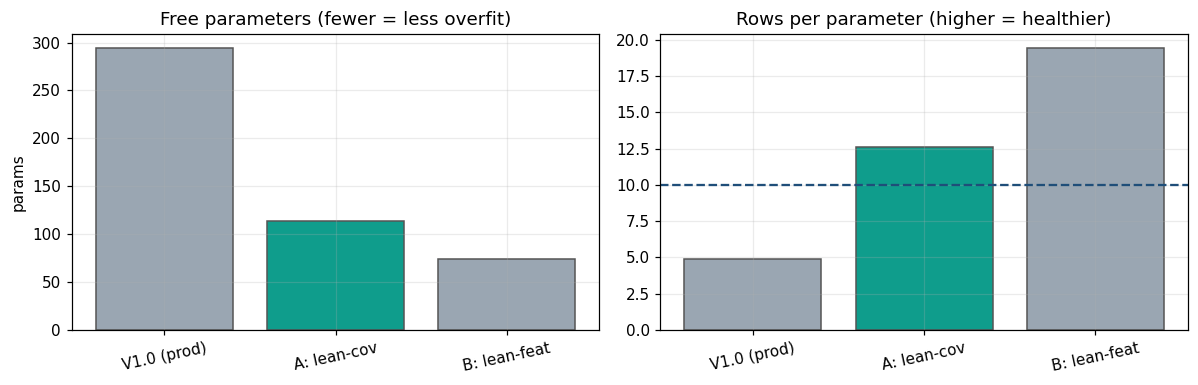

In [7]:
n_train_est = int(len(build_features(nifty, vix, LOOKBACK_SCALE)) * MIN_TRAIN_FRAC)
cap_rows = []
for cfg in CONFIGS:
    F = len(cfg['features']); p = int(n_params(cfg['N'], F, cfg['cov']))
    cap_rows.append(dict(config=cfg['name'], N=cfg['N'], cov=cfg['cov'], n_feat=F,
                         params=p, rows_per_param=round(n_train_est / p, 1)))
cap = pd.DataFrame(cap_rows)
print(f'First-fold training rows ~= {n_train_est}. Healthier when rows/param >= ~10-20.\n')
print(cap.to_string(index=False))
_cols = ['#0F9D8C' if n == 'A: lean-cov' else '#9AA6B2' for n in cap['config']]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(cap['config'], cap['params'], color=_cols, edgecolor='#555')
ax[0].set_title('Free parameters (fewer = less overfit)'); ax[0].set_ylabel('params')
ax[1].bar(cap['config'], cap['rows_per_param'], color=_cols, edgecolor='#555')
ax[1].axhline(10, ls='--', color='#1f4e79'); ax[1].set_title('Rows per parameter (higher = healthier)')
for a in ax:
    for t in a.get_xticklabels(): t.set_rotation(12)
plt.tight_layout(); plt.show()

## 5. Run the walk-forward for all 3 configs

Same `n_iter=2000`, `CONF_L=0.5`, 4 anchored folds for every config — only the
covariance type and feature subset differ, so any spread in the results is a
capacity effect. The summary table below is the head-to-head's input.

In [8]:
print(f"Walk-forward: {len(CONFIGS)} configs x {N_FOLDS} folds, n_iter={HMM_ITER}, "
      f"CONF_L={CONF_L}, Z_HI={Z_HI}, EFF_HI={EFF_HI}, on {len(nifty)} 2h bars "
      f"({'SYNTHETIC' if TAC_SYNTH else 'REAL'} data)\n")
if TAC_SYNTH:
    print("*** TAC_SYNTH = True: every result below is on SYNTHETIC data. "
          "ILLUSTRATIVE ONLY -- structural conclusions (e.g. which folds are shared "
          "losers across configs) may transfer, exact Sharpe/return values will not. ***\n")

diag = {}       # config name -> walk_forward_diag() output
summary_rows = []
for cfg in CONFIGS:
    out = walk_forward_diag(nifty, vix, N_STATES=cfg['N'],
                            covariance_type=cfg['cov'], feature_subset=cfg['features'])
    if out is None:
        continue
    diag[cfg['name']] = out
    sh = np.array([f['sharpe'] for f in out['config_folds']])
    pooled_r = np.concatenate([np.asarray(f['bar_returns']) for f in out['config_folds']])
    ppy = 252 * BARS_PER_DAY
    pooled_sharpe = pooled_r.mean() / pooled_r.std() * np.sqrt(ppy) if pooled_r.std() > 0 else np.nan
    summary_rows.append(dict(config=cfg['name'],
                             sharpe_mean=np.nanmean(sh), sharpe_min=np.nanmin(sh),
                             sharpe_std=np.nanstd(sh), pooled_sharpe=pooled_sharpe,
                             pos_folds=float(np.mean(sh > 0)),
                             switches=int(np.mean([f['switches'] for f in out['config_folds']])),
                             nonconv=out['nonconv']))

summary = pd.DataFrame(summary_rows)
fmt = summary.copy()
for c in ['sharpe_mean', 'sharpe_min', 'sharpe_std', 'pooled_sharpe']:
    fmt[c] = fmt[c].map(lambda v: f'{v:.2f}')
fmt['pos_folds'] = fmt['pos_folds'].map(lambda v: f'{v:.0%}')
print('=== Walk-forward summary (direction+intensity labeling, identical for all configs) ===')
print(fmt.to_string(index=False))
if TAC_SYNTH:
    print('\n*** SYNTHETIC data -- illustrative only. ***')
summary

Walk-forward: 3 configs x 4 folds, n_iter=2000, CONF_L=0.5, Z_HI=0.5, EFF_HI=0.35, on 2894 2h bars (REAL data)

=== Walk-forward summary (direction+intensity labeling, identical for all configs) ===
      config sharpe_mean sharpe_min sharpe_std pooled_sharpe pos_folds  switches  nonconv
 V1.0 (prod)        0.62      -1.78       1.45          0.79       75%        56    False
 A: lean-cov        0.80      -0.91       1.35          0.76       50%        65    False
B: lean-feat        0.21      -1.66       1.83          0.56       50%        73    False


,config,sharpe_mean,sharpe_min,sharpe_std,pooled_sharpe,pos_folds,switches,nonconv
0,V1.0 (prod),0.623272,-1.776293,1.452956,0.787814,0.75,56,False
1,A: lean-cov,0.800794,-0.912872,1.353269,0.759592,0.50,65,False
2,B: lean-feat,0.207188,-1.657100,1.828171,0.561801,0.50,73,False


## 5b. Head-to-head result + comparison chart

The walk-forward summary above, ranked by **worst-fold Sharpe** and annotated
with parameter count / rows-per-param, plus a four-panel visual: the decision
metric (worst fold), the Sharpe spread and floor, model size vs data budget, and
regime churn. The winner is the config with the least-bad floor — a detector
that only shines in its best quarter is not production-viable.

=== HEAD-TO-HEAD -- ranked by WORST-FOLD Sharpe (most stable first) ===
      config  params  rows_per_param sharpe_mean sharpe_min sharpe_std pooled_sharpe pos_folds  switches
 A: lean-cov     114            12.6        0.80      -0.91       1.35          0.76       50%        65
B: lean-feat      74            19.4        0.21      -1.66       1.83          0.56       50%        73
 V1.0 (prod)     294             4.9        0.62      -1.78       1.45          0.79       75%        56

Winner by worst-fold Sharpe: A: lean-cov


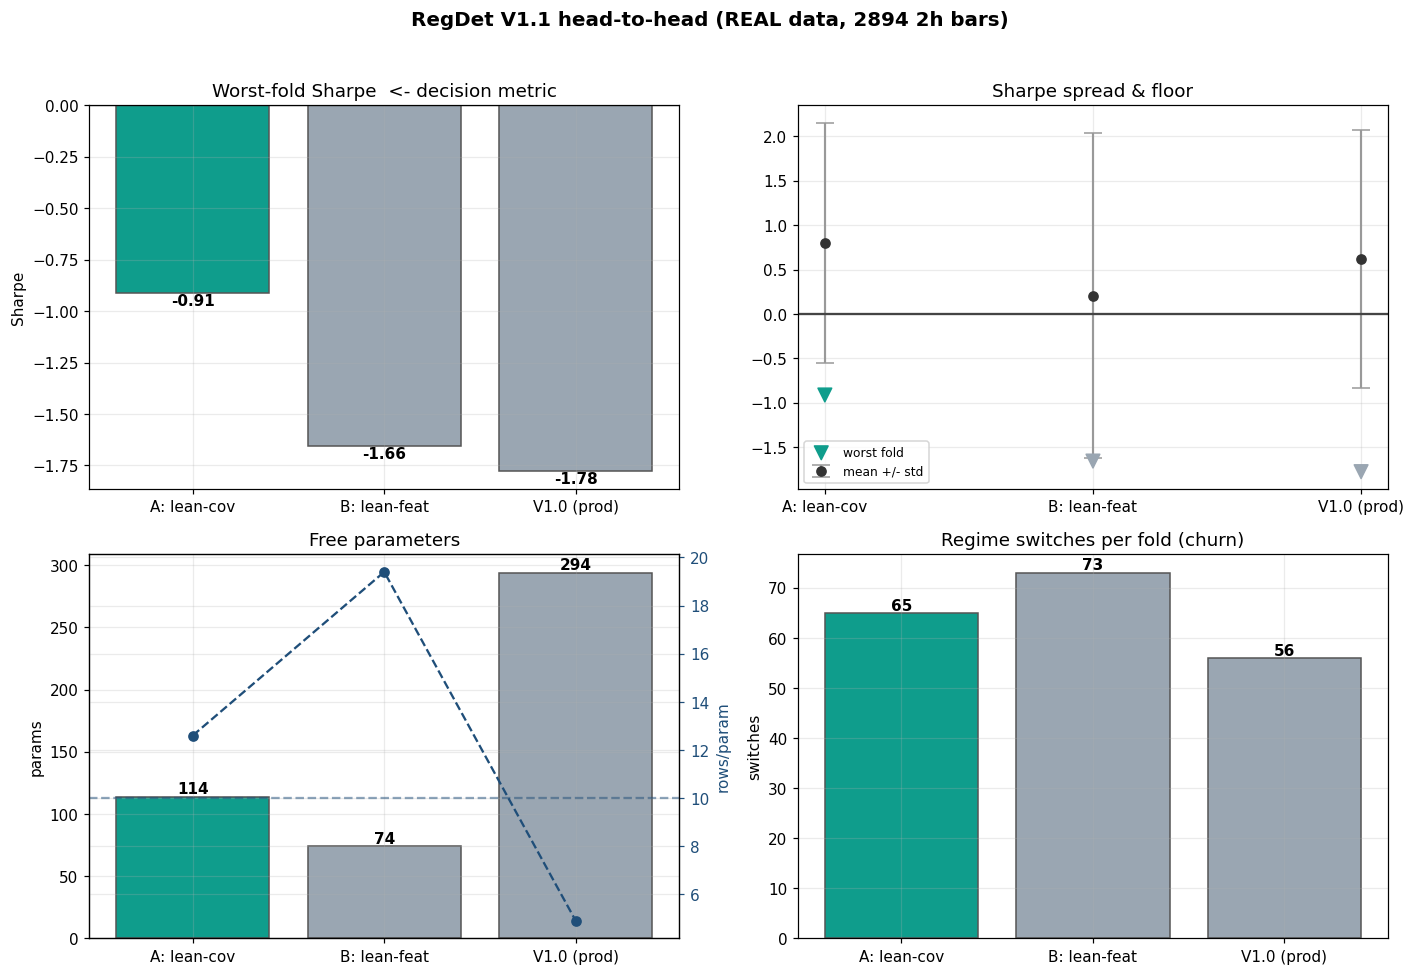

In [9]:
_cap = {c['name']: (int(n_params(c['N'], len(c['features']), c['cov'])), len(c['features'])) for c in CONFIGS}
h2h = summary.copy()
h2h['params'] = h2h['config'].map(lambda n: _cap[n][0])
h2h['n_feat'] = h2h['config'].map(lambda n: _cap[n][1])
h2h['rows_per_param'] = (n_train_est / h2h['params']).round(1)
h2h = h2h.sort_values('sharpe_min', ascending=False).reset_index(drop=True)
_show = ['config', 'params', 'rows_per_param', 'sharpe_mean', 'sharpe_min',
         'sharpe_std', 'pooled_sharpe', 'pos_folds', 'switches']
_f = h2h[_show].copy()
for c in ['sharpe_mean', 'sharpe_min', 'sharpe_std', 'pooled_sharpe']:
    _f[c] = _f[c].map(lambda v: f'{v:.2f}')
_f['pos_folds'] = _f['pos_folds'].map(lambda v: f'{v:.0%}')
print('=== HEAD-TO-HEAD -- ranked by WORST-FOLD Sharpe (most stable first) ===')
print(_f.to_string(index=False))
best_name = h2h.iloc[0]['config']
print(f'\nWinner by worst-fold Sharpe: {best_name}')
if TAC_SYNTH:
    print('*** SYNTHETIC data -- ranking illustrative only. ***')

order = list(h2h['config'])
_c = ['#0F9D8C' if n == best_name else '#9AA6B2' for n in order]
smin = list(h2h['sharpe_min']); smean = list(h2h['sharpe_mean']); sstd = list(h2h['sharpe_std'])
prm = list(h2h['params']); rpp = list(h2h['rows_per_param']); sw = list(h2h['switches'])
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'RegDet V1.1 head-to-head ({"SYNTHETIC" if TAC_SYNTH else "REAL"} data, {len(nifty)} 2h bars)',
             fontsize=13, fontweight='bold', y=0.98)
a = ax[0, 0]; a.bar(order, smin, color=_c, edgecolor='#555'); a.axhline(0, color='#444')
a.set_title('Worst-fold Sharpe  <- decision metric'); a.set_ylabel('Sharpe')
for i, v in enumerate(smin): a.text(i, v, f'{v:.2f}', ha='center', va='bottom' if v >= 0 else 'top', fontweight='bold')
a = ax[0, 1]; x = np.arange(len(order))
a.errorbar(x, smean, yerr=sstd, fmt='o', color='#333', ecolor='#999', capsize=6, linewidth=0, elinewidth=1.4, label='mean +/- std')
a.scatter(x, smin, marker='v', s=80, color=_c, zorder=5, label='worst fold')
a.axhline(0, color='#444'); a.set_xticks(x); a.set_xticklabels(order); a.set_title('Sharpe spread & floor'); a.legend(fontsize=8)
a = ax[1, 0]; a.bar(order, prm, color=_c, edgecolor='#555'); a.set_title('Free parameters'); a.set_ylabel('params')
for i, v in enumerate(prm): a.text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')
a2 = a.twinx(); a2.plot(order, rpp, 'o--', color='#1f4e79'); a2.axhline(10, ls='--', color='#1f4e79', alpha=0.5)
a2.set_ylabel('rows/param', color='#1f4e79'); a2.tick_params(axis='y', colors='#1f4e79')
a = ax[1, 1]; a.bar(order, sw, color=_c, edgecolor='#555'); a.set_title('Regime switches per fold (churn)'); a.set_ylabel('switches')
for i, v in enumerate(sw): a.text(i, v, f'{v}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

## 5d. Seed stability — **did the seed ensemble fix the identifiability problem?**

**The problem this section previously diagnosed.** `hmm.GaussianHMM` is trained
by EM, a *local* optimizer, and every fit used a single fixed `random_state=42`.
Refitting the *same* bars with different seeds landed EM in different local
optima: a train-log-likelihood spread of ~1030 nats across 8 seeds on the
full-covariance config, and a segmentation that genuinely differed between fits.
That is why two real-data runs of identical code, 3 bars apart out of 2891,
flipped the config winner and moved worst-fold Sharpe by **1.79 units**.

**What was ruled out.** Multi-restart EM keeping the highest-train-likelihood fit
is the textbook remedy and it does **not** work here. It collapses the
likelihood spread (1032 → 36 nats) but *not* the segmentation: two independent
pools of 10 restarts still agreed only ~0.67 (full) / ~0.80 (diag) by adjusted
Rand index. The likelihood surface has a **plateau of near-equivalent optima that
segment the data differently**, so "pick the best likelihood" just picks an
arbitrary point on the plateau.

**What is implemented instead — the seed ensemble.** `ENSEMBLE_K` models are fit
with seeds `BASE_SEED + 0..K-1` on the same training slice, and their
**direction-bucket probability masses** (bull / side / bear) are averaged. Raw
HMM state indices cannot be averaged across fits — they are arbitrary integers
that permute freely — but direction masses are **permutation-invariant semantic
quantities**, so they can. Everything downstream of the masses is untouched:
the `Z_HI` magnitude gate, the `EFF_HI` chop filter, the `CONF_L` SIDEWAYS
override, `N_STATES`, `HMM_ITER`, the folds, the features and the 5 output
labels are bit-for-bit the same code. **Only the source of the masses changed.**
Causality is preserved trivially: an average of K quantities each depending only
on bars `<= t` depends only on bars `<= t`.

**What is run here.** Both arms, side by side, on identical data / folds /
thresholds:

* **SINGLE** — `ensemble_k=1`, one fit per seed, seeds `SEEDS`. This is the old
  behaviour and the baseline to beat.
* **ENSEMBLE** — `ensemble_k=ENSEMBLE_K`, seeds `base..base+K-1` for each base in
  `ENS_BASES`. The bases are spaced `>= ENSEMBLE_K` apart (asserted), so the
  ensembles are built from **disjoint** pools of fits — otherwise they would
  agree merely by sharing members.

Same three reports as before, now per arm: the across-seed distribution of
`sharpe_mean` / `sharpe_min`, the win count for the worst-fold-Sharpe crown, and
pairwise **label** agreement (the 5 named labels — never raw state integers).

**FALSIFIABLE CRITERION, fixed before the numbers are seen.** The ensemble
SUCCEEDS only if **both**:

1. mean pairwise label agreement rises **materially** — at least
   `AGREE_UPLIFT_MIN` = **5.0 percentage points** — versus the single-fit arm; **and**
2. the win count **concentrates**: the modal config takes the worst-fold-Sharpe
   crown in `>= 75%` of runs under the ensemble (it need not be the same config
   the single-fit arm favoured — that arm's choice is the thing under suspicion).

Anything else is a **FAILURE**, and a failure is printed as such. Nothing below
is tuned to make this pass; a negative result here is a useful result and is the
signal to try a different stabilisation (deterministic k-means init, fewer
states, a different model family) rather than to proceed.

In [10]:
# --- 5d. Seed stability: SEED ENSEMBLE vs SINGLE FIT ----------------------
# Purely additive diagnostic. Same bars, same folds, same labeling, same
# Z_HI / EFF_HI / CONF_L / N_STATES / HMM_ITER. Two arms differ ONLY in how the
# HMM is fit. Nothing here writes to best_name / diag / summary / h2h; all
# locals are sd_ / seed_ prefixed.
import itertools as _sd_it
import time as _sd_time

N_SEEDS   = 6
SEEDS     = [42, 0, 1, 7, 123, 2024][:N_SEEDS]           # SINGLE-fit arm: one fit each
ENS_BASES = [42, 100, 200, 300, 400, 500][:N_SEEDS]      # ENSEMBLE arm: base seed of each pool

# The ensembles must be built from DISJOINT pools of fits, or they would agree
# with each other merely by sharing members rather than by being identified.
assert min(np.diff(np.sort(np.array(ENS_BASES)))) >= ENSEMBLE_K, \
    'ensemble seed pools overlap -> the agreement comparison would be rigged'
# Base 42 with the default K is exactly what Sections 5/5c/7 use, so it can be
# used as the guard row below.
assert ENS_BASES[0] == BASE_SEED, 'first ensemble base must be BASE_SEED for the guard'


def _sd_run_arm(bases, k, tag):
    out = {}
    t0 = _sd_time.time()
    for sd_cfg in CONFIGS:
        for b in bases:
            o = walk_forward_diag(nifty, vix, N_STATES=sd_cfg['N'],
                                  covariance_type=sd_cfg['cov'],
                                  feature_subset=sd_cfg['features'],
                                  random_state=b, ensemble_k=k)
            if o is None:
                continue
            sh = np.array([f['sharpe'] for f in o['config_folds']], dtype=float)
            out[(sd_cfg['name'], b)] = dict(sharpe_mean=float(np.nanmean(sh)),
                                            sharpe_min=float(np.nanmin(sh)),
                                            sharpes=sh, nonconv=bool(o['nonconv']))
    nfit = len(out) * N_FOLDS * k
    nnc = sum(v['nonconv'] for v in out.values())
    print(f'{tag:>18}: {len(out)} walk-forwards x {N_FOLDS} folds x K={k} = {nfit} HMM fits '
          f'in {_sd_time.time() - t0:.1f}s   (walk-forwards with >=1 non-converged EM: {nnc})')
    return out


print(f'Two arms, {len(CONFIGS)} configs x {N_SEEDS} runs each. '
      f'Data / folds / labeling / thresholds IDENTICAL; only the FIT differs.\n')
seed_diag_single = _sd_run_arm(SEEDS, 1, 'SINGLE (K=1)')
seed_diag_ens = _sd_run_arm(ENS_BASES, ENSEMBLE_K, f'ENSEMBLE (K={ENSEMBLE_K})')
seed_diag = seed_diag_ens          # the ADOPTED procedure

# GUARD: the ensemble base-42 rows must reproduce the Section 5 summary exactly,
# proving Sections 5 / 5c / 7 really run through this same ensemble path.
for _sd_r in summary.itertuples():
    _sd_ref = seed_diag_ens[(_sd_r.config, BASE_SEED)]
    assert abs(_sd_ref['sharpe_mean'] - _sd_r.sharpe_mean) < 1e-9, _sd_r.config
    assert abs(_sd_ref['sharpe_min'] - _sd_r.sharpe_min) < 1e-9, _sd_r.config
print(f'\nguard OK: ENSEMBLE base={BASE_SEED} reproduces the Section 5 summary exactly '
      f'-> Section 5 IS the ensemble path')

Two arms, 3 configs x 6 runs each. Data / folds / labeling / thresholds IDENTICAL; only the FIT differs.

      SINGLE (K=1): 18 walk-forwards x 4 folds x K=1 = 72 HMM fits in 90.5s   (walk-forwards with >=1 non-converged EM: 0)


Model is not converging.  Current: -7969.136170808372 is not greater than -7969.026239302554. Delta is -0.10993150581816735


    ENSEMBLE (K=4): 18 walk-forwards x 4 folds x K=4 = 288 HMM fits in 352.7s   (walk-forwards with >=1 non-converged EM: 0)

guard OK: ENSEMBLE base=42 reproduces the Section 5 summary exactly -> Section 5 IS the ensemble path


In [11]:
# --- 5d-i. Across-seed distribution of the two headline metrics -----------
def _sd_tbl(diag, bases):
    rows = []
    for sd_cfg in CONFIGS:
        nm = sd_cfg['name']
        mns = np.array([diag[(nm, b)]['sharpe_mean'] for b in bases])
        mis = np.array([diag[(nm, b)]['sharpe_min'] for b in bases])
        rows.append(dict(config=nm,
                         mean_lo=mns.min(), mean_med=float(np.median(mns)), mean_hi=mns.max(),
                         mean_std=mns.std(), mean_range=mns.max() - mns.min(),
                         min_lo=mis.min(), min_med=float(np.median(mis)), min_hi=mis.max(),
                         min_std=mis.std(), min_range=mis.max() - mis.min()))
    return pd.DataFrame(rows)


seed_tbl_single = _sd_tbl(seed_diag_single, SEEDS)
seed_tbl_ens = _sd_tbl(seed_diag_ens, ENS_BASES)
seed_tbl = seed_tbl_ens            # adopted procedure

print(f'=== 5d-i. ACROSS-SEED DISPERSION, {N_SEEDS} runs per arm ===')
print('    (data, folds, labeling, Z_HI/EFF_HI/CONF_L/N_STATES/HMM_ITER all fixed)')
print('    LOWER std / range = MORE identified. This is the whole point of the fix.\n')
print(f"{'config':<13} {'metric':<12} {'SINGLE std':>11} {'ENS std':>9} "
      f"{'SINGLE range':>13} {'ENS range':>10} {'range shrink':>13}")
print('-' * 86)
for sd_cfg in CONFIGS:
    nm = sd_cfg['name']
    s_row = seed_tbl_single[seed_tbl_single['config'] == nm].iloc[0]
    e_row = seed_tbl_ens[seed_tbl_ens['config'] == nm].iloc[0]
    for metric, sk, ek in (('sharpe_mean', 'mean_std', 'mean_range'),
                           ('sharpe_min', 'min_std', 'min_range')):
        shrink = (1.0 - e_row[ek] / s_row[ek]) if s_row[ek] > 0 else float('nan')
        print(f'{nm:<13} {metric:<12} {s_row[sk]:>11.2f} {e_row[sk]:>9.2f} '
              f'{s_row[ek]:>13.2f} {e_row[ek]:>10.2f} {shrink:>12.0%}')

print('\n-- full sorted per-run sharpe_min, one row per config per arm --')
for sd_cfg in CONFIGS:
    nm = sd_cfg['name']
    v1 = sorted(seed_diag_single[(nm, b)]['sharpe_min'] for b in SEEDS)
    v6 = sorted(seed_diag_ens[(nm, b)]['sharpe_min'] for b in ENS_BASES)
    print(f'  {nm:<13} SINGLE   [' + ', '.join(f'{v:6.2f}' for v in v1) + ']')
    print(f'  {nm:<13} ENSEMBLE [' + ', '.join(f'{v:6.2f}' for v in v6) + ']')

print(f'\nFor scale: the real-data 3-bar (0.1%) perturbation moved '
      f"'A: lean-cov' worst-fold Sharpe by 1.79 units.")
print(f"Largest seed-only worst-fold swing  SINGLE: {seed_tbl_single['min_range'].max():.2f}  "
      f"ENSEMBLE: {seed_tbl_ens['min_range'].max():.2f}  Sharpe units.")

=== 5d-i. ACROSS-SEED DISPERSION, 6 runs per arm ===
    (data, folds, labeling, Z_HI/EFF_HI/CONF_L/N_STATES/HMM_ITER all fixed)
    LOWER std / range = MORE identified. This is the whole point of the fix.

config        metric        SINGLE std   ENS std  SINGLE range  ENS range  range shrink
--------------------------------------------------------------------------------------
V1.0 (prod)   sharpe_mean         0.55      0.28          1.63       0.81          50%
V1.0 (prod)   sharpe_min          0.94      0.40          2.69       1.29          52%
A: lean-cov   sharpe_mean         0.47      0.29          1.23       0.80          35%
A: lean-cov   sharpe_min          0.63      0.52          1.94       1.31          32%
B: lean-feat  sharpe_mean         0.38      0.37          1.12       1.10           2%
B: lean-feat  sharpe_min          0.75      0.38          2.23       1.28          43%

-- full sorted per-run sharpe_min, one row per config per arm --
  V1.0 (prod)   SINGLE   [ -2.

In [12]:
# --- 5d-ii. Win count: who takes the worst-fold-Sharpe crown, run by run --
def _sd_wins(diag, bases):
    wins = {c['name']: 0 for c in CONFIGS}
    by_run = {}
    for b in bases:
        best, bv = None, -np.inf
        for c in CONFIGS:
            v = diag[(c['name'], b)]['sharpe_min']
            if np.isfinite(v) and v > bv:
                best, bv = c['name'], v
        by_run[b] = best
        if best is not None:
            wins[best] += 1
    tbl = (pd.DataFrame([dict(config=c['name'], wins=wins[c['name']],
                              win_rate=wins[c['name']] / len(bases)) for c in CONFIGS])
           .sort_values('wins', ascending=False).reset_index(drop=True))
    return wins, by_run, tbl


seed_wins_single, seed_winner_single, seed_win_tbl_single = _sd_wins(seed_diag_single, SEEDS)
seed_wins, seed_winner_by_seed, seed_win_tbl = _sd_wins(seed_diag_ens, ENS_BASES)

print('=== 5d-ii. WIN COUNT by worst-fold Sharpe (the headline) ===\n')
# NOTE: the loop variable is _sd_dg, NOT `diag` -- `diag` is the Section 5
# walk-forward dict that Sections 6a/6b/7c still read, and rebinding it here
# would silently break them.
for _sd_tag, _sd_bs, _sd_dg, _sd_by in (
        ('SINGLE (K=1)', SEEDS, seed_diag_single, seed_winner_single),
        (f'ENSEMBLE (K={ENSEMBLE_K})', ENS_BASES, seed_diag_ens, seed_winner_by_seed)):
    print(f'-- {_sd_tag} --')
    print(f"{'seed':>7}  {'winner':<13}  " + '  '.join(f"{c['name']:>13}" for c in CONFIGS))
    for b in _sd_bs:
        print(f'{b:>7}  {str(_sd_by[b]):<13}  ' +
              '  '.join(f"{_sd_dg[(c['name'], b)]['sharpe_min']:>13.2f}" for c in CONFIGS))
    print()

seed_modal_winner_single = seed_win_tbl_single.iloc[0]['config']
seed_modal_share_single = float(seed_win_tbl_single.iloc[0]['win_rate'])
seed_modal_winner = seed_win_tbl.iloc[0]['config']
seed_modal_share = float(seed_win_tbl.iloc[0]['win_rate'])

print(f"{'arm':<20} {'modal winner':<14} {'share':>7}  {'distinct winners':>17}")
print('-' * 62)
print(f"{'SINGLE (K=1)':<20} {seed_modal_winner_single:<14} {seed_modal_share_single:>6.0%}  "
      f"{len(set(seed_winner_single.values())):>16}")
print(f"{'ENSEMBLE (K=' + str(ENSEMBLE_K) + ')':<20} {seed_modal_winner:<14} "
      f"{seed_modal_share:>6.0%}  {len(set(seed_winner_by_seed.values())):>16}")
print(f"\nSection 5b winner (the adopted config, base seed {BASE_SEED}): {best_name}")

=== 5d-ii. WIN COUNT by worst-fold Sharpe (the headline) ===

-- SINGLE (K=1) --
   seed  winner           V1.0 (prod)    A: lean-cov   B: lean-feat
     42  V1.0 (prod)            -1.91          -2.25          -2.55
      0  V1.0 (prod)             0.44          -1.98          -1.18
      1  A: lean-cov            -1.35          -0.30          -1.35
      7  B: lean-feat           -2.25          -1.95          -0.56
    123  B: lean-feat           -2.03          -1.56          -0.56
   2024  B: lean-feat           -0.60          -1.80          -0.32

-- ENSEMBLE (K=4) --
   seed  winner           V1.0 (prod)    A: lean-cov   B: lean-feat
     42  A: lean-cov            -1.78          -0.91          -1.66
    100  B: lean-feat           -2.16          -0.85          -0.38
    200  B: lean-feat           -1.33          -2.16          -1.21
    300  B: lean-feat           -1.64          -1.86          -1.22
    400  V1.0 (prod)            -0.86          -2.07          -1.06
    500  B: l

In [13]:
# --- 5d-iii. Label agreement across runs, both arms -----------------------
# Compare the 5 NAMED labels, never the raw HMM state integers: state indices
# are arbitrary and permute freely between fits, so integer agreement would be
# meaningless. Same full-series protocol as the Section 5c regime map: scaler
# and HMM(s) fit on the leading MIN_TRAIN_FRAC only, labels emitted for all bars.
sd_lcfg = next(c for c in CONFIGS if c['name'] == best_name)
sd_ldf = build_features(nifty, vix, LOOKBACK_SCALE)
sd_lfeat = sd_lcfg['features']
sd_lX = sd_ldf[sd_lfeat].values
sd_ldates = sd_ldf.index
sd_lntr = max(int(len(sd_lX) * MIN_TRAIN_FRAC), 50)
sd_lsc = StandardScaler().fit(sd_lX[:sd_lntr])
sd_lXs = sd_lsc.transform(sd_lX)


def _sd_label_runs(bases, k):
    labs = {}
    for b in bases:
        ms, _ = fit_hmm_ensemble(sd_lXs[:sd_lntr], sd_lcfg['N'], sd_lcfg['cov'],
                                 K=k, base_seed=b)
        labs[b] = label_bars(ms, sd_lXs, sd_ldates, nifty,
                             sd_ldf[TREND_FEATURE].values, sd_lntr, sd_lfeat,
                             dir_feats=sd_ldf)['tactical_regime_state'].values
    return labs


def _sd_agree(labs, bases):
    pairs = [dict(a=x, b=y, agreement=float(np.mean(labs[x] == labs[y])))
             for x, y in _sd_it.combinations(bases, 2)]
    t = pd.DataFrame(pairs)
    return t, float(t['agreement'].mean()), float(t['agreement'].min()), float(t['agreement'].max())


seed_labels_single = _sd_label_runs(SEEDS, 1)
seed_labels = _sd_label_runs(ENS_BASES, ENSEMBLE_K)

seed_pair_tbl_single, seed_agree_mean_single, seed_agree_min_single, seed_agree_max_single = \
    _sd_agree(seed_labels_single, SEEDS)
seed_pair_tbl, seed_agree_mean, seed_agree_min, seed_agree_max = \
    _sd_agree(seed_labels, ENS_BASES)
seed_agree_uplift = seed_agree_mean - seed_agree_mean_single

print(f"=== 5d-iii. LABEL AGREEMENT across runs -- config '{best_name}' ===")
print(f'    {len(sd_ldates)} bars, {len(seed_pair_tbl)} run pairs per arm, '
      f'named labels compared (NOT raw state ints)\n')
print(f"{'arm':<20} {'mean':>8} {'worst pair':>12} {'best pair':>11}")
print('-' * 54)
print(f"{'SINGLE (K=1)':<20} {seed_agree_mean_single:>7.1%} {seed_agree_min_single:>11.1%} "
      f"{seed_agree_max_single:>10.1%}")
print(f"{'ENSEMBLE (K=' + str(ENSEMBLE_K) + ')':<20} {seed_agree_mean:>7.1%} "
      f"{seed_agree_min:>11.1%} {seed_agree_max:>10.1%}")
print(f"\n  UPLIFT in mean pairwise agreement: {100 * seed_agree_uplift:+.1f} percentage points "
      f"({seed_agree_mean_single:.1%} -> {seed_agree_mean:.1%})")

print('\n  per-run label distribution under the ENSEMBLE '
      '(shows whether runs even agree on the mix):')
print('    ' + f"{'base':>7}  " + '  '.join(f'{l:>9}' for l in REGIME_LABELS))
for b in ENS_BASES:
    _sd_vc = pd.Series(seed_labels[b]).value_counts(normalize=True)
    print('    ' + f'{b:>7}  ' +
          '  '.join(f'{100 * _sd_vc.get(l, 0.0):>8.1f}%' for l in REGIME_LABELS))

=== 5d-iii. LABEL AGREEMENT across runs -- config 'A: lean-cov' ===
    2874 bars, 15 run pairs per arm, named labels compared (NOT raw state ints)

arm                      mean   worst pair   best pair
------------------------------------------------------
SINGLE (K=1)           73.9%       47.3%     100.0%
ENSEMBLE (K=4)         95.5%       92.0%      99.0%

  UPLIFT in mean pairwise agreement: +21.6 percentage points (73.9% -> 95.5%)

  per-run label distribution under the ENSEMBLE (shows whether runs even agree on the mix):
       base     H_BULL     L_BULL   SIDEWAYS     L_BEAR     H_BEAR
         42      22.9%      16.2%      36.0%       8.3%      16.5%
        100      23.1%      16.5%      36.6%       7.8%      16.0%
        200      22.5%      15.1%      34.5%       9.8%      18.0%
        300      22.7%      15.8%      36.4%       8.6%      16.6%
        400      23.4%      17.2%      35.7%       7.1%      16.6%
        500      22.7%      15.6%      36.4%       8.4%      17

In [14]:
# --- 5d-iv. VERDICT -------------------------------------------------------
# Criterion fixed BEFORE the numbers were seen. Nothing above is tuned to pass it.
AGREE_UPLIFT_MIN  = 0.05      # 5.0 percentage points of mean pairwise label agreement
SEED_WIN_THRESH   = 0.75      # modal config must take the crown in >= 75% of runs
SEED_AGREE_THRESH = 0.80      # absolute identification bar (reported, not part of the fix test)

fix_uplift_ok = (seed_agree_mean - seed_agree_mean_single) >= AGREE_UPLIFT_MIN
fix_concentrated_ok = seed_modal_share >= SEED_WIN_THRESH
fix_worked = bool(fix_uplift_ok and fix_concentrated_ok)

seed_agree_ok = seed_agree_mean >= SEED_AGREE_THRESH
seed_identified = bool(fix_concentrated_ok and seed_agree_ok)

print('=' * 78)
print(f'5d VERDICT -- DID THE SEED ENSEMBLE (K={ENSEMBLE_K}) FIX IDENTIFIABILITY?')
print('=' * 78)
print(f'Runs per arm            : {N_SEEDS}')
print(f'SINGLE seeds            : {SEEDS}')
print(f'ENSEMBLE base seeds     : {ENS_BASES}  (pools of {ENSEMBLE_K}, disjoint)')
print(f'Data / folds / labeling : IDENTICAL across both arms; only the FIT differs')
print()
print('  FALSIFIABLE CRITERION (both must hold):')
print(f'   1. mean pairwise label agreement rises >= {AGREE_UPLIFT_MIN:.0%} absolute')
print(f'      -> {seed_agree_mean_single:.1%} -> {seed_agree_mean:.1%} = '
      f'{seed_agree_mean - seed_agree_mean_single:+.1%}'
      f"   [{'PASS' if fix_uplift_ok else 'FAIL'}]")
print(f'   2. win count concentrates: modal config wins >= {SEED_WIN_THRESH:.0%} of runs')
print(f"      -> '{seed_modal_winner}' won {seed_wins[seed_modal_winner]}/{N_SEEDS} "
      f'= {seed_modal_share:.0%}   (SINGLE arm was '
      f"'{seed_modal_winner_single}' at {seed_modal_share_single:.0%})"
      f"   [{'PASS' if fix_concentrated_ok else 'FAIL'}]")
print()
print(f"  RESULT: THE SEED ENSEMBLE {'WORKED' if fix_worked else 'DID NOT WORK'}")
print()

if fix_worked:
    print('  Averaging the permutation-invariant direction masses over '
          f'{ENSEMBLE_K} independent EM')
    print('  fits removed enough of the local-optimum lottery that the segmentation, and')
    print('  therefore the config ranking, is reproducible across independent seed pools.')
    print(f"  Worst-fold Sharpe now moves at most "
          f"{seed_tbl_ens['min_range'].max():.2f} units on seed alone "
          f"(was {seed_tbl_single['min_range'].max():.2f}).")
else:
    print('  The ensemble did NOT clear the bar set in advance. Stated plainly:')
    if not fix_uplift_ok:
        print(f'    * Label agreement moved {seed_agree_mean - seed_agree_mean_single:+.1%}, '
              f'short of the {AGREE_UPLIFT_MIN:.0%} required. Averaging direction')
        print('      masses is not, on this data, enough to pin down the segmentation.')
    if not fix_concentrated_ok:
        print(f"    * The worst-fold-Sharpe crown still moves: modal winner "
              f"'{seed_modal_winner}' takes it")
        print(f'      only {seed_modal_share:.0%} of the time, below the '
              f'{SEED_WIN_THRESH:.0%} required.')
    print('    * The Section 5 config ranking therefore STILL CANNOT BE TRUSTED, and neither')
    print('      could any Z_HI / EFF_HI tuning built on top of it.')
    print('    * Next things to try, in order: a deterministic k-means init (removes the')
    print('      lottery instead of averaging over it); a larger ENSEMBLE_K; fewer states;')
    print('      or accepting that a 5-state Gaussian HMM is not identifiable on ~1.5k bars')
    print('      of 2h data and moving to a model that is.')
    print(f"    * Downstream sections still proceed with '{best_name}' so the notebook runs")
    print('      end to end -- treat that choice as PROVISIONAL, not a decision.')

print()
print('  (separate, absolute question) IS THE MODEL IDENTIFIED IN ABSOLUTE TERMS?')
print(f"    winner stability >= {SEED_WIN_THRESH:.0%}      -> {seed_modal_share:.0%}   "
      f"[{'PASS' if fix_concentrated_ok else 'FAIL'}]")
print(f"    mean label agreement >= {SEED_AGREE_THRESH:.0%}  -> {seed_agree_mean:.1%}   "
      f"[{'PASS' if seed_agree_ok else 'FAIL'}]")
print(f"    -> {'IDENTIFIED' if seed_identified else 'NOT IDENTIFIED'}")
print('=' * 78)
if TAC_SYNTH:
    print('\n*** TAC_SYNTH = True: this verdict is on SYNTHETIC data and is NOT the answer.')
    print('    Synthetic bars are generated from a simple stochastic process and can be much')
    print('    easier (or harder) for EM to fit consistently than real Nifty 2h bars.')
    print('    The REAL-DATA run decides it. Re-run this section with TAC_SYNTH = False. ***')

5d VERDICT -- DID THE SEED ENSEMBLE (K=4) FIX IDENTIFIABILITY?
Runs per arm            : 6
SINGLE seeds            : [42, 0, 1, 7, 123, 2024]
ENSEMBLE base seeds     : [42, 100, 200, 300, 400, 500]  (pools of 4, disjoint)
Data / folds / labeling : IDENTICAL across both arms; only the FIT differs

  FALSIFIABLE CRITERION (both must hold):
   1. mean pairwise label agreement rises >= 5% absolute
      -> 73.9% -> 95.5% = +21.6%   [PASS]
   2. win count concentrates: modal config wins >= 75% of runs
      -> 'B: lean-feat' won 4/6 = 67%   (SINGLE arm was 'B: lean-feat' at 50%)   [FAIL]

  RESULT: THE SEED ENSEMBLE DID NOT WORK

  The ensemble did NOT clear the bar set in advance. Stated plainly:
    * The worst-fold-Sharpe crown still moves: modal winner 'B: lean-feat' takes it
      only 67% of the time, below the 75% required.
    * The Section 5 config ranking therefore STILL CANNOT BE TRUSTED, and neither
      could any Z_HI / EFF_HI tuning built on top of it.
    * Next things to tr

## 5c. Regime map — the winning config over the full series

Price shaded by the detected regime for the winner, using the **new** labeling:
direction from the HMM's aggregated bucket masses, `H` vs `L` from the magnitude
and efficiency gates, `SIDEWAYS` where the winning mass falls below `CONF_L`.
The HMM, the scaler and the trend baseline are all fit on the anchored training
fraction only (dashed line) — everything to its right is out-of-sample.

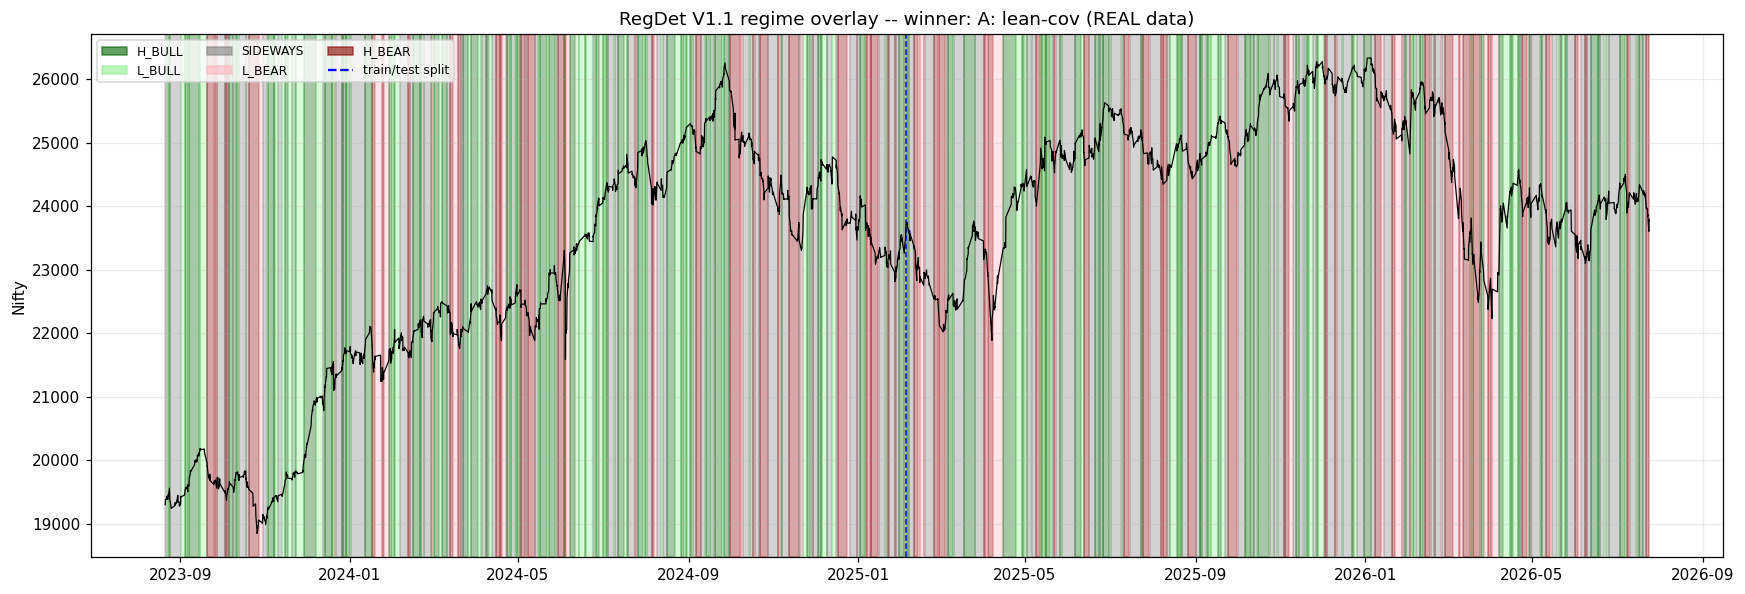

Label distribution on the winning config (full series):
  H_BULL      658 bars  ( 22.9%)
  L_BULL      467 bars  ( 16.2%)
  SIDEWAYS   1035 bars  ( 36.0%)
  L_BEAR      239 bars  (  8.3%)
  H_BEAR      475 bars  ( 16.5%)


In [15]:
_win = next(c for c in CONFIGS if c['name'] == best_name)
_df = build_features(nifty, vix, LOOKBACK_SCALE)
_feat = _win['features']; _X = _df[_feat].values; _dates = _df.index
_ntr = max(int(len(_X) * MIN_TRAIN_FRAC), 50)
_sc = StandardScaler().fit(_X[:_ntr]); _Xs = _sc.transform(_X)
_ms, _ = fit_hmm_ensemble(_Xs[:_ntr], _win['N'], _win['cov'])   # seed ensemble
_m = _ms[0]
_lab_df = label_bars(_ms, _Xs, _dates, nifty, _df[TREND_FEATURE].values, _ntr, _feat,
                     dir_feats=_df)
_lab = _lab_df['tactical_regime_state'].values
_price = nifty.reindex(_dates).ffill()

fig, ax = plt.subplots(figsize=(16, 5.5))
ax.plot(_dates, _price.values, color='black', lw=0.8, zorder=3)
_rs = 0
for t in range(1, len(_lab) + 1):
    if t == len(_lab) or _lab[t] != _lab[_rs]:
        ax.axvspan(_dates[_rs], _dates[min(t, len(_dates) - 1)],
                   color=REGIME_COLORS[_lab[_rs]], alpha=0.35, zorder=1)
        _rs = t
ax.axvline(_dates[_ntr - 1], color='blue', ls='--', lw=1)
ax.legend(handles=[mpatches.Patch(color=REGIME_COLORS[l], alpha=0.6, label=l) for l in REGIME_LABELS]
          + [plt.Line2D([0], [0], color='blue', ls='--', label='train/test split')],
          loc='upper left', fontsize=8, ncol=3)
ax.set_title(f'RegDet V1.1 regime overlay -- winner: {best_name} '
             f'({"SYNTHETIC" if TAC_SYNTH else "REAL"} data)')
ax.set_ylabel('Nifty'); plt.tight_layout(); plt.show()

_counts = pd.Series(_lab).value_counts().reindex(REGIME_LABELS).fillna(0).astype(int)
print('Label distribution on the winning config (full series):')
for l in REGIME_LABELS:
    print(f'  {l:9s} {_counts[l]:5d} bars  ({100*_counts[l]/len(_lab):5.1f}%)')

## 6a. Per-fold table for each config

Fold index, test-window start/end dates, fold Sharpe, cumulative strategy
return, buy-and-hold cumulative return and Sharpe over the *same* window,
exposure (fraction of bars in position), and switches. Read across a row to
see whether a given config's loss coincided with buy-and-hold also losing
(regime-inherent) or not (possible detector flaw); read down a column across
configs for the same fold to see whether the same windows lose for all
three.

In [16]:
pd.set_option('display.width', 200)
per_fold_tables = {}
for name, out in diag.items():
    rows = []
    for f in out['config_folds']:
        rows.append(dict(
            fold=f['fold'],
            start=f['start_date'].strftime('%Y-%m-%d %H:%M'),
            end=f['end_date'].strftime('%Y-%m-%d %H:%M'),
            n_bars=f['n_bars'],
            sharpe=round(f['sharpe'], 2),
            cum_return=f"{f['cum_return']:.2%}",
            bh_sharpe=round(f['bh_sharpe'], 2),
            bh_cum_return=f"{f['bh_cum_return']:.2%}",
            exposure=f"{f['exposure']:.0%}",
            switches=f['switches'],
        ))
    t = pd.DataFrame(rows)
    per_fold_tables[name] = t
    print(f"--- {name} ---")
    print(t.to_string(index=False))
    print()

if TAC_SYNTH:
    print("*** SYNTHETIC data -- fold-by-fold values above are illustrative only. "
          "Which folds are shared losers across configs is a structural question "
          "worth checking on real data; the exact Sharpe/return numbers will differ. ***")

--- V1.0 (prod) ---
 fold            start              end  n_bars  sharpe cum_return  bh_sharpe bh_cum_return exposure  switches
    0 2025-02-04 04:00 2025-06-18 08:00     359    1.96      5.82%       0.90         5.47%      34%        65
    1 2025-06-19 02:00 2025-10-29 02:00     359    1.56      3.63%       1.35         4.83%      40%        49
    2 2025-10-29 04:00 2026-03-11 02:00     359   -1.78     -3.34%      -1.47        -7.24%      35%        49
    3 2026-03-11 04:00 2026-07-24 08:00     360    0.75      2.55%      -0.13        -1.37%      22%        64

--- A: lean-cov ---
 fold            start              end  n_bars  sharpe cum_return  bh_sharpe bh_cum_return exposure  switches
    0 2025-02-04 04:00 2025-06-18 08:00     359    2.31      7.65%       0.90         5.47%      38%        55
    1 2025-06-19 02:00 2025-10-29 02:00     359    1.92      4.34%       1.35         4.83%      33%        65
    2 2025-10-29 04:00 2026-03-11 02:00     359   -0.91     -2.19%     

## 6b. Market-character table (config-independent)

Same 4 test windows, but purely a property of the market itself — computed
from `nifty`/`vix` alone, no detector or config involved. Lets a losing fold
be attributed to market character rather than the detector: a low-efficiency
(choppy), high-vol, no-net-trend window explains a loss largely on its own; a
strongly trending, high-efficiency window that a config still lost in does
not.

- **trend_strength** = |cumulative return| over the window (bigger = more net
  directional move)
- **ann_vol** = annualized realized volatility of bar returns in the window
- **max_drawdown** = worst peak-to-trough decline within the window
- **efficiency** = |net move| / sum(|bar moves|) — near 1 means a clean trend,
  near 0 means a choppy round-trip (classic whipsaw conditions for a long-flat
  strategy). This is the *window-level* cousin of the bar-level
  `trend_efficiency` the chop filter uses.
- **mean_vix** = average VIX level over the window (regime/fear-gauge context)

In [17]:
# Fold boundaries are identical across configs (same LOOKBACK_SCALE, same n,
# same edges) -- take them from any one config's diagnostic output.
any_out = next(iter(diag.values()))
dates_full = any_out['dates']
n_mkt = any_out['n']
edges = np.linspace(MIN_TRAIN_FRAC, 1.0, N_FOLDS + 1)
mkt_rows = []
for k in range(N_FOLDS):
    tr_end = int(n_mkt * edges[k])
    te_end = int(n_mkt * edges[k + 1])
    if tr_end < 100 or (te_end - tr_end) < 30:
        continue
    mc = market_character(nifty, vix, dates_full, tr_end, te_end)
    mc['fold'] = k
    mc['start'] = dates_full[tr_end].strftime('%Y-%m-%d %H:%M')
    mc['end'] = dates_full[te_end - 1].strftime('%Y-%m-%d %H:%M')
    mkt_rows.append(mc)

market_table = pd.DataFrame(mkt_rows)[['fold', 'start', 'end', 'trend_strength',
                                       'ann_vol', 'max_drawdown', 'efficiency', 'mean_vix']]
fmt_mkt = market_table.copy()
fmt_mkt['trend_strength'] = fmt_mkt['trend_strength'].map(lambda v: f'{v:.2%}')
fmt_mkt['ann_vol'] = fmt_mkt['ann_vol'].map(lambda v: f'{v:.1%}')
fmt_mkt['max_drawdown'] = fmt_mkt['max_drawdown'].map(lambda v: f'{v:.2%}')
fmt_mkt['efficiency'] = fmt_mkt['efficiency'].map(lambda v: f'{v:.2f}')
fmt_mkt['mean_vix'] = fmt_mkt['mean_vix'].map(lambda v: f'{v:.1f}')

print('=== Market character per fold (config-independent) ===')
print(fmt_mkt.to_string(index=False))
if TAC_SYNTH:
    print("\n*** SYNTHETIC data -- these market-character numbers describe the "
          "synthetic regime generator, not the real Nifty. Illustrative only. ***")
market_table

=== Market character per fold (config-independent) ===
 fold            start              end trend_strength ann_vol max_drawdown efficiency mean_vix
    0 2025-02-04 04:00 2025-06-18 08:00          5.23%   13.6%       -7.91%       0.05     15.7
    1 2025-06-19 02:00 2025-10-29 02:00          4.69%    7.6%       -5.01%       0.07     11.5
    2 2025-10-29 04:00 2026-03-11 02:00          7.44%   10.4%       -9.61%       0.08     12.4
    3 2026-03-11 04:00 2026-07-24 08:00          0.94%   14.6%       -7.40%       0.01     17.3


,fold,start,end,trend_strength,ann_vol,max_drawdown,efficiency,mean_vix
0,0,2025-02-04 04:00,2025-06-18 08:00,0.052337,0.135910,-0.079067,0.048570,15.697841
1,1,2025-06-19 02:00,2025-10-29 02:00,0.046893,0.076085,-0.050130,0.065208,11.544192
2,2,2025-10-29 04:00,2026-03-11 02:00,0.074391,0.104096,-0.096127,0.083970,12.361825
3,3,2026-03-11 04:00,2026-07-24 08:00,0.009354,0.145846,-0.074016,0.007509,17.345444


## 6c. Equity curves — one panel per fold, all 3 configs vs buy-and-hold

Cumulative strategy return within each test window for all three configs,
overlaid with the buy-and-hold cumulative return for the same window. Makes
the *shape* of each loss visible: a steady bleed (many small whipsaw losses,
consistent with chop) looks very different from a single sharp shock (one bad
transition/gap, consistent with a specific detector miss).

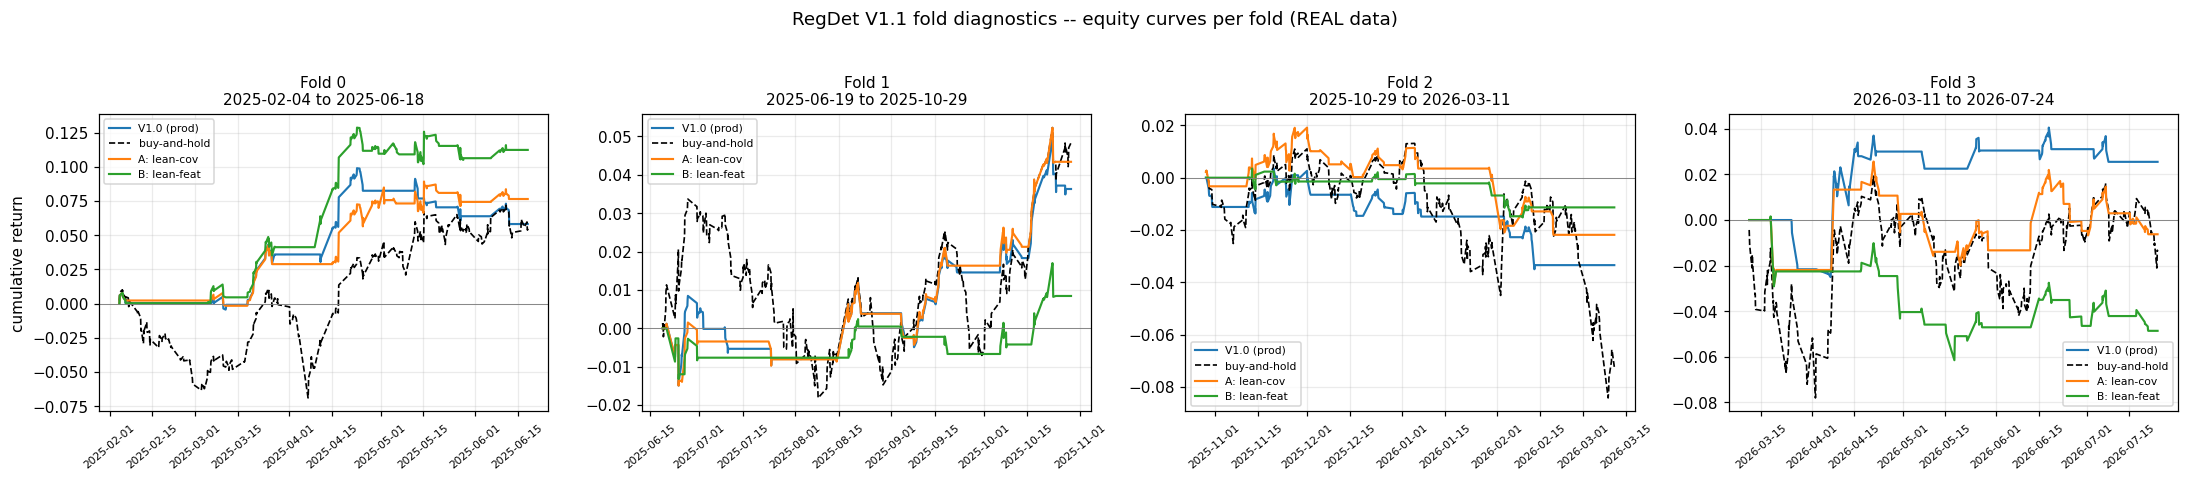

In [18]:
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5 * N_FOLDS, 4.2), sharey=False)
if N_FOLDS == 1:
    axes = [axes]
colors = {'V1.0 (prod)': '#1f77b4', 'A: lean-cov': '#ff7f0e', 'B: lean-feat': '#2ca02c'}

for k in range(N_FOLDS):
    ax = axes[k]
    bh_plotted = False
    fold_meta = None
    for name, out in diag.items():
        f = next((ff for ff in out['config_folds'] if ff['fold'] == k), None)
        if f is None:
            continue
        fold_meta = f
        cum = np.cumprod(1.0 + f['bar_returns']) - 1.0
        ax.plot(f['bar_dates'], cum, label=name, color=colors.get(name), linewidth=1.4)
        if not bh_plotted:
            bh_cum = np.cumprod(1.0 + f['bh_bar_returns']) - 1.0
            ax.plot(f['bar_dates'], bh_cum, label='buy-and-hold', color='black',
                    linewidth=1.1, linestyle='--')
            bh_plotted = True
    ax.axhline(0, color='gray', linewidth=0.6)
    title_dates = (f'{fold_meta["start_date"].strftime("%Y-%m-%d")} to '
                  f'{fold_meta["end_date"].strftime("%Y-%m-%d")}') if fold_meta is not None else ''
    ax.set_title(f'Fold {k}\n{title_dates}', fontsize=10)
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    if k == 0:
        ax.set_ylabel('cumulative return')
    ax.legend(fontsize=7, loc='best')

fig.suptitle(f'RegDet V1.1 fold diagnostics -- equity curves per fold '
            f'({"SYNTHETIC" if TAC_SYNTH else "REAL"} data)', y=1.03)
plt.tight_layout()
plt.show()
if TAC_SYNTH:
    print("*** SYNTHETIC data -- curve shapes above are illustrative only. ***")

# 7. Evaluation graph suite — do these labels mean anything?

Sections 4-6 asked *which model capacity is most stable*. This section asks a
different question: **do the regime labels themselves carry information?** It
grades the head-to-head winner fitted the way the engine actually ships it — a
single anchored fit on the first `TRAIN_FRACTION` (0.70) of bars, then classify
every bar — and runs the full visual battery:

| # | Chart | Question it answers |
|---|-------|---------------------|
| A | Master overlay + VIX | Do the shaded blocks line up with what price actually did? |
| B | Four zoomed windows | At readable resolution, are the calls sane bar-by-bar? |
| C | **Forward-return validation** | **Do the labels rank future returns monotonically? (primary evidence)** |
| D | Regime-conditional stats table | The numbers behind C, plus vol / VIX / confidence / efficiency context |
| E | Confidence + decision-plane scatter | Why was each bar graded H vs L? Is the chop filter working? |
| F | Duration histogram + transition heatmap | Are regimes persistent, or is the detector flickering? |
| G | Equity-curve context | Are the regimes actionable at all? |

> **Forward returns are EVALUATION-ONLY hindsight.** Sections C and D measure the
> return over the *next* n bars and group it by the label in force at that bar.
> That measurement never touches the detector: nothing here is fit, labeled or
> filtered with it, and the equity curve in G acts on the **prior** bar's label.
> The *detector* is strictly filtered: since the `_filtered_posteriors` fix, the
> state posterior at bar *t* is conditioned only on bars `<= t` (asserted in 7.0).
> Figures here therefore differ from pre-fix runs — see the causality note in
> Section 3.

## 7.0 Fit the winner the way production fits it, and check the invariants

One anchored **ensemble** fit (`ENSEMBLE_K` HMMs, seeds `BASE_SEED + 0..K-1`) on
the first `TRAIN_FRACTION` of bars (the engine's own setting), then label every
bar from the averaged direction masses. The asserts below are not decoration —
each one previously caught a real silent bug:

* the five `prob_*` buckets must partition to 1.0 (they once did not, after the
  H/L split was added);
* every direction bucket must be non-empty, or a whole label becomes unreachable;
* no bar may be graded `H` without clearing **both** `Z_HI` and `EFF_HI` — the
  chop filter must not be bypassable;
* **causality**: the filtered posterior used at bar *t* must equal the posterior
  a live engine would have computed from bars `0..t` alone. The probe recomputes
  `predict_proba` on the truncated prefix `X[:t+1]` — whose last row has no
  future to smooth with, making it the incremental ground truth — and demands a
  match to `1e-9`. The old full-array `predict_proba` would *fail* this test;
  that is exactly the bug being pinned down here;
* **ensemble causality**: the same probe is then run on the *averaged* masses and
  on the *emitted label itself* — recompute both from the prefix `eXs[:t+1]` and
  demand they equal the full-array values at bar `t`. Averaging K causal
  quantities is causal, but this makes that an assertion rather than an argument.

In [19]:
EVAL_CFG = next(c for c in CONFIGS if c['name'] == best_name)
eval_feat = EVAL_CFG['features']
edf = build_features(nifty, vix, LOOKBACK_SCALE)
eX_raw = edf[eval_feat].values
edates = edf.index
n_fit = max(int(len(eX_raw) * TRAIN_FRACTION), 50)
escaler = StandardScaler().fit(eX_raw[:n_fit])
eXs = escaler.transform(eX_raw)
# SEED ENSEMBLE: K anchored fits on the SAME leading n_fit bars, seeds
# BASE_SEED..BASE_SEED+K-1. `emodel` is member 0 and is kept for the reporting
# column hmm_state_int and for the causality probe below.
emodels, eall_conv = fit_hmm_ensemble(eXs[:n_fit], EVAL_CFG['N'], EVAL_CFG['cov'])
emodel = emodels[0]
print(f"Evaluating winner '{best_name}'  (N={EVAL_CFG['N']}, cov={EVAL_CFG['cov']}, "
      f"{len(eval_feat)} features)   ENSEMBLE_K={len(emodels)} "
      f"seeds={ensemble_seeds()}   all converged: {eall_conv}   "
      f"anchored fit on {n_fit}/{len(eXs)} bars ({TRAIN_FRACTION:.0%})")

reg = label_bars(emodels, eXs, edates, nifty, edf[TREND_FEATURE].values, n_fit, eval_feat,
                 dir_feats=edf)

# Context columns (engine parquet contract): price, VIX, all 9 raw features.
reg['nifty_close'] = nifty.reindex(edates).values
reg['vix_close'] = vix.reindex(edates).values
for col in FEATURE_COLS:
    reg[col] = edf[col].reindex(edates).values

# Transition warning: causal confidence drop OR VIX bar-over-bar spike.
_conf = reg['tactical_regime_confidence']
_vixa = reg['vix_close']
_twf = ((_conf.shift(1) - _conf) > HMM_PROB_DROP_THRESHOLD) | \
       ((_vixa - _vixa.shift(1)) / _vixa.shift(1) > VIX_SPIKE_THRESHOLD)
_twf.iloc[0] = False
reg['tactical_transition_warning_flag'] = _twf.values.astype(bool)

lab = reg['tactical_regime_state']
present = [r for r in REGIME_LABELS if (lab == r).sum() > 0]

# ---- INVARIANTS (each one caught a real silent bug before) -----------------
_pcols = ['prob_H_BULL', 'prob_L_BULL', 'prob_SIDEWAYS', 'prob_L_BEAR', 'prob_H_BEAR']
assert np.allclose(reg[_pcols].sum(axis=1).values, 1.0, atol=1e-6), \
    'the 5 prob_* buckets must partition to 1.0'
_dir = direction_buckets(emodel.means_, eval_feat)
# EVERY ensemble member must have all 3 buckets non-empty, not just member 0 --
# one degenerate member would silently bias the averaged masses.
for _mi, _mm in enumerate(emodels):
    _dm = direction_buckets(_mm.means_, eval_feat)
    assert (_dm == 1).any() and (_dm == -1).any() and (_dm == 0).any(), \
        f'ensemble member {_mi} has an empty direction bucket'
assert (_dir == 1).any() and (_dir == -1).any() and (_dir == 0).any(), \
    'every direction bucket must be non-empty -> every label reachable'
_ebull, _eside, _ebear, _ = ensemble_direction_masses(emodels, eXs, eval_feat)
assert np.allclose(_ebull + _eside + _ebear, 1.0, atol=1e-9), \
    'ENSEMBLE direction masses must partition to 1.0'
print(f'ENSEMBLE OK: {len(emodels)} members, all with 3 non-empty direction buckets; '
      f'averaged bull+side+bear = 1.0 on all {len(eXs)} bars '
      f'(max dev {np.abs(_ebull + _eside + _ebear - 1.0).max():.2e})')
# Chop filter under FIX 3's enter/exit bands: every H bar clears the band that is
# ACTIVE for it (exit band while held), and every ESCALATION cleared the full
# enter band. With Z_HI_EXIT==Z_HI and EFF_HI_EXIT==EFF_HI these collapse to the
# single original check.
_h = lab.isin(['H_BULL', 'H_BEAR']).values
_zx, _ex = min(Z_HI, Z_HI_EXIT), min(EFF_HI, EFF_HI_EXIT)
assert (reg.loc[_h, 'trend_efficiency'] >= _ex).all(), 'chop filter bypassed (eff below the exit band on an H bar)'
assert (reg.loc[_h, 'trend_z'].abs() >= _zx).all(), 'magnitude gate bypassed (|z| below the exit band on an H bar)'
_iv = reg['gate_intensity'].values
_on = np.flatnonzero((_iv != 0) & (_iv != np.concatenate(([0], _iv[:-1]))))
assert (reg['trend_efficiency'].values[_on] >= EFF_HI).all(), 'H escalation below EFF_HI'
assert (np.abs(reg['trend_z'].values[_on]) >= Z_HI).all(), 'H escalation below Z_HI'
print(f"INVARIANTS OK: prob_* partition to 1.0 | all 3 direction buckets non-empty "
      f"(bull={int((_dir==1).sum())}, side={int((_dir==0).sum())}, bear={int((_dir==-1).sum())}) | "
      f"all {int(_h.sum())} H bars clear the ACTIVE gate band "
      f"(|z|>={_zx}, eff>={_ex}) and all {len(_on)} escalations cleared the ENTER band "
      f"(|z|>={Z_HI}, eff>={EFF_HI})")

# ---- CAUSALITY PROBE (this is what makes "no look-ahead" a test, not a claim)
# _filtered_posteriors(model, X)[t] must equal the posterior a live engine would
# have had at bar t. The incremental ground truth is predict_proba run on the
# TRUNCATED prefix X[:t+1]: its final row has no future bars to smooth against,
# so forward-backward and forward-only coincide there. This is the ONLY place in
# the notebook that calls predict_proba, and it is deliberately the prefix form.
# The old full-array predict_proba failed this check on ~6% of bars.
_fp = _filtered_posteriors(emodel, eXs)
assert np.allclose(_fp.sum(axis=1), 1.0, atol=1e-9), 'filtered posteriors must sum to 1 per bar'
_probe = sorted({t for t in (1, n_fit, n_fit + 37, (n_fit + len(eXs)) // 2,
                             len(eXs) - 200, len(eXs) - 1) if 0 <= t < len(eXs)})
_worst = 0.0
for _t in _probe:
    _truth = emodel.predict_proba(eXs[:_t + 1])[_t]     # bars <= t only exist in this slice
    _worst = max(_worst, float(np.abs(_fp[_t] - _truth).max()))
    assert np.allclose(_fp[_t], _truth, atol=1e-9), \
        f'bar {_t}: filtered posterior != prefix-only posterior -> decode is NOT causal'
assert np.array_equal(reg['hmm_state_int'].values, _fp.argmax(axis=1)), \
    'hmm_state_int must be the FILTERED argmax'
print(f"CAUSALITY OK: filtered posterior == bars-<=-t-only posterior on probe bars "
      f"{_probe} (max abs diff {_worst:.2e}) | rows sum to 1 | hmm_state_int is the filtered argmax")

# ---- ENSEMBLE CAUSALITY PROBE ---------------------------------------------
# The ensemble must not smuggle in look-ahead. The averaged direction masses at
# bar t are recomputed from the TRUNCATED prefix eXs[:t+1] -- an incremental
# ground truth that literally cannot see bar t+1 -- and must match the masses
# taken from the full-array computation at bar t. Since the ensemble average is
# taken across models fit on the SAME leading n_fit bars, and each member's
# posterior is forward-only, this must hold to floating-point noise.
_eB, _eS, _eR, _ = ensemble_direction_masses(emodels, eXs, eval_feat)
_ens_worst = 0.0
for _t in _probe:
    _pB, _pS, _pR, _ = ensemble_direction_masses(emodels, eXs[:_t + 1], eval_feat)
    _ens_worst = max(_ens_worst, float(max(abs(_pB[_t] - _eB[_t]),
                                           abs(_pS[_t] - _eS[_t]),
                                           abs(_pR[_t] - _eR[_t]))))
assert _ens_worst < 1e-9, \
    f'ENSEMBLE masses at t differ from prefix-only masses (max {_ens_worst:.2e}) -> NOT causal'
# And the labels themselves: relabeling from a prefix must reproduce the same
# label at bar t (the trend baseline is frozen on n_fit, so it is prefix-safe).
#
# THIS IS THE PROBE THAT MATTERS FOR THE HYSTERESIS FIXES. Both FIX 2 (the
# CONFIRM_BARS confirmation delay) and FIX 3 (the enter/exit gate bands) are
# STATEFUL left-to-right scans, which is exactly the shape of change that can
# smuggle in look-ahead if written carelessly -- and this project has already
# had to remove one "smoother" that decided bar t by inspecting the realized
# length of the run containing t. So the probe is run on a DENSE bar set here,
# not just the sparse one used above: deleting every bar after t must leave the
# emitted label AT t byte-identical.
_lab_full = reg['tactical_regime_state'].values
_int_full = reg['gate_intensity'].values
_probe_hyst = sorted({t for t in list(_probe)
                      + list(range(n_fit, len(eXs), max(1, (len(eXs) - n_fit) // 20)))
                      + [len(eXs) - 1] if n_fit <= t < len(eXs)})
#
# FIX 4 rides in the same probe: `reg` is labeled at the module default
# BAR_DIR_WEIGHT, so the per-bar direction blend is LIVE in `_lab_full`, and the
# prefix relabel below recomputes the per-bar score from edf.iloc[:t+1] alone.
# The score itself is checked separately as well, since a broken baseline would
# otherwise be masked by the argmax.
_score_full = reg['bar_dir_score'].values
_lab_mismatch = _int_mismatch = _score_mismatch = 0
_score_worst = 0.0
for _t in _probe_hyst:
    _pref = label_bars(emodels, eXs[:_t + 1], edates[:_t + 1], nifty,
                       edf[TREND_FEATURE].values[:_t + 1], n_fit, eval_feat,
                       dir_feats=edf.iloc[:_t + 1])
    _lab_mismatch += int(_pref['tactical_regime_state'].values[_t] != _lab_full[_t])
    _int_mismatch += int(_pref['gate_intensity'].values[_t] != _int_full[_t])
    _ps = bar_direction_score(edf.iloc[:_t + 1], n_fit)[_t]
    _score_worst = max(_score_worst, abs(float(_ps) - float(_score_full[_t])))
    _score_mismatch += int(_ps != _score_full[_t])
assert _lab_mismatch == 0, 'label at bar t changes when future bars are removed -> LOOK-AHEAD'
assert _int_mismatch == 0, 'gate hysteresis state at bar t changes when future bars are removed -> LOOK-AHEAD'
assert _score_mismatch == 0, \
    'per-bar direction score at t changes when future bars are removed -> LOOK-AHEAD'
print(f"PER-BAR DIRECTION CAUSALITY OK: BAR_DIR_WEIGHT={BAR_DIR_WEIGHT}, score built from "
      f"{[f for f in BAR_DIR_FEATURES if f in edf.columns]} against a mu/sd baseline frozen "
      f"on the leading {n_fit} bars; the score at bar t is BIT-identical when every bar > t "
      f"is deleted ({_score_mismatch} mismatches, max dev {_score_worst:.2e}, "
      f"{len(_probe_hyst)} probe bars)")
print(f"HYSTERESIS CAUSALITY OK: with CONFIRM_BARS={CONFIRM_BARS} and gate bands "
      f"exit(|z|<{Z_HI_EXIT}, eff<{EFF_HI_EXIT}), the emitted label AND the gate state "
      f"at bar t are unchanged when every bar > t is deleted, on all "
      f"{len(_probe_hyst)} probe bars ({_lab_mismatch} label / {_int_mismatch} gate mismatches)")
print(f"ENSEMBLE CAUSALITY OK: K={len(emodels)} averaged direction masses at bar t equal the "
      f"prefix-only (bars <= t) recomputation on probe bars {_probe}")
print(f"                      max abs deviation {_ens_worst:.2e} (< 1e-9 required); "
      f"and the emitted LABEL at t is identical when bars > t are deleted "
      f"({_lab_mismatch} mismatches)")

counts = lab.value_counts().reindex(REGIME_LABELS).fillna(0).astype(int)
print("\n--- RegDet V1.1 regime distribution ---")
for l in REGIME_LABELS:
    print(f"  {l:9s} {counts[l]:5d} bars  ({100*counts[l]/len(reg):5.1f}%)")
print(f"  Transition warnings: {int(reg['tactical_transition_warning_flag'].sum())}")
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ("   -> ILLUSTRATIVE ONLY" if TAC_SYNTH else "   -> real data"))
reg.tail(3)

Evaluating winner 'A: lean-cov'  (N=5, cov=diag, 9 features)   ENSEMBLE_K=4 seeds=[42, 43, 44, 45]   all converged: True   anchored fit on 2011/2874 bars (70%)
ENSEMBLE OK: 4 members, all with 3 non-empty direction buckets; averaged bull+side+bear = 1.0 on all 2874 bars (max dev 1.44e-15)
INVARIANTS OK: prob_* partition to 1.0 | all 3 direction buckets non-empty (bull=2, side=1, bear=2) | all 1180 H bars clear the ACTIVE gate band (|z|>=0.35, eff>=0.25) and all 259 escalations cleared the ENTER band (|z|>=0.5, eff>=0.35)
CAUSALITY OK: filtered posterior == bars-<=-t-only posterior on probe bars [1, 2011, 2048, 2442, 2674, 2873] (max abs diff 1.64e-12) | rows sum to 1 | hmm_state_int is the filtered argmax
PER-BAR DIRECTION CAUSALITY OK: BAR_DIR_WEIGHT=0.5, score built from ['ret_2h', 'mom_1d', 'mom_3d', 'mom_5d', 'dist_ma'] against a mu/sd baseline frozen on the leading 2011 bars; the score at bar t is BIT-identical when every bar > t is deleted (0 mismatches, max dev 0.00e+00, 25 prob

,tactical_regime_state,tactical_regime_confidence,hmm_state_int,prob_H_BULL,prob_L_BULL,prob_SIDEWAYS,prob_L_BEAR,prob_H_BEAR,trend_z,trend_efficiency,...,ret_2h,mom_1d,mom_3d,mom_5d,vol_2h,vol_expansion,vix_chg,drawdown,dist_ma,tactical_transition_warning_flag
date,,,,,,,,,,,,,,,,,,,,,
2026-07-24 04:00:00,H_BEAR,0.806389,2,0.0,0.059065,0.134545,0.0,0.806389,-1.242023,0.553951,...,0.003980,-0.006229,-0.013851,-0.022858,0.004229,1.657599,-0.036962,0.026323,-0.014800,False
2026-07-24 06:00:00,H_BEAR,0.744823,2,0.0,0.099274,0.155904,0.0,0.744823,-0.782335,0.303980,...,0.003981,-0.003138,-0.008321,-0.018407,0.004279,1.754265,-0.009507,0.022439,-0.009874,False
2026-07-24 08:00:00,H_BEAR,0.770635,2,0.0,0.081147,0.148218,0.0,0.770635,-0.739305,0.290421,...,-0.000437,0.007524,-0.007804,-0.017746,0.004277,1.762769,-0.011731,0.019129,-0.009159,False


### Shared shading helper

`shade_regimes` collapses the label series into contiguous blocks and paints one
`axvspan` per block, so every chart below uses identical colours and block
boundaries.

In [20]:
def regime_blocks(series):
    """[(label, start_ts, end_ts), ...] contiguous runs of the same label."""
    vals, idx = series.values, series.index
    blocks, start = [], 0
    for i in range(1, len(vals)):
        if vals[i] != vals[i - 1]:
            blocks.append((vals[start], idx[start], idx[i - 1]))
            start = i
    blocks.append((vals[start], idx[start], idx[-1]))
    return blocks


def shade_regimes(ax, series, alpha=0.35):
    for lb, d0, d1 in regime_blocks(series):
        ax.axvspan(d0, d1, alpha=alpha, color=REGIME_COLORS.get(lb, '#808080'), linewidth=0)


def regime_legend(ax, loc='upper left', extra=None, **kw):
    handles = [mpatches.Patch(color=REGIME_COLORS[r], alpha=0.7, label=r) for r in REGIME_LABELS]
    if extra:
        handles += extra
    ax.legend(handles=handles, loc=loc, fontsize=8, ncol=3, **kw)


def synth_tag():
    return "  [SYNTHETIC DATA - illustrative only]" if TAC_SYNTH else "  [real yfinance data]"

print("helpers ready;" + synth_tag())

helpers ready;  [real yfinance data]


## 7A. Master regime overlay + VIX

The whole 2h series, price in black, background shaded by the detected regime,
with the India VIX and the transition-warning bars underneath.

**What to look for:** dark green (`H_BULL`) should sit under sustained up-legs and
dark red (`H_BEAR`) under sharp sell-offs; grey (`SIDEWAYS`) should dominate flat,
choppy stretches. If dark green appears in the middle of a decline — or the whole
chart is one colour — the detector is not tracking the market. This chart is
deliberately compressed; 7B gives the resolution to judge individual calls.

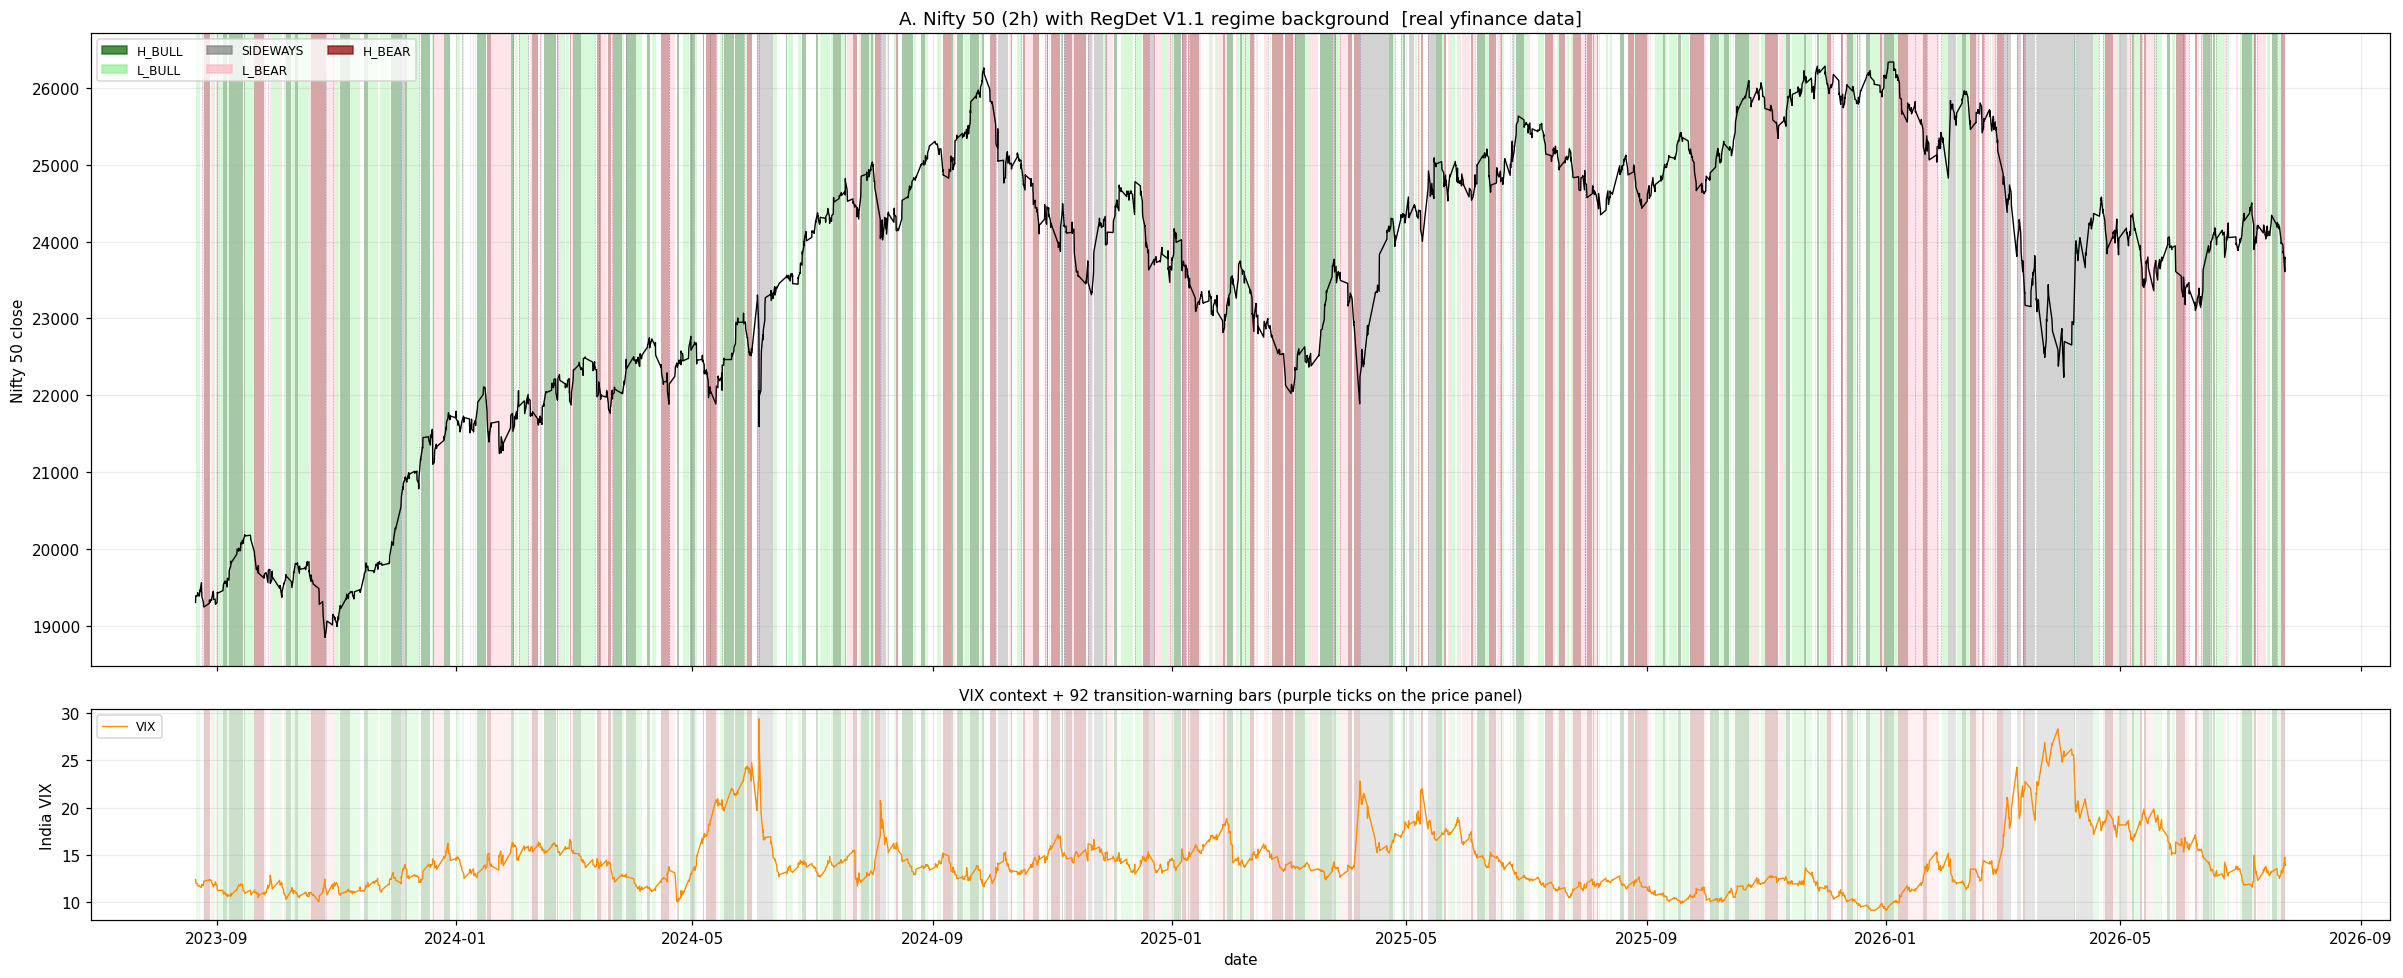

TAC_SYNTH = False


In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 9), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
shade_regimes(ax1, reg['tactical_regime_state'], alpha=0.35)
ax1.plot(reg.index, reg['nifty_close'], color='black', linewidth=0.9, label='Nifty 50 (2h)')
ax1.set_ylabel('Nifty 50 close')
ax1.set_title('A. Nifty 50 (2h) with RegDet V1.1 regime background' + synth_tag(), fontsize=12)
regime_legend(ax1)

shade_regimes(ax2, reg['tactical_regime_state'], alpha=0.20)
ax2.plot(reg.index, reg['vix_close'], color='darkorange', linewidth=0.9, label='VIX')
ax2.set_ylabel('India VIX')
ax2.set_xlabel('date')
ax2.legend(loc='upper left', fontsize=8)
warn = reg.index[reg['tactical_transition_warning_flag']]
for d in warn:
    ax1.axvline(d, color='purple', linestyle='--', linewidth=0.35, alpha=0.45)
ax2.set_title(f'VIX context + {len(warn)} transition-warning bars (purple ticks on the price panel)',
              fontsize=10)
plt.tight_layout()
plt.show()
print(f"TAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

## 7B. Four zoomed windows

The same series and shading, split into four equal consecutive windows so each
block is readable.

**What to look for:** (i) do regime changes happen near visible turning points, or
several bars late/early? (ii) are there single-bar colour flickers inside an
otherwise clean trend (over-switching)? (iii) does `H_BULL` genuinely coincide
with the steepest legs rather than appearing at random inside a range?

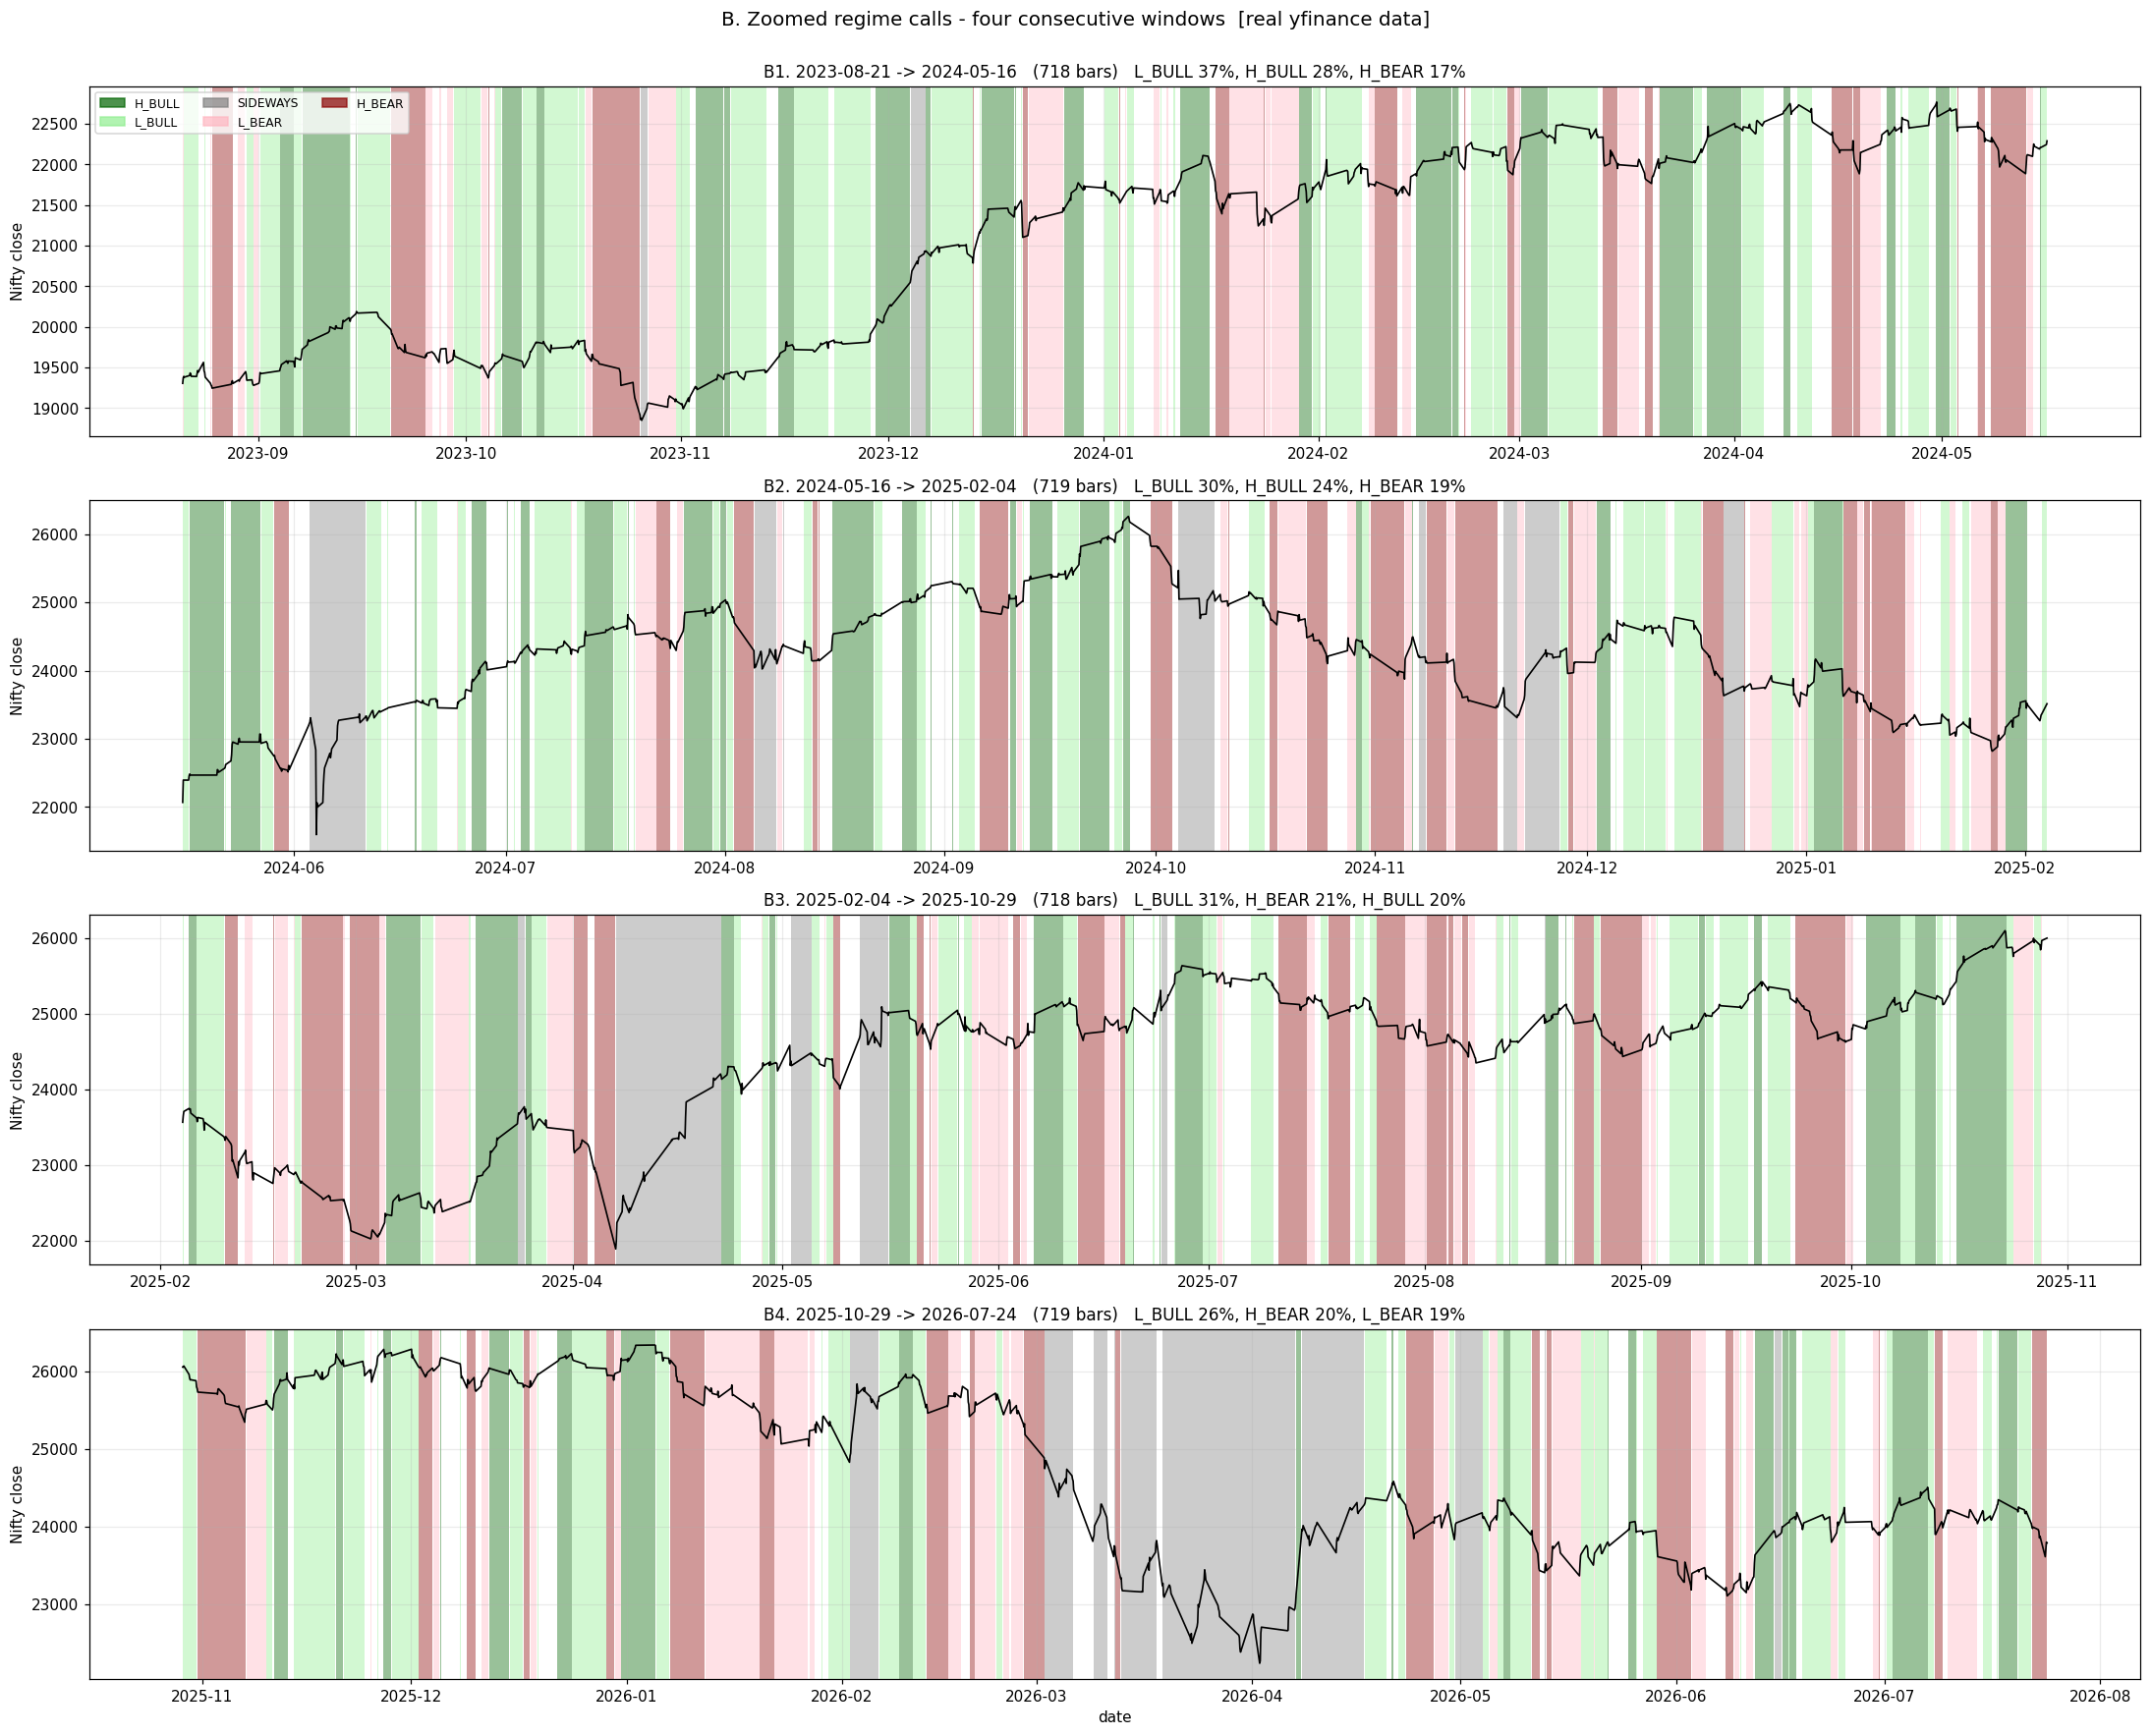

TAC_SYNTH = False


In [22]:
n_win = 4
zedges = np.linspace(0, len(reg), n_win + 1).astype(int)
fig, axes = plt.subplots(n_win, 1, figsize=(20, 4 * n_win))
for k, ax in enumerate(axes):
    sl = reg.iloc[zedges[k]:zedges[k + 1]]
    shade_regimes(ax, sl['tactical_regime_state'], alpha=0.40)
    ax.plot(sl.index, sl['nifty_close'], color='black', linewidth=1.1)
    dist = sl['tactical_regime_state'].value_counts()
    top = ', '.join(f"{l} {100*v/len(sl):.0f}%" for l, v in dist.head(3).items())
    ax.set_title(f"B{k+1}. {sl.index[0]:%Y-%m-%d} -> {sl.index[-1]:%Y-%m-%d}   ({len(sl)} bars)   {top}",
                 fontsize=11)
    ax.set_ylabel('Nifty close')
    if k == 0:
        regime_legend(ax)
axes[-1].set_xlabel('date')
fig.suptitle('B. Zoomed regime calls - four consecutive windows' + synth_tag(), fontsize=13, y=1.001)
plt.tight_layout()
plt.show()
print(f"TAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

## 7C. Forward-return validation — THE key quality graph

For every bar, measure the return over the NEXT *n* bars (`n = 3, 9, 15` ≈ 1, 3
and 5 trading days), then group those forward returns by the regime label that
was in force at that bar.

> **Hindsight, by design — EVALUATION ONLY.** Forward returns are computed here
> for MEASUREMENT ONLY. They are never used to fit, label, or filter anything —
> no forward return reaches the labeling rule, and every input to that rule is a
> backward-looking window, a fit-window constant, or a filtered posterior over
> bars `<= t` (see the causality note in Section 3). This section asks "with hindsight,
> did the labels rank the future correctly?", which is exactly the question a
> detector graded on out-of-sample behaviour is allowed to be asked.

**What to look for — monotonic ordering:**

`H_BULL  >  L_BULL  >  SIDEWAYS ≈ 0  >  L_BEAR  >  H_BEAR`

for the mean (and ideally median) forward return at every horizon. That ordering
is the single strongest evidence the labels carry information. Also check the box
plots: wide, fully-overlapping boxes mean the separation is not economically
usable even if the means happen to line up.

The printout grades two levels, because they fail for very different reasons:

* **Direction-level** (`bull bars > sideways bars > bear bars`). Breaking this
  means the detector is calling the market backwards — fatal.
* **Strict 5-label.** If this breaks only on an `H` vs `L` pair *inside* one
  direction (e.g. `H_BULL < L_BULL`), the direction signal still works and the
  *intensity gate* is mis-grading strength — a `Z_HI` / `EFF_HI` tuning problem,
  not a broken detector. Each inversion is printed by name.

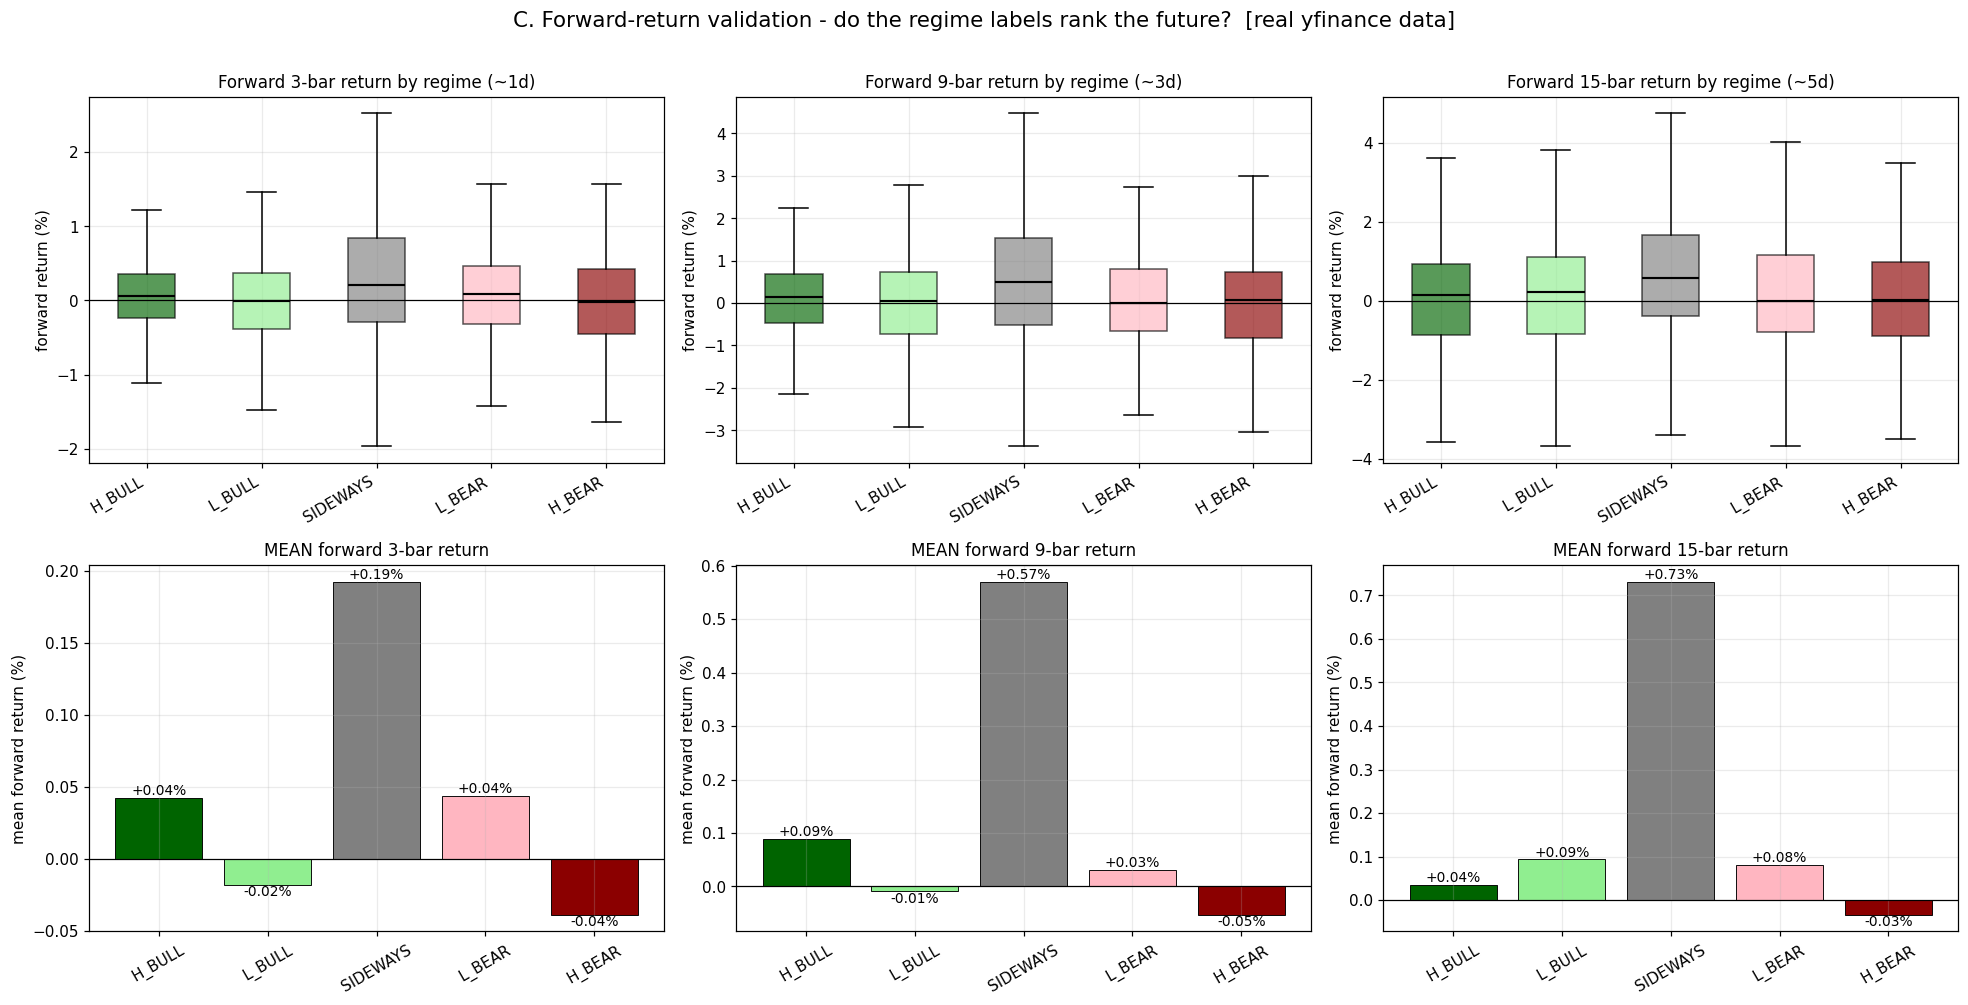

Mean forward returns (%) by regime:

          fwd_3  fwd_9  fwd_15
H_BULL    0.042  0.089   0.035
L_BULL   -0.018 -0.009   0.094
SIDEWAYS  0.192  0.570   0.731
L_BEAR    0.044  0.031   0.081
H_BEAR   -0.039 -0.053  -0.034

  fwd_ 3: strict 5-label ordering -> BROKEN   (H_BULL=+0.042, L_BULL=-0.018, SIDEWAYS=+0.192, L_BEAR=+0.044, H_BEAR=-0.039)
          inversion: L_BULL (-0.018%) < SIDEWAYS (+0.192%)
          direction-level: BULL +0.007%  SIDEWAYS +0.192%  BEAR +0.000%  -> BROKEN
  fwd_ 9: strict 5-label ordering -> BROKEN   (H_BULL=+0.089, L_BULL=-0.009, SIDEWAYS=+0.570, L_BEAR=+0.031, H_BEAR=-0.053)
          inversion: L_BULL (-0.009%) < SIDEWAYS (+0.570%)
          direction-level: BULL +0.032%  SIDEWAYS +0.570%  BEAR -0.013%  -> BROKEN
  fwd_15: strict 5-label ordering -> BROKEN   (H_BULL=+0.035, L_BULL=+0.094, SIDEWAYS=+0.731, L_BEAR=+0.081, H_BEAR=-0.034)
          inversion: H_BULL (+0.035%) < L_BULL (+0.094%)
          inversion: L_BULL (+0.094%) < SIDEWAYS (+0.731%)
    

In [23]:
close = reg['nifty_close']
fwd = pd.DataFrame(index=reg.index)
for h in FWD_HORIZONS:
    # forward n-bar simple return - EVALUATION ONLY (hindsight measurement)
    fwd[f'fwd_{h}'] = close.shift(-h) / close - 1.0

fig, axes = plt.subplots(2, len(FWD_HORIZONS), figsize=(6 * len(FWD_HORIZONS), 9))
for j, h in enumerate(FWD_HORIZONS):
    col = fwd[f'fwd_{h}']
    groups = [col[(lab == r)].dropna().values * 100 for r in present]
    means = [g.mean() if len(g) else np.nan for g in groups]

    axb = axes[0, j]
    # note: no `labels=`/`tick_labels=` kwarg - that name changed across matplotlib
    # versions; setting the ticks explicitly works on every version.
    bp = axb.boxplot(groups, patch_artist=True, showfliers=False,
                     medianprops=dict(color='black', linewidth=1.4))
    for patch, r in zip(bp['boxes'], present):
        patch.set_facecolor(REGIME_COLORS[r]); patch.set_alpha(0.65)
    axb.set_xticks(range(1, len(present) + 1))
    axb.set_xticklabels(present, rotation=30, ha='right')
    axb.axhline(0, color='black', linewidth=0.8)
    axb.set_title(f'Forward {h}-bar return by regime (~{h/BARS_PER_DAY:.0f}d)', fontsize=11)
    axb.set_ylabel('forward return (%)')

    axm = axes[1, j]
    axm.bar(present, means, color=[REGIME_COLORS[r] for r in present],
            edgecolor='black', linewidth=0.6)
    axm.axhline(0, color='black', linewidth=0.8)
    for i, m in enumerate(means):
        axm.text(i, m, f'{m:+.2f}%', ha='center',
                 va='bottom' if m >= 0 else 'top', fontsize=9)
    axm.set_title(f'MEAN forward {h}-bar return', fontsize=11)
    axm.set_ylabel('mean forward return (%)')
    axm.tick_params(axis='x', rotation=30)

fig.suptitle('C. Forward-return validation - do the regime labels rank the future?'
             + synth_tag(), fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


def mean_fwd(h, labels):
    m = lab.isin(labels)
    return 100 * fwd[f'fwd_{h}'][m].mean()


# strict = H_BULL >= L_BULL >= SIDEWAYS >= L_BEAR >= H_BEAR
# coarse = mean(bull bars) >= mean(sideways bars) >= mean(bear bars) - a weaker but
#          more important test: getting DIRECTION right matters more than the H/L
#          intensity split inside a direction.
def ordering_report(h):
    seq = [100 * fwd[f'fwd_{h}'][lab == r].mean() for r in present]
    viol = [(present[i], seq[i], present[i + 1], seq[i + 1])
            for i in range(len(seq) - 1) if seq[i] < seq[i + 1]]
    bull = mean_fwd(h, ['H_BULL', 'L_BULL'])
    side = mean_fwd(h, ['SIDEWAYS'])
    bear = mean_fwd(h, ['L_BEAR', 'H_BEAR'])
    coarse_ok = (bull >= side >= bear)
    return seq, viol, (bull, side, bear), coarse_ok


print("Mean forward returns (%) by regime:\n")
mono_tbl = pd.DataFrame(
    {f'fwd_{h}': {r: 100 * fwd[f'fwd_{h}'][lab == r].mean() for r in present}
     for h in FWD_HORIZONS})
print(mono_tbl.reindex(present).round(3).to_string())
print()
for h in FWD_HORIZONS:
    seq, viol, (bull, side, bear), coarse_ok = ordering_report(h)
    print(f"  fwd_{h:2d}: strict 5-label ordering -> {'HOLDS' if not viol else 'BROKEN'}"
          f"   ({', '.join(f'{r}={v:+.3f}' for r, v in zip(present, seq))})")
    for a, va, b, vb in viol:
        print(f"          inversion: {a} ({va:+.3f}%) < {b} ({vb:+.3f}%)")
    print(f"          direction-level: BULL {bull:+.3f}%  SIDEWAYS {side:+.3f}%  "
          f"BEAR {bear:+.3f}%  -> {'HOLDS' if coarse_ok else 'BROKEN'}")
print("\nRead this as: a broken DIRECTION-level ordering means the detector is calling "
      "\nthe market backwards (fatal). A strict-ordering break that is only an H-vs-L "
      "\ninversion inside one direction means the intensity gate is mis-grading "
      "\nstrength - worth tuning Z_HI / EFF_HI, but the direction signal still works.")
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

## 7D. Regime-conditional statistics table

The numbers behind 7C, plus the context that says whether each regime *behaves*
like its name: realized vol, VIX level, model confidence, and trend efficiency.
(The forward-return columns are the same hindsight measurement as 7C —
evaluation only.)

**What to look for:** `H_BEAR` should carry the highest realized vol and VIX and
the most negative forward returns; `SIDEWAYS` should sit near a 50% win rate with
the lowest trend efficiency; `H_BULL`/`H_BEAR` should show clearly higher
`trend_efficiency` than their `L` counterparts — that is the chop filter doing
its job. A regime holding <2% of bars is too rare to trade regardless of its
statistics.

In [24]:
rows = []
for r in REGIME_LABELS:
    m = (lab == r)
    n = int(m.sum())
    if n == 0:
        rows.append({'regime': r, 'bars': 0, 'pct_time': 0.0})
        continue
    row = {'regime': r, 'bars': n, 'pct_time': 100 * n / len(reg)}
    for h in FWD_HORIZONS:
        s = fwd[f'fwd_{h}'][m].dropna()
        row[f'mean_fwd{h}_%'] = 100 * s.mean()
        row[f'median_fwd{h}_%'] = 100 * s.median()
        row[f'win_fwd{h}_%'] = 100 * (s > 0).mean()
    row['mean_vol_2h_%'] = 100 * reg.loc[m, 'vol_2h'].mean()
    row['mean_vix'] = reg.loc[m, 'vix_close'].mean()
    row['mean_conf'] = reg.loc[m, 'tactical_regime_confidence'].mean()
    row['mean_trend_eff'] = reg.loc[m, 'trend_efficiency'].mean()
    row['warn_rate_%'] = 100 * reg.loc[m, 'tactical_transition_warning_flag'].mean()
    rows.append(row)

stats = pd.DataFrame(rows).set_index('regime').reindex(REGIME_LABELS)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
print('D. Regime-conditional statistics' + synth_tag() + '\n')
print(stats.round(3).to_string())
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))
stats.round(3)

D. Regime-conditional statistics  [real yfinance data]

          bars  pct_time  mean_fwd3_%  median_fwd3_%  win_fwd3_%  mean_fwd9_%  median_fwd9_%  win_fwd9_%  mean_fwd15_%  median_fwd15_%  win_fwd15_%  mean_vol_2h_%  mean_vix  mean_conf  mean_trend_eff  warn_rate_%
regime                                                                                                                                                                                                              
H_BULL     626    21.781        0.042          0.060      55.431        0.089          0.145      57.668         0.035           0.153       54.473          0.287    13.427      0.786           0.614        1.438
L_BULL     892    31.037       -0.018         -0.011      48.655       -0.009          0.052      51.794         0.094           0.218       54.730          0.275    13.331      0.698           0.219        2.242
SIDEWAYS   304    10.578        0.192          0.212      61.513        0.570          0.491

,bars,pct_time,mean_fwd3_%,median_fwd3_%,win_fwd3_%,mean_fwd9_%,median_fwd9_%,win_fwd9_%,mean_fwd15_%,median_fwd15_%,win_fwd15_%,mean_vol_2h_%,mean_vix,mean_conf,mean_trend_eff,warn_rate_%
regime,,,,,,,,,,,,,,,,
H_BULL,626,21.781,0.042,0.060,55.431,0.089,0.145,57.668,0.035,0.153,54.473,0.287,13.427,0.786,0.614,1.438
L_BULL,892,31.037,-0.018,-0.011,48.655,-0.009,0.052,51.794,0.094,0.218,54.730,0.275,13.331,0.698,0.219,2.242
SIDEWAYS,304,10.578,0.192,0.212,61.513,0.570,0.491,62.829,0.731,0.564,67.105,0.746,18.228,0.602,0.469,0.987
L_BEAR,498,17.328,0.044,0.091,55.622,0.031,-0.001,49.799,0.081,0.005,50.201,0.363,14.062,0.702,0.184,7.831
H_BEAR,554,19.276,-0.039,-0.024,47.187,-0.053,0.068,51.927,-0.034,0.018,50.276,0.314,14.189,0.808,0.591,3.791


## 7Db. Per-fold decomposition — is a strange row structural, or one bad window?

7C and 7D pool every bar in the series into a single mean per regime. A pooled
mean hides *when* it came from: one flat, choppy 4-month window with an unlucky
label mix can drag a whole row negative and make a pooled table look like a
labeling bug. Before anyone retunes `Z_HI` / `EFF_HI` off that table, this
section splits it **by fold**.

**What this section is, precisely.** It re-computes the 7C/7D mean-forward-return
table separately inside each of the **same four anchored walk-forward windows**
used in Sections 4/5/6 — the edges come from the identical
`np.linspace(MIN_TRAIN_FRAC, 1.0, N_FOLDS + 1)` construction, and the cell
*asserts* each window's start/end timestamps match the walk-forward evaluator's
own recorded fold dates before it prints anything. Labels and forward returns are
`lab` and `fwd`, i.e. exactly the objects behind 7C/7D, so this is a strict
decomposition of that pooled table, not a re-measurement. A bar-weighted
recombination of the per-fold sums is asserted to reproduce the pooled mean over
the fold union to `1e-9`.

**Still evaluation-only.** Forward returns here are the same hindsight
measurement as 7C/7D — computed *after* the fact, grouped by the label that was
already in force at bar `t`. No forward return reaches the labeling rule, and no
threshold in this notebook is changed by anything printed below. This section is
purely diagnostic.

**Two caveats, printed rather than hidden.**

1. `MIN_TRAIN_FRAC = 0.50` but the Section-7 production-style fit uses
   `TRAIN_FRACTION = 0.70`, so the earlier folds sit partly *inside* that single
   anchored fit's training window. An `in_fit_%` column reports how much of each
   fold is in-sample for the Section-7 model. (Section 5's walk-forward refits per
   fold and is fully out-of-sample; this section deliberately follows 7C/7D's
   single-fit labels because those are the labels being decomposed.)
2. A fold's last `h` bars take their forward return from the first bars of the
   next fold. That is the same convention 7C/7D use, and it is hindsight either
   way, so it is left as-is rather than silently changed.

**Read it like this.** A regime whose sign or ranking flips fold to fold is
sampling noise dressed up as a finding. A regime that misbehaves in **>= 3 of 4**
folds is structural and worth acting on. A finding that lives in **exactly one**
fold is an artifact of that window — and the verdict cell pulls that fold's own
market-character stats (efficiency, trend strength, vol, VIX, from Section 6b) so
the claim is evidenced rather than asserted.

In [25]:
# --- Fold windows: same construction as walk_forward_diag / Section 6b -------
MIN_FOLD_BARS = 20     # a regime with fewer bars than this in a fold is 'thin'
                       # and is excluded from verdict denominators (printed as such)

assert len(reg) == n_mkt and reg.index.equals(dates_full), (
    'Section-7 reg index must equal the walk-forward feature index, otherwise '
    'integer fold edges do not address the same bars')

_edges_pf = np.linspace(MIN_TRAIN_FRAC, 1.0, N_FOLDS + 1)
fold_windows = []
for k in range(N_FOLDS):
    _a = int(n_mkt * _edges_pf[k])
    _b = int(n_mkt * _edges_pf[k + 1])
    if _a < 100 or (_b - _a) < 30:      # same guard as the evaluator
        continue
    fold_windows.append((k, _a, _b))

# Hard check that these are the evaluator's folds, not a look-alike.
_wf = {f['fold']: (f['start_date'], f['end_date'])
       for f in next(iter(diag.values()))['config_folds']}
for _k, _a, _b in fold_windows:
    assert _k in _wf, f'fold {_k} not present in the walk-forward output'
    assert _wf[_k] == (dates_full[_a], dates_full[_b - 1]), (
        f'fold {_k} window disagrees with the walk-forward evaluator')
print(f'Fold edges verified IDENTICAL to the walk-forward evaluator '
      f'({len(fold_windows)} folds, MIN_TRAIN_FRAC={MIN_TRAIN_FRAC}, N_FOLDS={N_FOLDS}).')

mc_by_fold = market_table.set_index('fold')

# --- Per-fold sums/counts so the decomposition can be checked, not trusted ---
pf_sum, pf_cnt, pf_bars = {}, {}, {}
for _k, _a, _b in fold_windows:
    _sl = lab.iloc[_a:_b]
    for _r in REGIME_LABELS:
        _m = (_sl == _r)
        pf_bars[(_k, _r)] = int(_m.sum())
        for _h in FWD_HORIZONS:
            _s = fwd[f'fwd_{_h}'].iloc[_a:_b][_m.values].dropna()
            pf_sum[(_k, _r, _h)] = float(_s.sum())
            pf_cnt[(_k, _r, _h)] = int(_s.size)


def pf_mean(k, r, h):
    c = pf_cnt[(k, r, h)]
    return 100.0 * pf_sum[(k, r, h)] / c if c else np.nan


# Recombination check: bar-weighted per-fold sums == pooled mean over fold union.
_u0, _u1 = fold_windows[0][1], fold_windows[-1][2]
for _r in REGIME_LABELS:
    for _h in FWD_HORIZONS:
        _tot_s = sum(pf_sum[(k, _r, _h)] for k, _, _ in fold_windows)
        _tot_c = sum(pf_cnt[(k, _r, _h)] for k, _, _ in fold_windows)
        _direct = fwd[f'fwd_{_h}'].iloc[_u0:_u1][(lab.iloc[_u0:_u1] == _r).values].dropna()
        assert _tot_c == _direct.size, f'bar accounting mismatch for {_r} fwd_{_h}'
        if _tot_c:
            assert abs(_tot_s / _tot_c - _direct.mean()) < 1e-9, (
                f'per-fold decomposition does not recombine for {_r} fwd_{_h}')
print('Decomposition check OK: bar-weighted per-fold sums recombine to the pooled '
      'mean over the fold union (all regimes x all horizons, tol 1e-9).')

# --- One table per fold ------------------------------------------------------
per_fold_fwd = {}
print('\n' + '=' * 78)
print('PER-FOLD mean forward return by regime (%)  -- evaluation-only hindsight'
      + synth_tag())
print('=' * 78)
for _k, _a, _b in fold_windows:
    _rows = []
    for _r in REGIME_LABELS:
        _row = {'regime': _r, 'bars': pf_bars[(_k, _r)],
                'pct_time': 100.0 * pf_bars[(_k, _r)] / (_b - _a)}
        for _h in FWD_HORIZONS:
            _row[f'fwd_{_h}'] = pf_mean(_k, _r, _h)
        _row['thin'] = 'THIN' if pf_bars[(_k, _r)] < MIN_FOLD_BARS else ''
        _rows.append(_row)
    _t = pd.DataFrame(_rows).set_index('regime').reindex(REGIME_LABELS)
    per_fold_fwd[_k] = _t
    _mc = mc_by_fold.loc[_k]
    _in_fit = 100.0 * max(0, min(_b, n_fit) - _a) / (_b - _a)
    print(f'\n--- FOLD {_k}   {dates_full[_a]:%Y-%m-%d} -> {dates_full[_b-1]:%Y-%m-%d}   '
          f'{_b - _a} bars   in_fit={_in_fit:.0f}% ---')
    print(f'    market character: trend_strength={_mc["trend_strength"]:.2%}  '
          f'ann_vol={_mc["ann_vol"]:.1%}  max_dd={_mc["max_drawdown"]:.2%}  '
          f'efficiency={_mc["efficiency"]:.2f}  mean_vix={_mc["mean_vix"]:.1f}')
    print(_t.round(3).to_string())
print(f'\n(regimes with < {MIN_FOLD_BARS} bars in a fold are marked THIN and are '
      'excluded from the verdicts below)')

# --- Sign / rank stability across folds --------------------------------------
_valid_folds = [k for k, _, _ in fold_windows]
sign_rows = []
for _r in REGIME_LABELS:
    for _h in FWD_HORIZONS:
        _ok = [k for k in _valid_folds
               if pf_bars[(k, _r)] >= MIN_FOLD_BARS and pf_cnt[(k, _r, _h)] > 0]
        _pos = [k for k in _ok if pf_mean(k, _r, _h) > 0]
        _neg = [k for k in _ok if pf_mean(k, _r, _h) < 0]
        sign_rows.append(dict(regime=_r, horizon=f'fwd_{_h}',
                              folds_used=len(_ok),
                              pos_folds=str(_pos), neg_folds=str(_neg),
                              sign_stable='YES' if (not _pos or not _neg) else 'FLIPS',
                              pooled_fold_union=100.0 * sum(pf_sum[(k, _r, _h)] for k in _ok)
                              / max(1, sum(pf_cnt[(k, _r, _h)] for k in _ok))))
sign_tbl = pd.DataFrame(sign_rows)
print('\n' + '=' * 78)
print('SIGN STABILITY across folds (does the regime keep the same sign every fold?)')
print('=' * 78)
print(sign_tbl.round(3).to_string(index=False))

# Rank stability: where does each regime sit in the fold-local ordering?
rank_rows = []
for _h in FWD_HORIZONS:
    for _k in _valid_folds:
        _vals = {r: pf_mean(_k, r, _h) for r in REGIME_LABELS
                 if pf_bars[(_k, r)] >= MIN_FOLD_BARS and pf_cnt[(_k, r, _h)] > 0}
        _order = sorted(_vals, key=lambda r: -_vals[r])
        rank_rows.append(dict(horizon=f'fwd_{_h}', fold=_k,
                              ordering_best_to_worst=' > '.join(_order)))
print('\nFold-local regime ordering (best mean forward return first):')
print(pd.DataFrame(rank_rows).to_string(index=False))

Fold edges verified IDENTICAL to the walk-forward evaluator (4 folds, MIN_TRAIN_FRAC=0.5, N_FOLDS=4).
Decomposition check OK: bar-weighted per-fold sums recombine to the pooled mean over the fold union (all regimes x all horizons, tol 1e-9).

PER-FOLD mean forward return by regime (%)  -- evaluation-only hindsight  [real yfinance data]

--- FOLD 0   2025-02-04 -> 2025-06-18   359 bars   in_fit=100% ---
    market character: trend_strength=5.23%  ann_vol=13.6%  max_dd=-7.91%  efficiency=0.05  mean_vix=15.7
          bars  pct_time  fwd_3  fwd_9  fwd_15 thin
regime                                             
H_BULL      68    18.942  0.110  0.270   0.131     
L_BULL      77    21.448 -0.158 -0.377  -0.293     
SIDEWAYS    63    17.549  0.515  1.207   1.740     
L_BEAR      72    20.056 -0.133 -0.143   0.138     
H_BEAR      79    22.006 -0.028 -0.068  -0.197     

--- FOLD 1   2025-06-19 -> 2025-10-29   359 bars   in_fit=60% ---
    market character: trend_strength=4.69%  ann_vol=7.6%  

In [26]:
# --- The two specific suspicions, fold by fold, then a plain-language verdict --
# Finding 1: SIDEWAYS mean forward return is NEGATIVE (expected: roughly flat).
# Finding 2: L_BEAR mean forward return EXCEEDS H_BEAR's (expected: H_BEAR the
#            stronger bear signal, so H_BEAR <= L_BEAR is the inversion of
#            interest -- i.e. L_BEAR > H_BEAR flags the suspicious ordering).
# Nothing here changes a threshold; it only decides whether the pooled table's
# oddity is a persistent structure or one window's accident.

def _fold_char(k):
    m = mc_by_fold.loc[k]
    return (f'trend_strength={m["trend_strength"]:.2%}, ann_vol={m["ann_vol"]:.1%}, '
            f'max_dd={m["max_drawdown"]:.2%}, efficiency={m["efficiency"]:.2f}, '
            f'mean_vix={m["mean_vix"]:.1f}')


def _eff_rank_note(k):
    """(text, is_lowest_efficiency_fold) for fold k. The flag stops the
    verdict from claiming 'choppy window' about a fold that is in fact the
    cleanest-trending one -- the diagnosis has to match the stats."""
    effs = mc_by_fold['efficiency'].dropna()
    if k not in effs.index or len(effs) < 2:
        return '', False
    rank = int((effs < effs.loc[k]).sum()) + 1
    lowest = (rank == 1)
    where = ('the LOWEST' if lowest else
             'the HIGHEST' if rank == len(effs) else f'rank {rank} of {len(effs)}')
    others = ', '.join(f'f{i}={v:.2f}' for i, v in effs.items() if i != k)
    return (f'that fold has efficiency={effs.loc[k]:.2f}, {where} of all '
            f'{len(effs)} folds (others: {others})'), lowest


def verdict(name, holds_in, folds_used):
    n_used = len(folds_used)
    n_hold = len(holds_in)
    if n_used == 0:
        return f'{name}: NO VERDICT -- every fold was too thin to measure.'
    if n_hold == 0:
        return (f'{name}: DOES NOT HOLD in any of the {n_used} measurable folds '
                f'{folds_used} -- the pooled table is not showing this at all.')
    if n_hold >= max(3, int(np.ceil(0.75 * n_used))):
        return (f'{name}: STRUCTURAL -- holds in {n_hold}/{n_used} folds '
                f'{holds_in}. Persistent across market character, so it is a '
                f'property of the labeling scheme, not of one window.')
    if n_hold == 1:
        k = holds_in[0]
        note, lowest = _eff_rank_note(k)
        why = ('One flat/choppy (lowest-efficiency) window is dominating the '
               'pooled mean' if lowest else
               'A single window is dominating the pooled mean (note it is NOT '
               'the lowest-efficiency fold, so chop alone does not explain it)')
        return (f'{name}: SINGLE-FOLD ARTIFACT -- isolated to fold {k} only '
                f'(1/{n_used} folds); {note}. Fold {k} character: {_fold_char(k)}. '
                f'{why}; do NOT retune Z_HI / EFF_HI off this.')
    return (f'{name}: MIXED / INCONCLUSIVE -- holds in {n_hold}/{n_used} folds '
            f'{holds_in}. Neither persistent nor isolated; treat the pooled '
            f'number as noise-dominated and do not retune off it.')


print('=' * 78)
print('FINDING 1: SIDEWAYS mean forward return is NEGATIVE')
print('=' * 78)
f1_lines = []
for _h in FWD_HORIZONS:
    _used = [k for k in _valid_folds
             if pf_bars[(k, 'SIDEWAYS')] >= MIN_FOLD_BARS and pf_cnt[(k, 'SIDEWAYS', _h)] > 0]
    _hold = [k for k in _used if pf_mean(k, 'SIDEWAYS', _h) < 0]
    _detail = '  '.join(f'f{k}={pf_mean(k, "SIDEWAYS", _h):+.3f}' for k in _used)
    print(f'\n  fwd_{_h:2d}:  per-fold SIDEWAYS mean (%):  {_detail}')
    print(f'          negative in folds: {_hold if _hold else "none"}  '
          f'(of measurable folds {_used})')
    print('          ' + verdict(f'SIDEWAYS-negative @ fwd_{_h}', _hold, _used))
    f1_lines.append((_h, _hold, _used))

print('\n' + '=' * 78)
print('FINDING 2: L_BEAR mean forward return EXCEEDS H_BEAR (suspicious ordering)')
print('=' * 78)
f2_lines = []
for _h in FWD_HORIZONS:
    _used = [k for k in _valid_folds
             if pf_bars[(k, 'L_BEAR')] >= MIN_FOLD_BARS
             and pf_bars[(k, 'H_BEAR')] >= MIN_FOLD_BARS
             and pf_cnt[(k, 'L_BEAR', _h)] > 0 and pf_cnt[(k, 'H_BEAR', _h)] > 0]
    _hold = [k for k in _used if pf_mean(k, 'L_BEAR', _h) > pf_mean(k, 'H_BEAR', _h)]
    _detail = '  '.join(f'f{k}: L={pf_mean(k, "L_BEAR", _h):+.3f} vs '
                        f'H={pf_mean(k, "H_BEAR", _h):+.3f}' for k in _used)
    print(f'\n  fwd_{_h:2d}:  {_detail if _detail else "no fold has both regimes above the thin cutoff"}')
    print(f'          L_BEAR > H_BEAR in folds: {_hold if _hold else "none"}  '
          f'(of measurable folds {_used})')
    print('          ' + verdict(f'L_BEAR>H_BEAR @ fwd_{_h}', _hold, _used))
    f2_lines.append((_h, _hold, _used))

# --- One overall, plain-language conclusion ----------------------------------
def _overall(name, lines):
    tot_used = sum(len(u) for _, _, u in lines)
    tot_hold = sum(len(h) for _, h, _ in lines)
    all_hold = sorted({k for _, h, _ in lines for k in h})
    if tot_used == 0:
        return f'{name}: not measurable on this run.'
    if len(all_hold) == 1:
        k = all_hold[0]
        note, _lowest = _eff_rank_note(k)
        return (f'{name}: SINGLE-FOLD ARTIFACT across all horizons -- every '
                f'occurrence sits in fold {k} ({tot_hold}/{tot_used} '
                f'fold-horizon cells); {note}. Verdict: the pooled '
                f'7C/7D row is one window, NOT a labeling bug. No threshold change.')
    if tot_hold >= max(1, int(np.ceil(0.75 * tot_used))):
        return (f'{name}: STRUCTURAL -- present in {tot_hold}/{tot_used} '
                f'fold-horizon cells, spanning folds {all_hold}. Verdict: this '
                f'survives changes in market character and is worth investigating '
                f'in the labeling scheme.')
    return (f'{name}: MIXED -- present in {tot_hold}/{tot_used} fold-horizon '
            f'cells across folds {all_hold}. Verdict: noise-dominated; the pooled '
            f'row should not drive a threshold change on this evidence.')


print('\n' + '=' * 78)
print('VERDICT (plain language)')
print('=' * 78)
print('* ' + _overall('SIDEWAYS mean negative', f1_lines))
print('* ' + _overall('L_BEAR > H_BEAR', f2_lines))
print('\nDecision rule used above: STRUCTURAL requires the finding in >= 3 of 4 '
      'folds (>=75% of measurable fold-horizon cells); a finding confined to '
      'exactly one fold is reported as a SINGLE-FOLD ARTIFACT, with that fold\'s '
      'own market-character stats quoted so the claim can be checked.')
print('\nNOTE: this section changed nothing. Z_HI, EFF_HI, CONF_L and the labeling '
      'logic are untouched; the forward returns are post-hoc measurement only.')
print(f'\nTAC_SYNTH = {TAC_SYNTH}' + ('  -> ILLUSTRATIVE ONLY. The real-data run on '
      'Kaggle/Colab is the one that decides this.' if TAC_SYNTH else ''))

FINDING 1: SIDEWAYS mean forward return is NEGATIVE

  fwd_ 3:  per-fold SIDEWAYS mean (%):  f0=+0.515  f2=+0.020  f3=+0.116
          negative in folds: none  (of measurable folds [0, 2, 3])
          SIDEWAYS-negative @ fwd_3: DOES NOT HOLD in any of the 3 measurable folds [0, 2, 3] -- the pooled table is not showing this at all.

  fwd_ 9:  per-fold SIDEWAYS mean (%):  f0=+1.207  f2=-0.494  f3=+0.478
          negative in folds: [2]  (of measurable folds [0, 2, 3])
          SIDEWAYS-negative @ fwd_9: SINGLE-FOLD ARTIFACT -- isolated to fold 2 only (1/3 folds); that fold has efficiency=0.08, the HIGHEST of all 4 folds (others: f0=0.05, f1=0.07, f3=0.01). Fold 2 character: trend_strength=7.44%, ann_vol=10.4%, max_dd=-9.61%, efficiency=0.08, mean_vix=12.4. A single window is dominating the pooled mean (note it is NOT the lowest-efficiency fold, so chop alone does not explain it); do NOT retune Z_HI / EFF_HI off this.

  fwd_15:  per-fold SIDEWAYS mean (%):  f0=+1.740  f2=-1.142  f3=+0

## 7E. Confidence & the H-vs-L decision plane

**(i) Confidence over time, coloured by regime.** `tactical_regime_confidence` is
the probability mass of the winning direction bucket. Bars below `CONF_L = 0.50`
are forced to `SIDEWAYS`. *What to look for:* confidence should be high and stable
inside trends and sag around turns. Long stretches pinned just under 0.50 mean
the detector is effectively muted and everything becomes SIDEWAYS.

**(ii) `trend_z` vs `trend_efficiency` scatter.** This is the exact decision plane
for the H-vs-L grade. The vertical lines are `±Z_HI`, the horizontal line is
`EFF_HI`. Only points in the **top-right** box can become `H_BULL`, and only
points in the **top-left** box can become `H_BEAR`. *What to look for:* dark-green
points in the top-right and dark-red in the top-left — if any appear elsewhere,
the labeling logic and the diagnostics disagree (the asserts in 7.0 would have
fired). Points far to the right but *below* the efficiency line are exactly the
cases the chop filter caught: big move, no direction, kept at `L_BULL`.

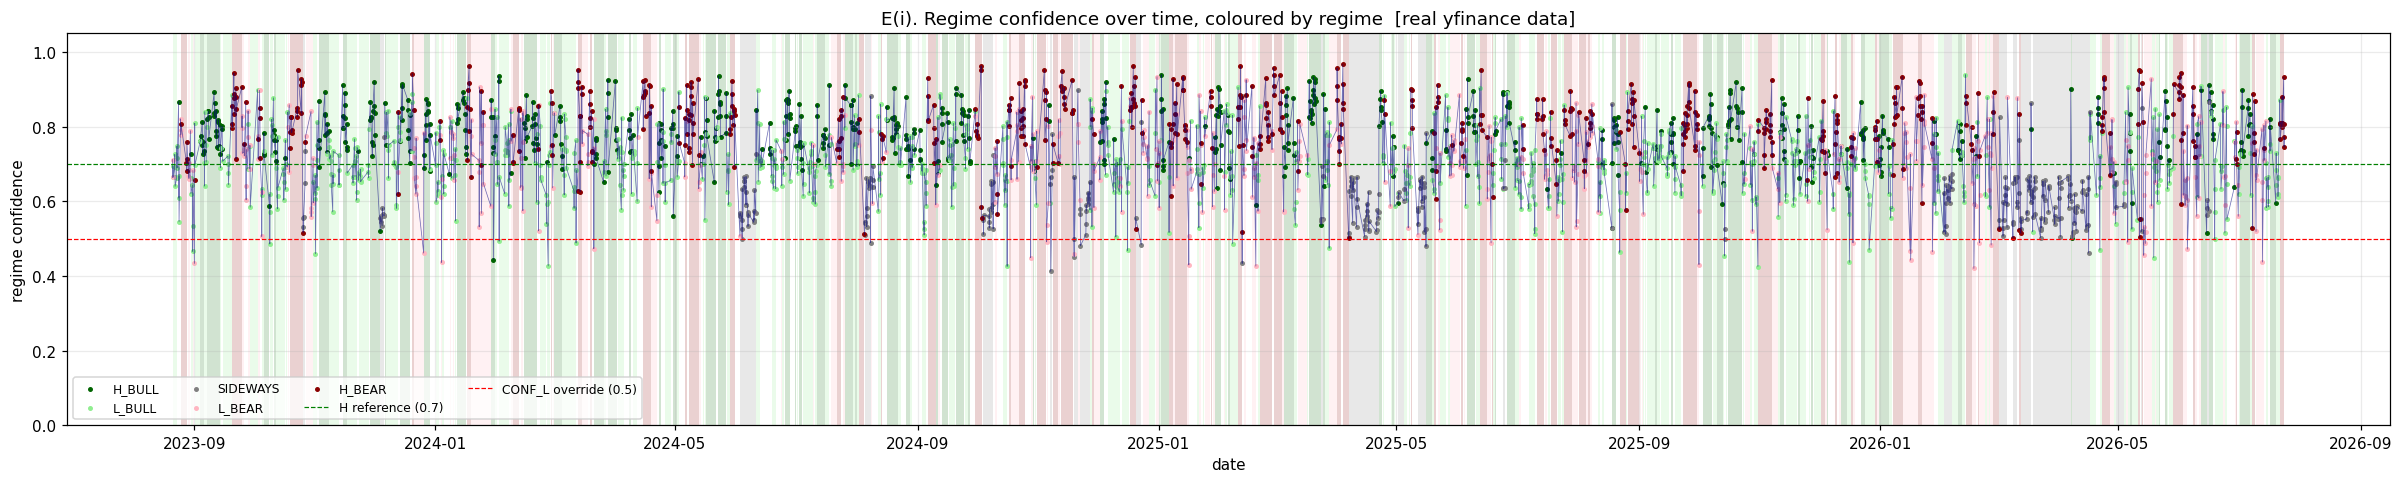

Bars below CONF_L (forced SIDEWAYS): 1.8%   median confidence: 0.734
TAC_SYNTH = False


In [27]:
fig, ax = plt.subplots(figsize=(22, 4.5))
shade_regimes(ax, reg['tactical_regime_state'], alpha=0.18)
for r in present:
    m = (lab == r)
    ax.scatter(reg.index[m], reg.loc[m, 'tactical_regime_confidence'],
               s=5, color=REGIME_COLORS[r], label=r)
ax.plot(reg.index, reg['tactical_regime_confidence'], color='navy', linewidth=0.5, alpha=0.55)
ax.axhline(CONFIDENCE_THRESHOLD_H, color='green', linestyle='--', linewidth=0.8,
           label=f'H reference ({CONFIDENCE_THRESHOLD_H})')
ax.axhline(CONFIDENCE_THRESHOLD_L, color='red', linestyle='--', linewidth=0.8,
           label=f'CONF_L override ({CONFIDENCE_THRESHOLD_L})')
ax.set_ylim(0, 1.05)
ax.set_ylabel('regime confidence')
ax.set_xlabel('date')
ax.set_title('E(i). Regime confidence over time, coloured by regime' + synth_tag(), fontsize=12)
ax.legend(loc='lower left', fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

below = 100 * (reg['tactical_regime_confidence'] < CONFIDENCE_THRESHOLD_L).mean()
print(f"Bars below CONF_L (forced SIDEWAYS): {below:.1f}%   "
      f"median confidence: {reg['tactical_regime_confidence'].median():.3f}")
print(f"TAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

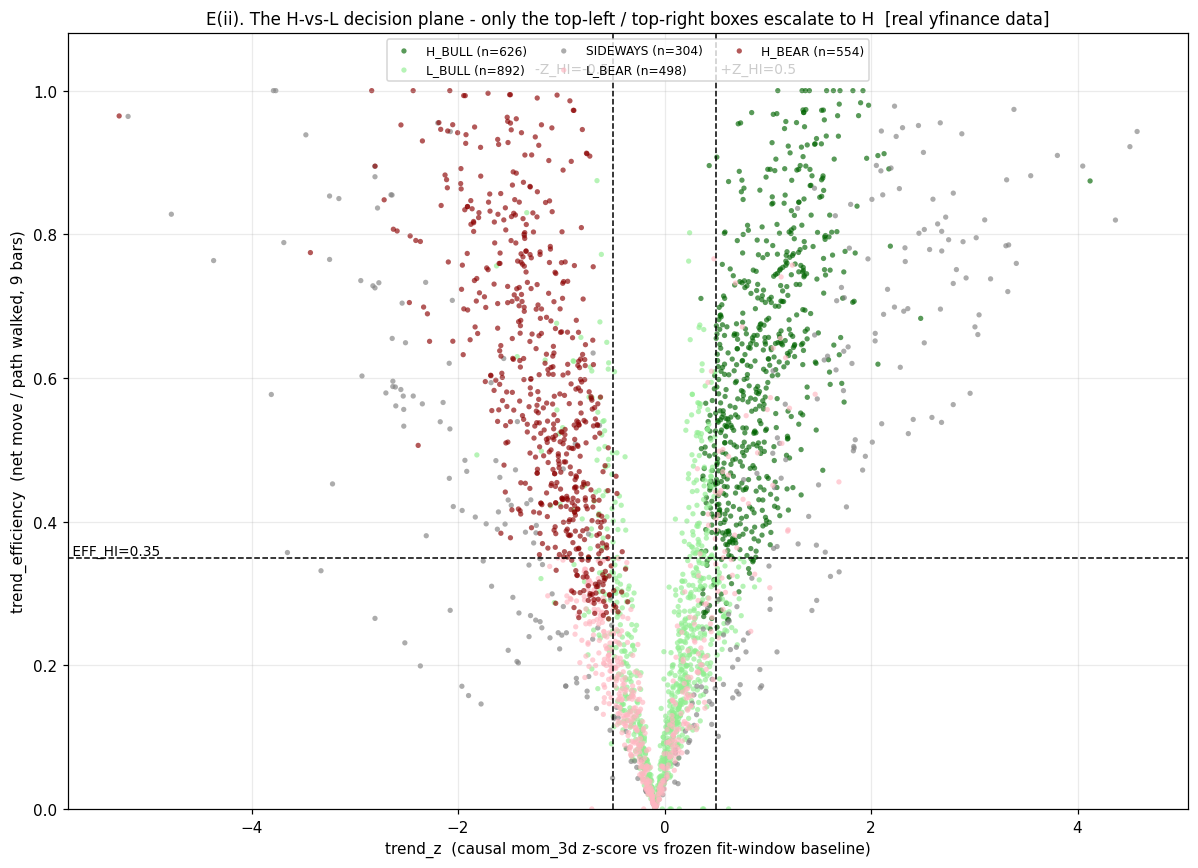

Bars passing BOTH gates on the bull side: 692
Bars with |z| >= 0.5 but efficiency < 0.35 (caught by the chop filter): 336  (11.7% of all bars)
TAC_SYNTH = False


In [28]:
fig, ax = plt.subplots(figsize=(11, 8))
for r in present:
    m = (lab == r)
    ax.scatter(reg.loc[m, 'trend_z'], reg.loc[m, 'trend_efficiency'],
               s=12, alpha=0.65, color=REGIME_COLORS[r], label=f'{r} (n={int(m.sum())})',
               edgecolors='none')
ax.axvline(Z_HI, color='black', linestyle='--', linewidth=1.0)
ax.axvline(-Z_HI, color='black', linestyle='--', linewidth=1.0)
ax.axhline(EFF_HI, color='black', linestyle='--', linewidth=1.0)
ax.text(Z_HI, 1.02, f' +Z_HI={Z_HI}', fontsize=9, va='bottom')
ax.text(-Z_HI, 1.02, f'-Z_HI={-Z_HI} ', fontsize=9, va='bottom', ha='right')
ax.text(ax.get_xlim()[0], EFF_HI, f' EFF_HI={EFF_HI}', fontsize=9, va='bottom')
ax.set_xlabel('trend_z  (causal mom_3d z-score vs frozen fit-window baseline)')
ax.set_ylabel(f'trend_efficiency  (net move / path walked, {EFF_WIN} bars)')
ax.set_ylim(0, 1.08)
ax.set_title('E(ii). The H-vs-L decision plane - only the top-left / top-right boxes escalate to H'
             + synth_tag(), fontsize=11)
ax.legend(loc='upper center', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

hi_zone_bull = ((reg['trend_z'] >= Z_HI) & (reg['trend_efficiency'] >= EFF_HI)).sum()
big_but_choppy = ((reg['trend_z'].abs() >= Z_HI) & (reg['trend_efficiency'] < EFF_HI)).sum()
print(f"Bars passing BOTH gates on the bull side: {hi_zone_bull}")
print(f"Bars with |z| >= {Z_HI} but efficiency < {EFF_HI} (caught by the chop filter): "
      f"{big_but_choppy}  ({100*big_but_choppy/len(reg):.1f}% of all bars)")
print(f"TAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

## 7F. Regime duration & transition structure

**(i) Run-length histograms.** How many consecutive bars a regime typically holds.
*What to look for:* a mass of 1-2 bar runs means the detector flickers, and a
swing system acting on it would churn. For 2-15 day swing trades you want
directional regimes surviving tens of bars (3 bars ≈ 1 day).

**(ii) Transition-count heatmap.** Where the detector goes when it changes
(diagonal excluded — these are regime *changes* only). *What to look for:*
transitions should mostly step through adjacent states
(`H_BULL -> L_BULL -> SIDEWAYS`). Frequent direct `H_BULL -> H_BEAR` jumps mean
the detector is snapping between extremes rather than tracking a progression.

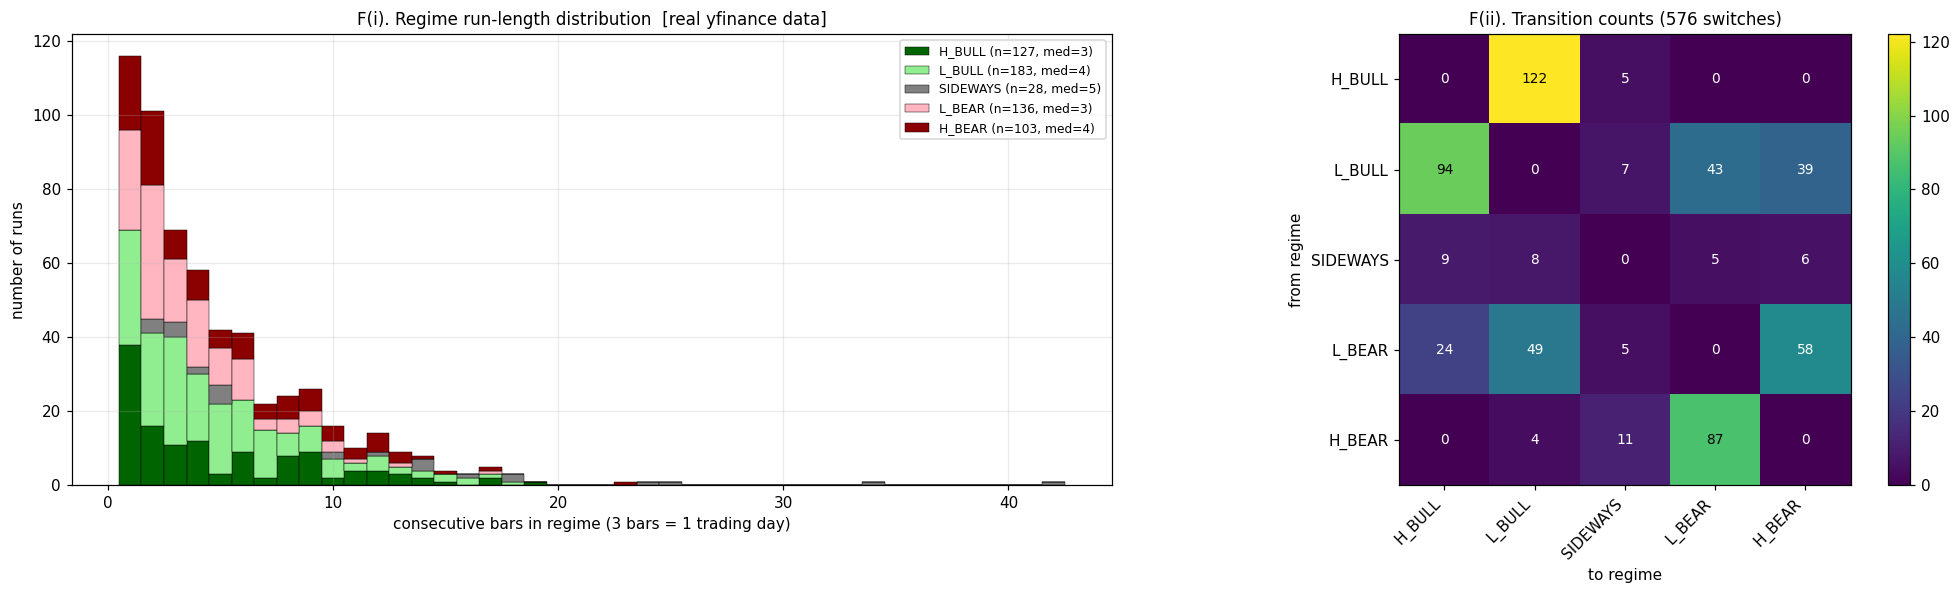

Median / mean run length (bars):
  H_BULL    median   3.0   mean   4.9   max   19   runs 127
  L_BULL    median   4.0   mean   4.9   max   18   runs 183
  SIDEWAYS  median   5.0   mean  10.9   max   42   runs 28
  L_BEAR    median   3.0   mean   3.7   max   17   runs 136
  H_BEAR    median   4.0   mean   5.4   max   23   runs 103

TAC_SYNTH = False


In [29]:
runs = {r: [] for r in REGIME_LABELS}
vals = reg['tactical_regime_state'].values
start = 0
for i in range(1, len(vals) + 1):
    if i == len(vals) or vals[i] != vals[i - 1]:
        runs[vals[start]].append(i - start)
        start = i

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), gridspec_kw={'width_ratios': [1.4, 1]})

axh = axes[0]
plot_labs = [r for r in REGIME_LABELS if len(runs[r]) > 0]
maxlen = max(max(runs[r]) for r in plot_labs)
bins = np.arange(0.5, min(maxlen, 60) + 1.5, 1)
axh.hist([runs[r] for r in plot_labs], bins=bins, stacked=True,
         color=[REGIME_COLORS[r] for r in plot_labs],
         label=[f'{r} (n={len(runs[r])}, med={int(np.median(runs[r]))})' for r in plot_labs],
         edgecolor='black', linewidth=0.3)
axh.set_xlabel('consecutive bars in regime (3 bars = 1 trading day)')
axh.set_ylabel('number of runs')
axh.set_title('F(i). Regime run-length distribution' + synth_tag(), fontsize=11)
axh.legend(fontsize=8)

trans = pd.DataFrame(0, index=REGIME_LABELS, columns=REGIME_LABELS)
for a, b in zip(vals[:-1], vals[1:]):
    if a != b:
        trans.loc[a, b] += 1
axt = axes[1]
im = axt.imshow(trans.values, cmap='viridis')
axt.set_xticks(range(len(REGIME_LABELS)))
axt.set_xticklabels(REGIME_LABELS, rotation=45, ha='right')
axt.set_yticks(range(len(REGIME_LABELS)))
axt.set_yticklabels(REGIME_LABELS)
axt.set_xlabel('to regime'); axt.set_ylabel('from regime')
for i in range(len(REGIME_LABELS)):
    for j in range(len(REGIME_LABELS)):
        v = trans.values[i, j]
        axt.text(j, i, int(v), ha='center', va='center',
                 color='white' if v < trans.values.max() * 0.6 else 'black', fontsize=9)
axt.set_title(f'F(ii). Transition counts ({int(trans.values.sum())} switches)', fontsize=11)
axt.grid(False)
fig.colorbar(im, ax=axt, fraction=0.046)
plt.tight_layout()
plt.show()

print('Median / mean run length (bars):')
for r in plot_labs:
    print(f'  {r:9s} median {np.median(runs[r]):5.1f}   mean {np.mean(runs[r]):5.1f}   '
          f'max {max(runs[r]):4d}   runs {len(runs[r])}')
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY" if TAC_SYNTH else ""))

## 7G. Equity-curve context — are the regimes actionable?

A deliberately naive rule: **long when the regime is `H_BULL` or `L_BULL`, flat
otherwise** — the same signal the walk-forward in Section 5 used, now over the
full series for visual context.

**No look-ahead:** the position on bar *t* is set by the regime observed at bar
*t-1* (`position = signal.shift(1)`), so the bar's own return is never used to
decide the trade. No costs, no slippage, no sizing — this is a *visual sanity
check*, not a backtest.

**What to look for:** the regime line should sidestep the worst drawdowns while
giving up some upside (that's the point of being flat). If it tracks buy-and-hold
almost exactly, the regimes are barely doing anything; if it loses money while the
market rises, the direction assignment is wrong.

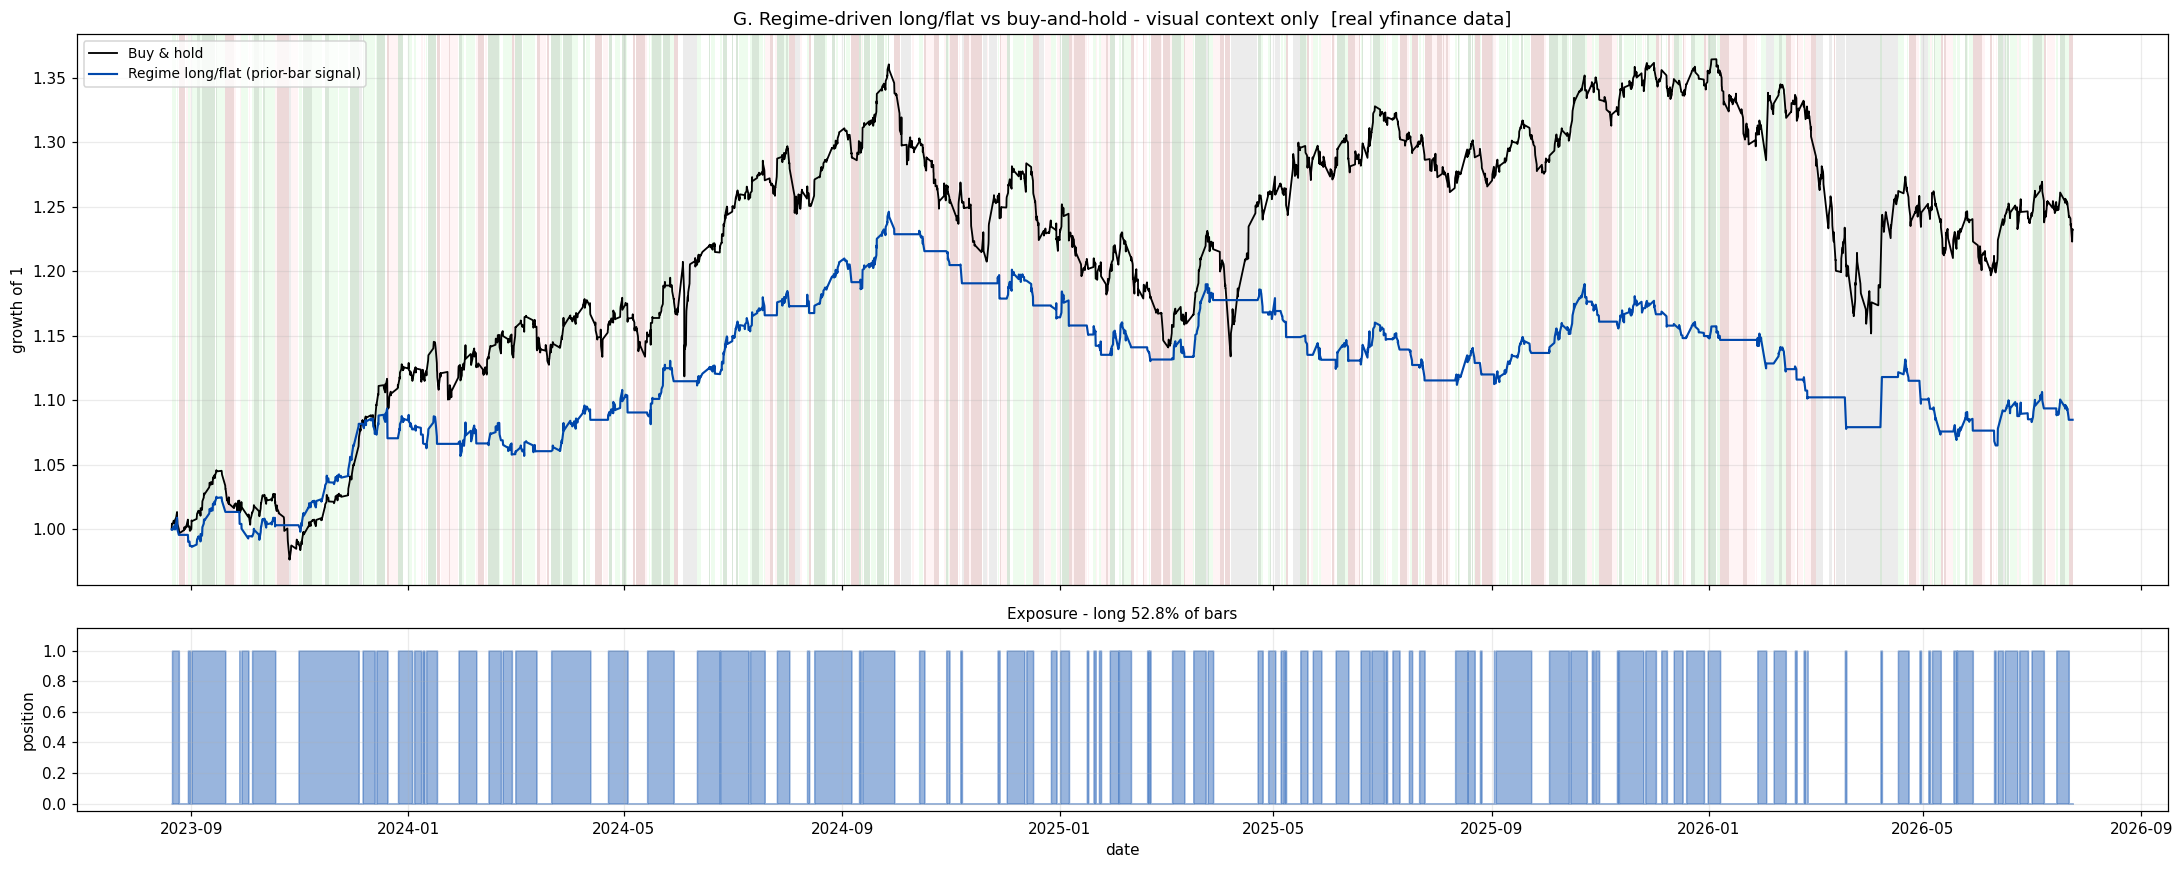

  Buy & hold           total +23.22%   CAGR  +5.65%   Sharpe  0.54   maxDD -16.64%
  Regime long/flat     total  +8.49%   CAGR  +2.17%   Sharpe  0.36   maxDD -14.54%
  Exposure: 52.8% of bars long

TAC_SYNTH = False


In [30]:
bar_ret = reg['nifty_close'].pct_change().fillna(0.0)
signal = lab.isin(['H_BULL', 'L_BULL']).astype(float)
position = signal.shift(1).fillna(0.0)        # act on the PRIOR bar's regime
strat_ret = position * bar_ret

bh_curve = (1 + bar_ret).cumprod()
rg_curve = (1 + strat_ret).cumprod()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
shade_regimes(ax1, reg['tactical_regime_state'], alpha=0.15)
ax1.plot(reg.index, bh_curve, color='black', linewidth=1.2, label='Buy & hold')
ax1.plot(reg.index, rg_curve, color='#0047AB', linewidth=1.4, label='Regime long/flat (prior-bar signal)')
ax1.set_ylabel('growth of 1')
ax1.set_title('G. Regime-driven long/flat vs buy-and-hold - visual context only'
              + synth_tag(), fontsize=12)
ax1.legend(loc='upper left', fontsize=9)

ax2.fill_between(reg.index, 0, position.values, step='pre', color='#0047AB', alpha=0.4)
ax2.set_ylim(-0.05, 1.15)
ax2.set_ylabel('position')
ax2.set_xlabel('date')
ax2.set_title(f'Exposure - long {100*position.mean():.1f}% of bars', fontsize=10)
plt.tight_layout()
plt.show()

ppy = 252 * BARS_PER_DAY


def _stats(r, c):
    yrs = len(r) / ppy
    cagr = c.iloc[-1] ** (1 / yrs) - 1 if yrs > 0 else np.nan
    sharpe = (r.mean() / r.std() * np.sqrt(ppy)) if r.std() > 0 else np.nan
    mdd = (c / c.cummax() - 1).min()
    return cagr, sharpe, mdd


for name, r, c in [('Buy & hold', bar_ret, bh_curve), ('Regime long/flat', strat_ret, rg_curve)]:
    cagr, sh, mdd = _stats(r, c)
    print(f'  {name:20s} total {c.iloc[-1]-1:+7.2%}   CAGR {cagr:+7.2%}   '
          f'Sharpe {sh:5.2f}   maxDD {mdd:7.2%}')
print(f'  Exposure: {100*position.mean():.1f}% of bars long')
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ("  -> ILLUSTRATIVE ONLY - this curve says nothing about live edge"
                                       if TAC_SYNTH else ""))

## 7H. The four labeling fixes — a 5-way A/B on the same fit, the same bars

Two concrete failures were reported off the **real-data** overlay:

1. **"After a big sweep, price rallies hard with high volatility, and it shows
   RED (`L_BEAR`). Unacceptable."** — confirmed in panel B3: a ~+10% rally shaded
   solid bear.
2. **"When price moves persistently in one direction with small swings, I want
   ONE regime, not many."** — confirmed in panel B4: a sustained decline shredded
   into alternating stripes. Real-data median run length was 2–4 bars (~1 day).
   The overlay reads as a barcode.

Three code-level causes, three switchable fixes:

| fix | cause | change | switch (old value) |
|-----|-------|--------|--------------------|
| **1. direction scorer** | `vol_2h` and `vol_expansion` are **magnitude** measures but carried sign `-1.0` in the *direction* score. The risk block (4.0 total) outweighed the directional block (3.2), so a violent rally scored bearish. | drop both from the bullishness score (weight 0). They **remain HMM input features** — they just stop voting on direction. `drawdown` and `vix_chg` keep their signs; both are defensibly signed. | `DIRECTION_EXCLUDE = ()` |
| **2. label hysteresis** | The emission log-likelihood gap swamps the transition log-odds, so despite learned diagonals of 0.87–0.97 the chain acts like a memoryless per-bar classifier. | a **causal confirmation delay**: a new direction must persist `CONFIRM_BARS` bars before the emitted label flips. | `CONFIRM_BARS = 1` |
| **3. gate hysteresis** | `Z_HI` / `EFF_HI` are hard thresholds re-tested every bar, so bars near a boundary flicker `H→L→H→L`. | enter/exit **bands**: escalate at `Z_HI`/`EFF_HI`, de-escalate only below `Z_HI_EXIT`/`EFF_HI_EXIT`. | `Z_HI_EXIT = Z_HI`, `EFF_HI_EXIT = EFF_HI` |
| **4. per-bar direction** | direction was a per-**state** property, but an HMM state is directionally **mixed** — volatility is direction-agnostic, so the "violent" state holds sharp selloffs *and* sharp rallies and hands both the same label. Fix 1 could only *remove* a wrong vote; nothing could *add* the right one. | blend the state masses with a **causal per-bar** directional score built from signed features only. | `BAR_DIR_WEIGHT = 0.0` |

Fix 2 is a **delay**, not a smoother. Bar *t*'s emitted label is a function of
bars `<= t` only: an unconfirmed flip is never emitted, a confirmed one is
emitted `CONFIRM_BARS - 1` bars late. That is the opposite of the look-ahead
smoother this project previously removed, which decided whether to erase a run
by inspecting the run's full *realized* length. Section 7.0's probe re-proves
causality **with hysteresis active** by deleting every bar after *t*.

**Fix 4 is the architectural one, and it is why arms (a)–(d) were not enough.**
On the real 2874-bar run, the 366 causal high-vol *rally* bars went
`46.2% bear → 11.2% bear` under fix 1 — but `bull` did not move at all
(`46.4% → 46.4%`); the red simply became **grey**. `SIDEWAYS` then carried the
**highest** forward return of any label (`+0.717%` at 15 bars vs `H_BULL`
`+0.026%`), which is the signature of a bullish bar population parked in the
"no opinion" bucket. That cannot be repaired by re-weighting a score that is
evaluated **once per state**; the attribution itself has to move to the bar.

All five arms below relabel **the same ensemble fit over the same bars** — no
refitting — so every difference is attributable to the labeling switch alone.
Section 7H-vi then sweeps `BAR_DIR_WEIGHT` over five values on that *same* fit,
against a criterion stated **before** the numbers are computed.

In [31]:
# Five cumulative labeling arms on ONE fit (emodels) and ONE bar set
# (eXs/edates). Only the labeling switches differ, so the deltas isolate each
# fix. Every arm names EVERY switch explicitly -- an arm that inherited a module
# default would silently stop being the arm it claims to be the next time a
# default moved.
AB_ARMS = [
    ('a. baseline',        dict(exclude=(),                confirm_bars=1,
                                z_exit=Z_HI,      eff_exit=EFF_HI,
                                bar_dir_weight=0.0)),
    ('b. +1 dir-scorer',   dict(exclude=DIRECTION_EXCLUDE, confirm_bars=1,
                                z_exit=Z_HI,      eff_exit=EFF_HI,
                                bar_dir_weight=0.0)),
    ('c. +1,2 confirm',    dict(exclude=DIRECTION_EXCLUDE, confirm_bars=CONFIRM_BARS,
                                z_exit=Z_HI,      eff_exit=EFF_HI,
                                bar_dir_weight=0.0)),
    ('d. +1,2,3 bands',    dict(exclude=DIRECTION_EXCLUDE, confirm_bars=CONFIRM_BARS,
                                z_exit=Z_HI_EXIT, eff_exit=EFF_HI_EXIT,
                                bar_dir_weight=0.0)),
    ('e. +1,2,3,4 bar-dir', dict(exclude=DIRECTION_EXCLUDE, confirm_bars=CONFIRM_BARS,
                                z_exit=Z_HI_EXIT, eff_exit=EFF_HI_EXIT,
                                bar_dir_weight=BAR_DIR_WEIGHT)),
]
AB_SHIPPED = 'e. +1,2,3,4 bar-dir'    # the arm using the module defaults
AB = {}
for _nm, _kw in AB_ARMS:
    AB[_nm] = label_bars(emodels, eXs, edates, nifty, edf[TREND_FEATURE].values,
                         n_fit, eval_feat, dir_feats=edf,
                         **_kw)['tactical_regime_state']

# Arm (e) restates exactly the module defaults, so it MUST be bit-identical to
# the labels Sections 7A-7G were drawn from. If this ever fails, the A/B is
# measuring something other than what the notebook shipped.
assert (AB[AB_SHIPPED].values == lab.values).all(), \
    'the shipped arm must reproduce the notebook-wide labels exactly'
# And BAR_DIR_WEIGHT = 0.0 must be a BIT-FOR-BIT no-op, not merely "close": the
# arm (d) labels are re-derived with dir_feats supplied but weight 0, and with
# dir_feats withheld entirely, and all three must agree exactly. This is the
# claim that FIX 4 is a pure addition with an off switch.
_d_nodir = label_bars(emodels, eXs, edates, nifty, edf[TREND_FEATURE].values,
                      n_fit, eval_feat, exclude=DIRECTION_EXCLUDE,
                      confirm_bars=CONFIRM_BARS, z_exit=Z_HI_EXIT,
                      eff_exit=EFF_HI_EXIT, bar_dir_weight=0.0)   # dir_feats=None
assert (_d_nodir['tactical_regime_state'].values == AB['d. +1,2,3 bands'].values).all(), \
    'BAR_DIR_WEIGHT=0 with dir_feats supplied must equal the no-dir_feats path'
_d_masses = label_bars(emodels, eXs, edates, nifty, edf[TREND_FEATURE].values,
                       n_fit, eval_feat, exclude=DIRECTION_EXCLUDE,
                       confirm_bars=CONFIRM_BARS, z_exit=Z_HI_EXIT,
                       eff_exit=EFF_HI_EXIT, dir_feats=edf, bar_dir_weight=0.0)
_pc4 = ['prob_H_BULL', 'prob_L_BULL', 'prob_SIDEWAYS', 'prob_L_BEAR', 'prob_H_BEAR']
assert np.array_equal(_d_masses[_pc4].values, _d_nodir[_pc4].values), \
    'BAR_DIR_WEIGHT=0 must leave the prob_* masses BIT-identical, not just close'
assert np.array_equal(_d_masses['tactical_regime_confidence'].values,
                      _d_nodir['tactical_regime_confidence'].values), \
    'BAR_DIR_WEIGHT=0 must leave tactical_regime_confidence BIT-identical'
print(f'FIX 4 OFF-SWITCH OK: BAR_DIR_WEIGHT=0.0 reproduces the pre-fix labels, '
      f'prob_* masses and confidence BIT-for-BIT ({len(edates)} bars, exact equality).')
print()
# And with every switch at its OLD value, arm (a) must reproduce PRE-FIX
# behaviour -- re-derived here from first principles rather than trusted.
# FIX 1 BITES only if muting the two magnitude terms actually RE-RANKS states --
# the direction buckets are rank-based, so a score can move a lot without any
# bucket changing. Report this per ensemble member, and report the SCORES too,
# so a no-op is distinguishable from a fix that fired and did not help.
print('FIX 1 -- effect of muting vol_2h / vol_expansion in the DIRECTION score')
print('(buckets: bear=-1, side=0, bull=+1; scores are the composite bullishness '
      'of each state mean)')
FIX1_REBUCKETED = 0
for _mi, _mm in enumerate(emodels):
    _s_old = composite_subset(_mm.means_, eval_feat, exclude=())
    _s_new = composite_subset(_mm.means_, eval_feat, exclude=DIRECTION_EXCLUDE)
    _d_old = direction_buckets(_mm.means_, eval_feat, exclude=())
    _d_new = direction_buckets(_mm.means_, eval_feat, exclude=DIRECTION_EXCLUDE)
    _nchg = int((_d_old != _d_new).sum())
    FIX1_REBUCKETED += _nchg
    print(f'  member {_mi} (seed {ensemble_seeds()[_mi]}):')
    print(f'    score  old {np.round(_s_old, 3).tolist()}')
    print(f'    score  new {np.round(_s_new, 3).tolist()}   '
          f'(vol terms contributed {np.round(_s_old - _s_new, 3).tolist()})')
    print(f'    bucket old {_d_old.tolist()}   new {_d_new.tolist()}   '
          f'-> {_nchg}/{len(_d_old)} states re-bucketed')
FIX1_ACTIVE = FIX1_REBUCKETED > 0
print(f'  TOTAL states re-bucketed across the K={len(emodels)} ensemble members: '
      f'{FIX1_REBUCKETED}')
if not FIX1_ACTIVE:
    print('  => FIX 1 IS A NO-OP ON THIS DATA. Muting the vol terms shifted every '
          'state score,')
    print('     but not enough to change any state RANK, so the direction buckets -- '
          'and therefore')
    print('     every label -- are identical to baseline. Arms (a) and (b) below will '
          'match exactly.')
    print('     This does NOT mean fix 1 failed; it means this series cannot test it. '
          'The real-data')
    print('     run is where the complaint was observed and is where this must be '
          're-measured.')
print()


def run_lengths(vals):
    '''[(label, length_in_bars), ...] for contiguous runs. Positional, not dated.'''
    v = np.asarray(vals)
    ch = np.flatnonzero(v[1:] != v[:-1]) + 1
    st = np.concatenate(([0], ch))
    en = np.concatenate((ch, [len(v)]))
    return [(v[a], int(b - a)) for a, b in zip(st, en)]


def arm_table(series):
    '''Per-label occupancy + run-length stats, plus an ALL row.'''
    rl = run_lengths(series.values)
    rows = []
    for r in REGIME_LABELS:
        n = int((series == r).sum())
        ln = [L for lb, L in rl if lb == r]
        rows.append({'regime': r, 'bars': n, 'occupancy_%': 100 * n / len(series),
                     'runs': len(ln),
                     'median_run': float(np.median(ln)) if ln else np.nan,
                     'mean_run': float(np.mean(ln)) if ln else np.nan})
    allln = [L for _, L in rl]
    rows.append({'regime': 'ALL', 'bars': len(series), 'occupancy_%': 100.0,
                 'runs': len(allln), 'median_run': float(np.median(allln)),
                 'mean_run': float(np.mean(allln))})
    return pd.DataFrame(rows).set_index('regime')


print('=' * 100)
print('7H-i. RUN LENGTH / OCCUPANCY BY ARM' + synth_tag())
print('=' * 100)
AB_TBL = {}
for _nm, _ in AB_ARMS:
    AB_TBL[_nm] = arm_table(AB[_nm])
    print(f'\n--- {_nm} ---')
    print(AB_TBL[_nm].round(2).to_string())

print('\n' + '=' * 100)
print('7H-ii. SIDE BY SIDE: total runs and median/mean run length (bars; 3 bars ~ 1 day)')
print('=' * 100)
_side = pd.DataFrame({
    _nm: {'total runs': AB_TBL[_nm].loc['ALL', 'runs'],
          'median run (all)': AB_TBL[_nm].loc['ALL', 'median_run'],
          'mean run (all)': AB_TBL[_nm].loc['ALL', 'mean_run'],
          **{f'median run {r}': AB_TBL[_nm].loc[r, 'median_run'] for r in REGIME_LABELS},
          **{f'occupancy_% {r}': AB_TBL[_nm].loc[r, 'occupancy_%'] for r in REGIME_LABELS}}
    for _nm, _ in AB_ARMS})
print(_side.round(2).to_string())

print('\n' + '=' * 100)
print('7H-iii. FORWARD-RETURN BY REGIME, PER ARM (%, evaluation-only hindsight)')
print('=' * 100)
AB_FWD = {}
for _nm, _ in AB_ARMS:
    _l = AB[_nm]
    AB_FWD[_nm] = pd.DataFrame(
        {f'fwd_{h}': {r: 100 * fwd[f'fwd_{h}'][_l == r].mean() for r in REGIME_LABELS}
         for h in FWD_HORIZONS}).reindex(REGIME_LABELS)
    _seq = [AB_FWD[_nm].loc[r, f'fwd_{FWD_HORIZONS[-1]}'] for r in REGIME_LABELS]
    _seq = [v for v in _seq if v == v]
    _mono = all(_seq[i] >= _seq[i + 1] for i in range(len(_seq) - 1))
    _bull = 100 * fwd[f'fwd_{FWD_HORIZONS[-1]}'][_l.isin(['H_BULL', 'L_BULL'])].mean()
    _side_ = 100 * fwd[f'fwd_{FWD_HORIZONS[-1]}'][_l == 'SIDEWAYS'].mean()
    _bear = 100 * fwd[f'fwd_{FWD_HORIZONS[-1]}'][_l.isin(['H_BEAR', 'L_BEAR'])].mean()
    print(f'\n--- {_nm} ---')
    print(AB_FWD[_nm].round(3).to_string())
    print(f'    strict 5-label ordering at fwd_{FWD_HORIZONS[-1]}: '
          f"{'HOLDS' if _mono else 'BROKEN'}   |   direction-level: "
          f'BULL {_bull:+.3f}%  SIDEWAYS {_side_:+.3f}%  BEAR {_bear:+.3f}%  -> '
          f"{'HOLDS' if _bull >= _side_ >= _bear else 'BROKEN'}")
print(f"\nTAC_SYNTH = {TAC_SYNTH}" + ('  -> ILLUSTRATIVE ONLY' if TAC_SYNTH else ''))

FIX 4 OFF-SWITCH OK: BAR_DIR_WEIGHT=0.0 reproduces the pre-fix labels, prob_* masses and confidence BIT-for-BIT (2874 bars, exact equality).

FIX 1 -- effect of muting vol_2h / vol_expansion in the DIRECTION score
(buckets: bear=-1, side=0, bull=+1; scores are the composite bullishness of each state mean)
  member 0 (seed 42):
    score  old [1.238, -2.233, -4.83, -1.557, 3.371]
    score  new [0.756, 0.095, -4.422, -1.631, 2.972]   (vol terms contributed [0.482, -2.328, -0.408, 0.074, 0.399])
    bucket old [1, -1, -1, 0, 1]   new [1, 0, -1, -1, 1]   -> 2/5 states re-bucketed
  member 1 (seed 43):
    score  old [-1.557, 1.238, -2.233, -4.83, 3.371]
    score  new [-1.631, 0.756, 0.095, -4.422, 2.972]   (vol terms contributed [0.074, 0.482, -2.328, -0.408, 0.399])
    bucket old [0, 1, -1, -1, 1]   new [-1, 1, 0, -1, 1]   -> 2/5 states re-bucketed
  member 2 (seed 44):
    score  old [-4.831, 1.239, -1.556, 3.371, -2.233]
    score  new [-4.422, 0.757, -1.631, 2.973, 0.095]   (vol ter

### 7H-iv. Before / after overlay — the barcode test

Same price series, same fit, same bars; only the labeling switches differ. The
top panel is the **baseline** labeling, the bottom is **all three fixes**. Below
that, the same pair zoomed on the single strongest sustained directional move in
the data — located *programmatically* as the 40-bar window with the highest
trailing Kaufman trend efficiency, i.e. the stretch that walks the straightest
line. That window is where complaint 2 (one persistent move should be one
regime, not many) is most visible, and it is chosen by the data rather than by
eye.

Zoom window (highest 40-bar trend efficiency = 0.705): 2023-11-23 -> 2023-12-08   move +5.85%


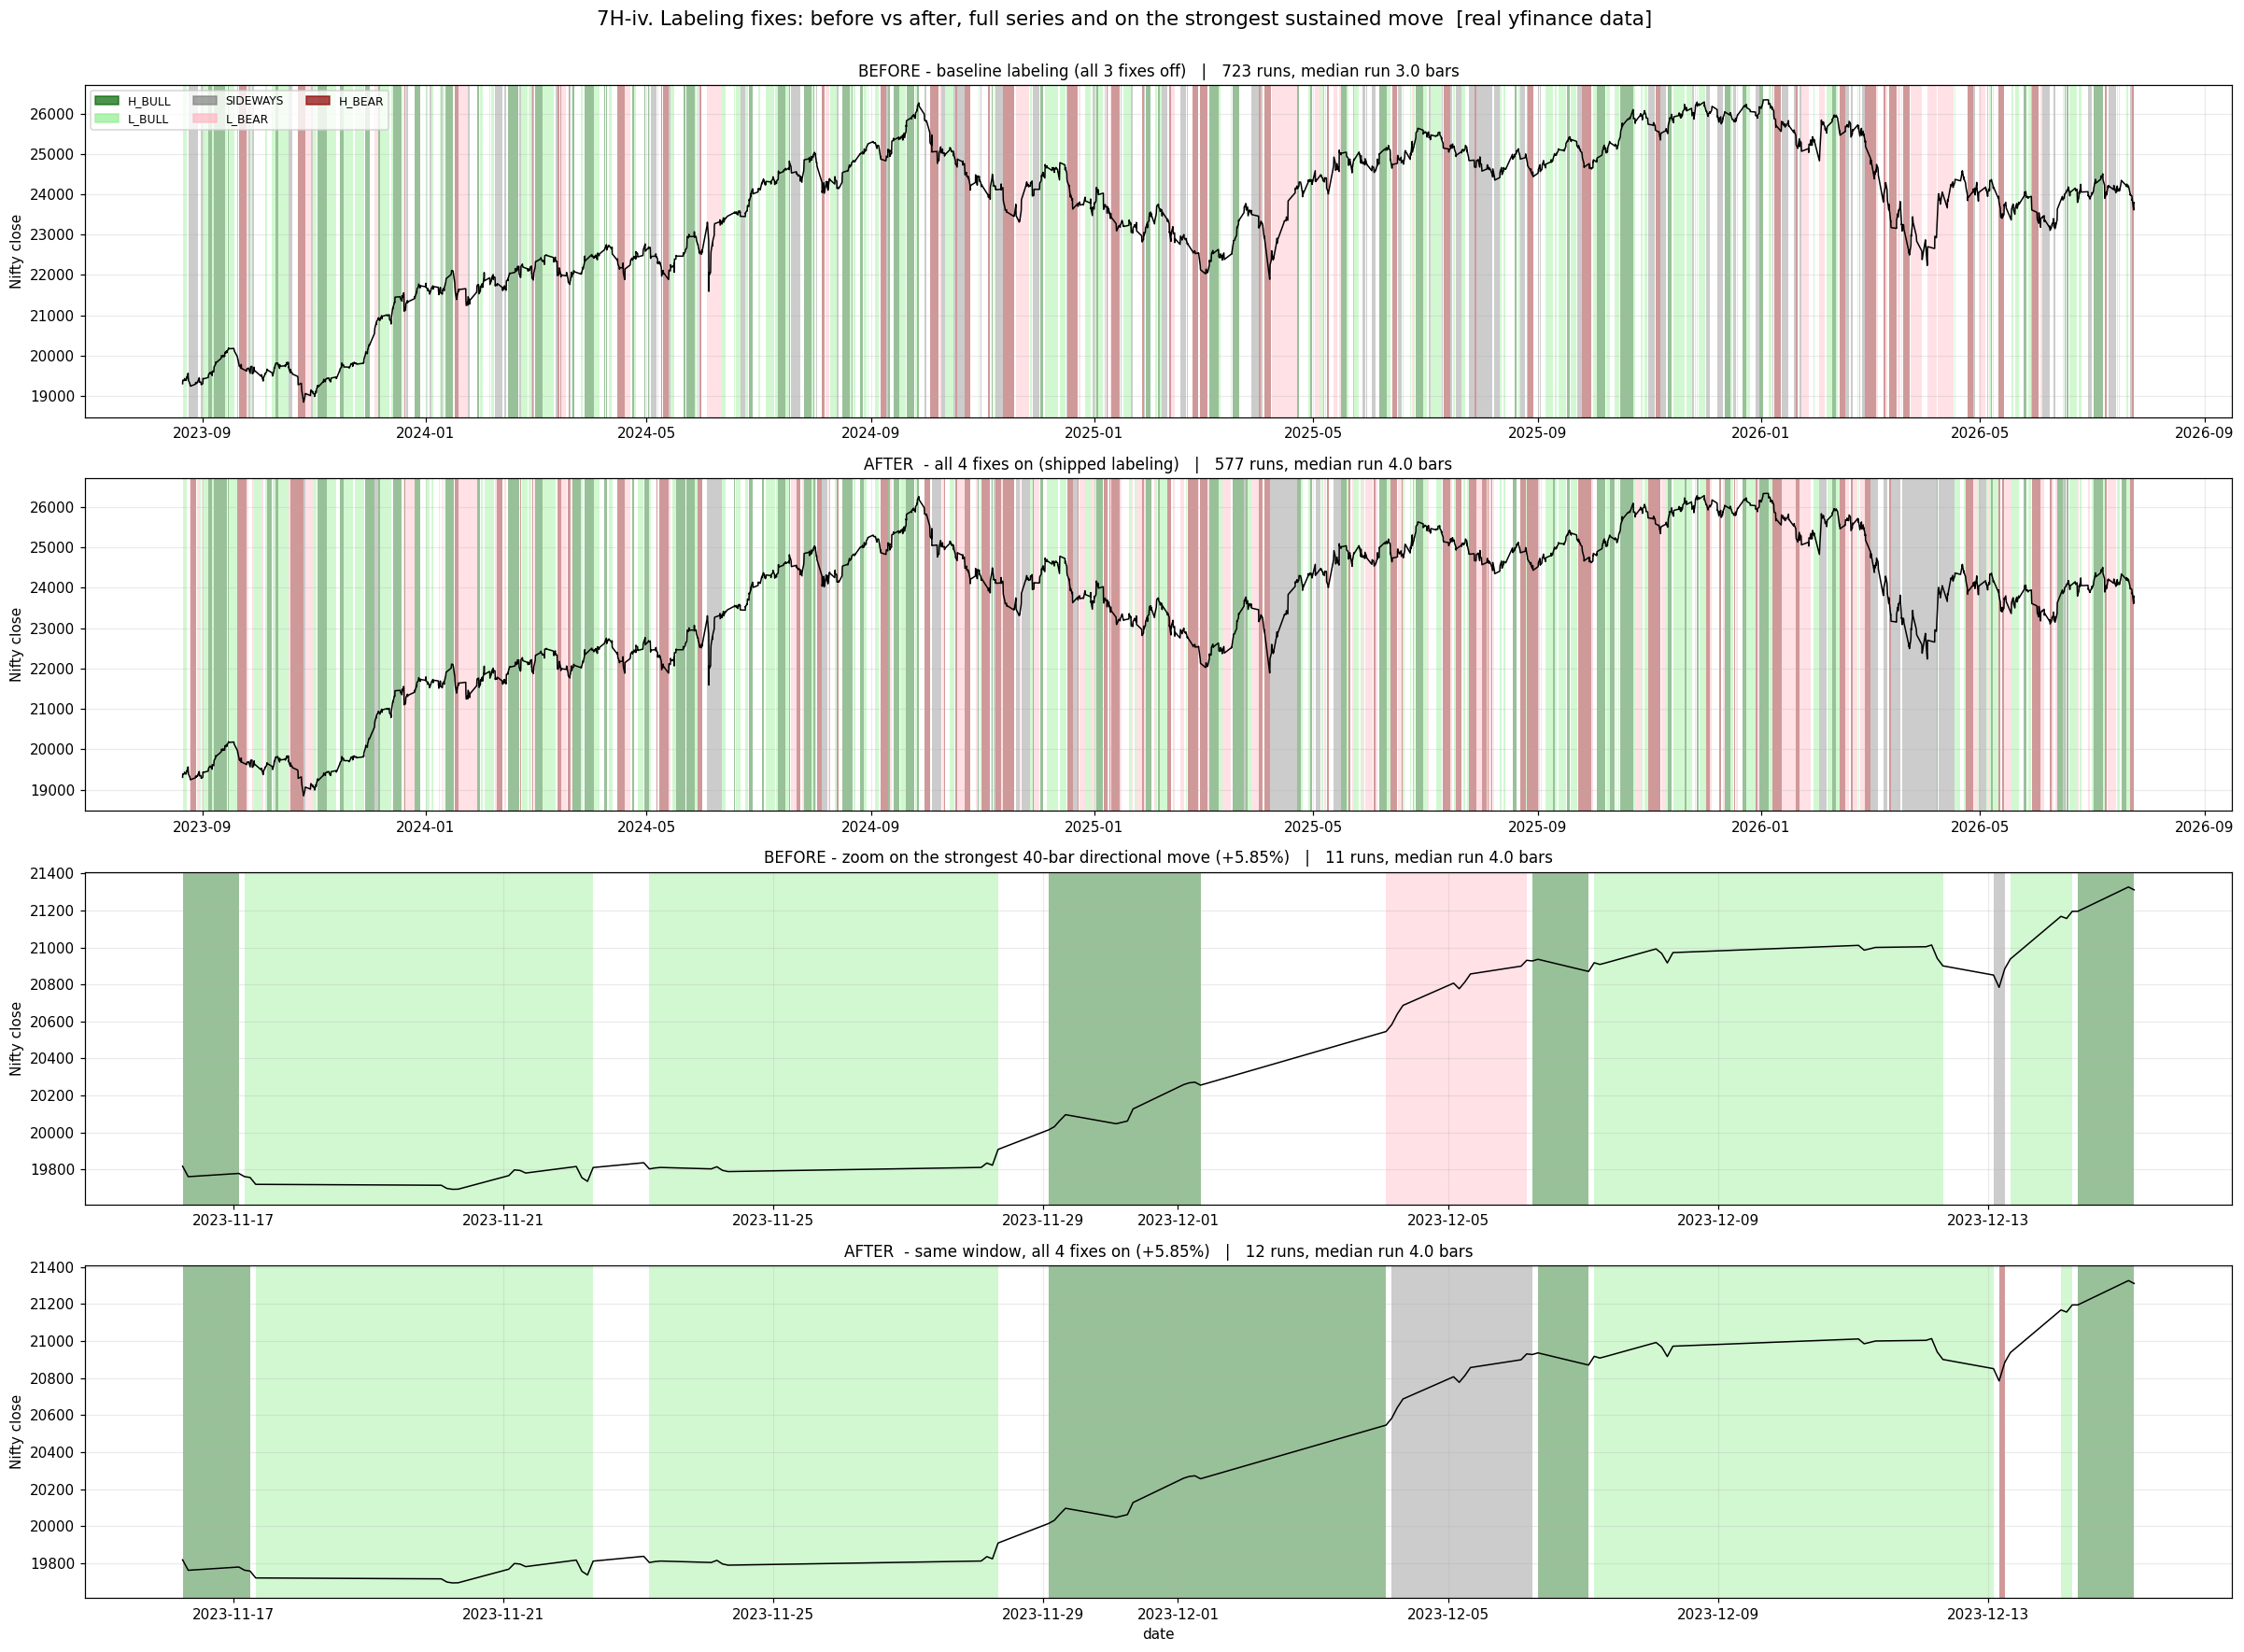

TAC_SYNTH = False


In [32]:
_base_lab = AB['a. baseline']
_fix_lab = AB[AB_SHIPPED]
_px = reg['nifty_close']

# Locate the strongest sustained directional move PROGRAMMATICALLY: the 40-bar
# window with the highest causal trend efficiency (|net move| / |path walked|).
ZOOM_WIN = 40
_we = trend_efficiency(_px, ZOOM_WIN)
_wl = _we.iloc[ZOOM_WIN:]                       # drop the warm-up
_zend = int(_px.index.get_loc(_wl.idxmax()))
_z0 = max(0, _zend - ZOOM_WIN + 1)
_z1 = min(len(_px), _zend + 1)
_pad = ZOOM_WIN // 2                            # a little context either side
_z0p, _z1p = max(0, _z0 - _pad), min(len(_px), _z1 + _pad)
_zsl = slice(_z0p, _z1p)
_zmove = 100 * (_px.iloc[_z1 - 1] / _px.iloc[_z0] - 1.0)
print(f'Zoom window (highest {ZOOM_WIN}-bar trend efficiency = {_wl.max():.3f}): '
      f'{_px.index[_z0]:%Y-%m-%d} -> {_px.index[_z1-1]:%Y-%m-%d}   move {_zmove:+.2f}%')

fig, axes = plt.subplots(4, 1, figsize=(22, 16))
for ax, (_ttl, _lb, _sl) in zip(axes, [
        ('BEFORE - baseline labeling (all 3 fixes off)', _base_lab, slice(None)),
        ('AFTER  - all 4 fixes on (shipped labeling)', _fix_lab, slice(None)),
        (f'BEFORE - zoom on the strongest {ZOOM_WIN}-bar directional move ({_zmove:+.2f}%)',
         _base_lab, _zsl),
        (f'AFTER  - same window, all 4 fixes on ({_zmove:+.2f}%)', _fix_lab, _zsl)]):
    _s = _lb.iloc[_sl]
    shade_regimes(ax, _s, alpha=0.40)
    ax.plot(_px.iloc[_sl].index, _px.iloc[_sl].values, color='black', linewidth=1.0)
    _rl = run_lengths(_s.values)
    ax.set_title(f'{_ttl}   |   {len(_rl)} runs, median run '
                 f'{np.median([L for _, L in _rl]):.1f} bars', fontsize=11)
    ax.set_ylabel('Nifty close')
    if ax is axes[0]:
        regime_legend(ax)
axes[-1].set_xlabel('date')
fig.suptitle('7H-iv. Labeling fixes: before vs after, full series and on the '
             'strongest sustained move' + synth_tag(), fontsize=14, y=1.002)
plt.tight_layout()
plt.show()
print(f"TAC_SYNTH = {TAC_SYNTH}" + ('  -> ILLUSTRATIVE ONLY' if TAC_SYNTH else ''))

### 7H-v. Honest verdict, one per complaint

Two numbers decide this, and both are printed rather than asserted so a failure
is visible instead of fatal:

* **Complaint 2 (barcode).** Did the median run length rise *materially*? The bar
  is set at **+50% and a median of at least 3 bars (~1 day)** — below that the
  overlay is still switching roughly daily and the complaint stands.
* **Complaint 1 (red rallies).** Measured directly, without hindsight: take bars
  in the **top `vol_2h` quartile** that also had **positive trailing `mom_3d`** —
  i.e. high-volatility bars that were rallying *on information available at the
  bar* — and report what fraction were labeled bear **before** vs **after** fix 1.
  `mom_3d` is a trailing sum of log returns, so this selection is causal and no
  forward return enters it.

In [33]:
print('=' * 100)
print('7H-v. VERDICTS' + synth_tag())
print('=' * 100)

# ---- COMPLAINT 2: persistence -------------------------------------------
_m_base = AB_TBL['a. baseline'].loc['ALL', 'median_run']
_m_fix = AB_TBL[AB_SHIPPED].loc['ALL', 'median_run']
_r_base = int(AB_TBL['a. baseline'].loc['ALL', 'runs'])
_r_fix = int(AB_TBL[AB_SHIPPED].loc['ALL', 'runs'])
_gain = 100 * (_m_fix / _m_base - 1.0) if _m_base else np.nan
_pass2 = (_m_fix >= 3.0) and (_gain >= 50.0)
print('\nCOMPLAINT 2 -- "one persistent move should be ONE regime, not many"')
print(f'  median run length : {_m_base:.1f} bars  ->  {_m_fix:.1f} bars   ({_gain:+.0f}%)')
print(f'  mean   run length : {AB_TBL["a. baseline"].loc["ALL","mean_run"]:.1f}  ->  '
      f'{AB_TBL[AB_SHIPPED].loc["ALL","mean_run"]:.1f} bars')
print(f'  total runs        : {_r_base}  ->  {_r_fix}   '
      f'({100*(_r_fix/_r_base-1):+.0f}%)')
print(f'  attribution       : fix2 alone (arm c) median '
      f'{AB_TBL["c. +1,2 confirm"].loc["ALL","median_run"]:.1f}, '
      f'fix1 alone (arm b) median {AB_TBL["b. +1 dir-scorer"].loc["ALL","median_run"]:.1f}')
print(f'  VERDICT           : {"MATERIALLY IMPROVED" if _pass2 else "NOT MATERIALLY FIXED"}'
      f'   (bar: median >= 3 bars AND >= +50%)')

# ---- COMPLAINT 1: high-vol rallies labeled bear -------------------------
# CAUSAL selection: trailing vol_2h in the top quartile, trailing mom_3d > 0.
# Nothing forward-looking enters this mask.
_vol = reg['vol_2h']
_mom = reg['mom_3d']
_q75 = _vol.quantile(0.75)
_rally = (_vol >= _q75) & (_mom > 0)
_n_rally = int(_rally.sum())
_BEARS = ['L_BEAR', 'H_BEAR']
_BULLS = ['H_BULL', 'L_BULL']
print('\nCOMPLAINT 1 -- "high-volatility rally shows RED"')
print(f'  selection (causal): vol_2h >= 75th pct ({_q75:.5f}) AND trailing mom_3d > 0'
      f'  ->  {_n_rally} bars ({100*_n_rally/len(reg):.1f}% of the series)')
if _n_rally == 0:
    print('  no qualifying bars on this run -> UNMEASURABLE HERE')
    _pass1 = False
else:
    _rows = []
    for _nm, _ in AB_ARMS:
        _l = AB[_nm][_rally]
        _rows.append({'arm': _nm,
                      'bear_%': 100 * _l.isin(_BEARS).mean(),
                      'sideways_%': 100 * (_l == 'SIDEWAYS').mean(),
                      'bull_%': 100 * _l.isin(_BULLS).mean()})
    _rt = pd.DataFrame(_rows).set_index('arm')
    print()
    print(_rt.round(1).to_string())
    _b0 = _rt.loc['a. baseline', 'bear_%']
    _b1 = _rt.loc['b. +1 dir-scorer', 'bear_%']
    _u0 = _rt.loc['a. baseline', 'bull_%']
    _u1 = _rt.loc['b. +1 dir-scorer', 'bull_%']
    _pass1 = (_b1 < _b0) and (_u1 > _u0)
    print(f'\n  fix 1 effect on these high-vol RALLY bars:'
          f'  bear {_b0:.1f}% -> {_b1:.1f}% ({_b1-_b0:+.1f} pp),'
          f'  bull {_u0:.1f}% -> {_u1:.1f}% ({_u1-_u0:+.1f} pp)')
    if not FIX1_ACTIVE:
        print('  VERDICT           : UNTESTABLE ON THIS SERIES -- fix 1 re-bucketed 0 '
              'states, so arms (a)')
        print('                      and (b) are identical BY CONSTRUCTION and the '
              '0.0 pp delta above is')
        print('                      a tautology, not evidence. The scorer change is '
              'live and correct')
        print('                      (see the score table at the top of 7H); it simply '
              'does not bind on')
        print('                      this data. RE-MEASURE ON THE REAL SERIES, where '
              'the complaint arose.')
    else:
        print(f'  VERDICT           : '
              f'{"FIXED - high-vol rallies moved bear -> bull" if _pass1 else "NOT FIXED - fix 1 re-bucketed states but did not move these bars the right way"}')

print('\n' + '-' * 100)
print('SCOPE: ' + ('these numbers are from the SYNTHETIC fallback series and are '
                   'ILLUSTRATIVE ONLY.\n       The synthetic generator is not the '
                   'market that produced the complaints; the real-data\n       Kaggle '
                   'run is what decides whether either complaint is actually resolved.'
                   if TAC_SYNTH else 'real yfinance data.'))
print('-' * 100)

7H-v. VERDICTS  [real yfinance data]

COMPLAINT 2 -- "one persistent move should be ONE regime, not many"
  median run length : 3.0 bars  ->  4.0 bars   (+33%)
  mean   run length : 4.0  ->  5.0 bars
  total runs        : 723  ->  577   (-20%)
  attribution       : fix2 alone (arm c) median 3.0, fix1 alone (arm b) median 2.0
  VERDICT           : NOT MATERIALLY FIXED   (bar: median >= 3 bars AND >= +50%)

COMPLAINT 1 -- "high-volatility rally shows RED"
  selection (causal): vol_2h >= 75th pct (0.00405) AND trailing mom_3d > 0  ->  366 bars (12.7% of the series)

                     bear_%  sideways_%  bull_%
arm                                            
a. baseline            46.2         7.4    46.4
b. +1 dir-scorer       11.2        42.3    46.4
c. +1,2 confirm        16.1        40.7    43.2
d. +1,2,3 bands        16.1        40.7    43.2
e. +1,2,3,4 bar-dir    16.4        40.7    42.9

  fix 1 effect on these high-vol RALLY bars:  bear 46.2% -> 11.2% (-35.0 pp),  bull 46.4% -> 

### 7H-vi. FIX 4 — the `BAR_DIR_WEIGHT` sweep, with the pass criterion stated first

**What is being tested.** Direction stops being decided once per HMM *state* and
starts being decided per *bar*. The per-bar score uses **only signed directional
features** — `ret_2h`, `mom_1d`, `mom_3d`, `mom_5d`, `dist_ma`, with the existing
`FEATURE_SIGN`/`FEATURE_MAG` weights — each standardized against a `mu`/`sd`
baseline **frozen on the fit window**, exactly the way `trend_z` is. `vol_2h` and
`vol_expansion` are barred *structurally* (asserted in `bar_direction_score`),
because magnitude cannot vote on direction. Nothing at bar *t* reads a bar after
*t*; 7.0's probe re-proves that with the blend live.

`BAR_DIR_WEIGHT` blends the two mass vectors,
`(1-w)·state + w·bar`. `w = 0` is the pre-fix behaviour bit-for-bit (asserted
above); `w = 1` decides direction purely per bar, with the HMM still supplying
market character, persistence and the confidence signal. All five arms **reuse
the one ensemble fit** — no refitting, so the sweep isolates the blend.

---

#### FALSIFIABLE CRITERION — fixed here, before the numbers below are computed

The fix **WORKS** if and only if **both** hold at the default `BAR_DIR_WEIGHT`:

1. on the causal high-volatility **rally** bars (top `vol_2h` quartile **and**
   trailing `mom_3d > 0`), `bull%` rises by **>= 15 percentage points** versus
   `BAR_DIR_WEIGHT = 0`; **and**
2. `SIDEWAYS` mean `fwd_15` falls **below** `H_BULL`'s.

Criterion 1 is the diagnosis restated as a prediction: under fix 1 alone those
bars went red → **grey**, so the fix is only real if grey now becomes **green**.
Criterion 2 is the independent check that the move was *correct* and not merely
*different* — if those bars really are bullish, taking them out of `SIDEWAYS`
must strip `SIDEWAYS` of the forward return it was borrowing from them.

**Read the sweep with this interaction in mind.** `tactical_regime_confidence`
is the winning mass, and `CONF_L` forces `SIDEWAYS` below it. The per-bar
softmax is *bounded*: at `tau = 1.0` the leading direction only clears `0.5`
once `|z| >~ 0.5`. So as `w → 1` the HMM's often-very-confident state masses are
progressively replaced by a more temperate per-bar signal, `CONF_L` bites on
more bars, and `SIDEWAYS` occupancy **rises** for a reason that has nothing to
do with direction being wrong. `w = 1.0` is therefore an endpoint of the sweep,
not a recommendation, and `CONF_L`/`tau` have deliberately **not** been retuned
to flatter it — retuning them against this criterion is exactly the move that
would make the measurement worthless.

**A FAIL is a valid result and is printed as one.** No parameter below is tuned
against this criterion, and the criterion is not revised after seeing the
numbers. Two supporting tables are printed alongside precisely so a "pass" that
came at an unacceptable cost is visible: **run-length / total runs** per arm (the
persistence gains from fixes 2 and 3 must not be destroyed) and
**direction-level forward-return monotonicity** `BULL > SIDEWAYS > BEAR`.

In [34]:
# ---------------------------------------------------------------------------
# FIX 4 SWEEP. Five values of BAR_DIR_WEIGHT, fixes 1-3 held ON, ONE fit reused.
# ---------------------------------------------------------------------------
BDW_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
BDW = {}
BDW_REG = {}
for _w in BDW_GRID:
    _r = label_bars(emodels, eXs, edates, nifty, edf[TREND_FEATURE].values,
                    n_fit, eval_feat, dir_feats=edf,
                    exclude=DIRECTION_EXCLUDE, confirm_bars=CONFIRM_BARS,
                    z_exit=Z_HI_EXIT, eff_exit=EFF_HI_EXIT, bar_dir_weight=_w)
    BDW_REG[_w] = _r
    BDW[_w] = _r['tactical_regime_state']

# Cross-checks against the cumulative ladder: w=0 IS arm (d), and w=BAR_DIR_WEIGHT
# IS the shipped arm (e). If either fails, the sweep and the ladder are measuring
# different things and neither can be trusted.
assert (BDW[0.0].values == AB['d. +1,2,3 bands'].values).all(), \
    'sweep w=0 must equal ladder arm (d)'
if BAR_DIR_WEIGHT in BDW_REG:
    assert (BDW[BAR_DIR_WEIGHT].values == lab.values).all(), \
        'sweep w=BAR_DIR_WEIGHT must equal the shipped notebook-wide labels'

_bs = BDW_REG[BDW_GRID[-1]]['bar_dir_score']
print(f'per-bar direction score: {len(_bs)} bars, fit-window baseline on the '
      f'leading {n_fit}; fit-window mean {_bs.iloc[:n_fit].mean():+.3f} sd '
      f'{_bs.iloc[:n_fit].std():.3f} (unit z by construction); '
      f'full-series range [{_bs.min():+.2f}, {_bs.max():+.2f}]')
print(f'features used: {[f for f in BAR_DIR_FEATURES if f in edf.columns]}   '
      f'tau={BAR_DIR_TAU}   (vol_2h / vol_expansion structurally barred)')

# ---- (a) the SAME causal high-vol RALLY table, per arm --------------------
# Identical selection to 7H-v: trailing vol_2h in the top quartile AND trailing
# mom_3d > 0. Causal -- no forward return enters the mask.
_bd_rally = (reg['vol_2h'] >= reg['vol_2h'].quantile(0.75)) & (reg['mom_3d'] > 0)
_n_bd = int(_bd_rally.sum())
print('\n' + '=' * 100)
print(f'7H-vi-a. HIGH-VOL RALLY BARS BY ARM  (n={_n_bd}, '
      f'{100*_n_bd/len(reg):.1f}% of the series)' + synth_tag())
print('=' * 100)
_bd_rows = []
for _w in BDW_GRID:
    _l = BDW[_w][_bd_rally]
    _bd_rows.append({'BAR_DIR_WEIGHT': _w,
                     'bear_%': 100 * _l.isin(['L_BEAR', 'H_BEAR']).mean() if _n_bd else np.nan,
                     'sideways_%': 100 * (_l == 'SIDEWAYS').mean() if _n_bd else np.nan,
                     'bull_%': 100 * _l.isin(['H_BULL', 'L_BULL']).mean() if _n_bd else np.nan})
BDW_RALLY = pd.DataFrame(_bd_rows).set_index('BAR_DIR_WEIGHT')
BDW_RALLY['bull_pp_vs_w0'] = BDW_RALLY['bull_%'] - BDW_RALLY.loc[0.0, 'bull_%']
print(BDW_RALLY.round(1).to_string())
print('  target: bull_% RISING with w. Reported whether it does or not.')

# ---- (b) mean forward return per label, per arm ---------------------------
print('\n' + '=' * 100)
print('7H-vi-b. MEAN FORWARD RETURN PER LABEL, PER ARM (%, evaluation-only hindsight)')
print('=' * 100)
BDW_FWD = {}
for _w in BDW_GRID:
    _l = BDW[_w]
    BDW_FWD[_w] = pd.DataFrame(
        {f'fwd_{h}': {r: 100 * fwd[f'fwd_{h}'][_l == r].mean() for r in REGIME_LABELS}
         for h in FWD_HORIZONS}).reindex(REGIME_LABELS)
    BDW_FWD[_w]['bars'] = [int((_l == r).sum()) for r in REGIME_LABELS]
    print(f'\n--- BAR_DIR_WEIGHT = {_w} ---')
    print(BDW_FWD[_w].round(3).to_string())

_H = FWD_HORIZONS[-1]
print(f'\n  the specific question: does SIDEWAYS drop back toward ~0 while H_BULL rises?')
_sv = pd.DataFrame({'SIDEWAYS fwd_%d' % _H: {w: BDW_FWD[w].loc['SIDEWAYS', f'fwd_{_H}'] for w in BDW_GRID},
                    'H_BULL fwd_%d' % _H:   {w: BDW_FWD[w].loc['H_BULL',   f'fwd_{_H}'] for w in BDW_GRID},
                    'H_BULL - SIDEWAYS':    {w: BDW_FWD[w].loc['H_BULL',   f'fwd_{_H}']
                                                - BDW_FWD[w].loc['SIDEWAYS', f'fwd_{_H}'] for w in BDW_GRID}})
_sv.index.name = 'BAR_DIR_WEIGHT'
print(_sv.round(3).to_string())

# ---- (c) persistence: median run length and total runs per arm ------------
print('\n' + '=' * 100)
print('7H-vi-c. PERSISTENCE BY ARM -- the fixes-2/3 gains must survive fix 4')
print('=' * 100)
BDW_TBL = {w: arm_table(BDW[w]) for w in BDW_GRID}
_pers = pd.DataFrame({w: {'total runs': int(BDW_TBL[w].loc['ALL', 'runs']),
                          'median run (all)': BDW_TBL[w].loc['ALL', 'median_run'],
                          'mean run (all)': BDW_TBL[w].loc['ALL', 'mean_run'],
                          **{f'occupancy_% {r}': BDW_TBL[w].loc[r, 'occupancy_%']
                             for r in REGIME_LABELS}}
                      for w in BDW_GRID})
print(_pers.round(2).to_string())
_bl_med = BDW_TBL[0.0].loc['ALL', 'median_run']
print(f'  reference: the pre-fix (arm a) median run was '
      f"{AB_TBL['a. baseline'].loc['ALL','median_run']:.1f} bars; w=0 here is "
      f'{_bl_med:.1f} bars.')

# ---- (d) direction-level monotonicity per arm -----------------------------
print('\n' + '=' * 100)
print('7H-vi-d. DIRECTION-LEVEL FORWARD RETURN, PER ARM  (BULL > SIDEWAYS > BEAR?)')
print('=' * 100)
_mono_rows = []
for _w in BDW_GRID:
    _l = BDW[_w]
    _row = {'BAR_DIR_WEIGHT': _w}
    _ok = True
    for h in FWD_HORIZONS:
        _b = 100 * fwd[f'fwd_{h}'][_l.isin(['H_BULL', 'L_BULL'])].mean()
        _s = 100 * fwd[f'fwd_{h}'][_l == 'SIDEWAYS'].mean()
        _r_ = 100 * fwd[f'fwd_{h}'][_l.isin(['H_BEAR', 'L_BEAR'])].mean()
        _row[f'BULL_{h}'] = _b
        _row[f'SIDE_{h}'] = _s
        _row[f'BEAR_{h}'] = _r_
        _ok = _ok and (_b >= _s >= _r_)
    _row['monotone_all_h'] = 'HOLDS' if _ok else 'BROKEN'
    _mono_rows.append(_row)
BDW_MONO = pd.DataFrame(_mono_rows).set_index('BAR_DIR_WEIGHT')
print(BDW_MONO.round(3).to_string())

# ---- PASS / FAIL against the criterion fixed BEFORE the numbers -----------
print('\n' + '=' * 100)
print('7H-vi. VERDICT ON THE PRE-STATED CRITERION' + synth_tag())
print('=' * 100)
_W = BAR_DIR_WEIGHT if BAR_DIR_WEIGHT in BDW_GRID else BDW_GRID[len(BDW_GRID) // 2]
if _n_bd == 0:
    C1 = C2 = False
    print(f'  no qualifying high-vol rally bars on this run -> UNMEASURABLE HERE')
else:
    _bull_pp = BDW_RALLY.loc[_W, 'bull_pp_vs_w0']
    C1 = bool(_bull_pp >= 15.0)
    _sw = BDW_FWD[_W].loc['SIDEWAYS', f'fwd_{_H}']
    _hb = BDW_FWD[_W].loc['H_BULL', f'fwd_{_H}']
    C2 = bool((_sw == _sw) and (_hb == _hb) and (_sw < _hb))
    print(f'  arm under test: BAR_DIR_WEIGHT = {_W}   (reference arm: 0.0)')
    print(f'  [1] high-vol rally bull%: {BDW_RALLY.loc[0.0, "bull_%"]:.1f}% -> '
          f'{BDW_RALLY.loc[_W, "bull_%"]:.1f}%  ({_bull_pp:+.1f} pp; need >= +15.0 pp)'
          f'   -> {"PASS" if C1 else "FAIL"}')
    print(f'  [2] SIDEWAYS fwd_{_H} {_sw:+.3f}%  vs  H_BULL fwd_{_H} {_hb:+.3f}%  '
          f'(need SIDEWAYS < H_BULL)   -> {"PASS" if C2 else "FAIL"}')
print(f'\n  OVERALL: {"PASS -- fix 4 works on this data" if (C1 and C2) else "FAIL -- fix 4 does NOT meet the pre-stated criterion on this data"}')
print(f'  supporting: median run {BDW_TBL[0.0].loc["ALL","median_run"]:.1f} -> '
      f'{BDW_TBL[_W].loc["ALL","median_run"]:.1f} bars, total runs '
      f'{int(BDW_TBL[0.0].loc["ALL","runs"])} -> {int(BDW_TBL[_W].loc["ALL","runs"])}; '
      f'direction monotonicity {BDW_MONO.loc[0.0, "monotone_all_h"]} -> '
      f'{BDW_MONO.loc[_W, "monotone_all_h"]}')
print('\n' + '-' * 100)
print('SCOPE: ' + ('SYNTHETIC fallback series -- ILLUSTRATIVE ONLY. The synthetic '
                   'generator has no\n       directionally-mixed volatility state of '
                   'the kind that produced the complaint, so it\n       cannot confirm '
                   'or refute fix 4. The REAL-DATA run decides it.'
                   if TAC_SYNTH else 'real yfinance data -- decision-grade.'))
print('-' * 100)

per-bar direction score: 2874 bars, fit-window baseline on the leading 2011; fit-window mean +0.000 sd 1.000 (unit z by construction); full-series range [-10.06, +6.79]
features used: ['ret_2h', 'mom_1d', 'mom_3d', 'mom_5d', 'dist_ma']   tau=1.0   (vol_2h / vol_expansion structurally barred)

7H-vi-a. HIGH-VOL RALLY BARS BY ARM  (n=366, 12.7% of the series)  [real yfinance data]
                bear_%  sideways_%  bull_%  bull_pp_vs_w0
BAR_DIR_WEIGHT                                           
0.00              16.1        40.7    43.2            0.0
0.25              16.1        40.4    43.4            0.3
0.50              16.4        40.7    42.9           -0.3
0.75              15.3        18.9    65.8           22.7
1.00              15.0        28.1    56.8           13.7
  target: bull_% RISING with w. Reported whether it does or not.

7H-vi-b. MEAN FORWARD RETURN PER LABEL, PER ARM (%, evaluation-only hindsight)

--- BAR_DIR_WEIGHT = 0.0 ---
          fwd_3  fwd_9  fwd_15  bars


### 7H-vii. Fix 4 overlay — `BAR_DIR_WEIGHT = 0` vs the default, plus the April-2025 zoom

Same fit, same bars, same gates and same hysteresis in both panels; only the
direction *attribution* differs. The bottom pair zooms on **2025-03-15 →
2025-05-15**, the window the user flagged most clearly: a sharp V-bottom whose
entire recovery leg is mislabelled under per-state direction, because the
selloff and the recovery sit inside the *same* high-volatility state. If fix 4
does what it claims, the right-hand half of that V turns green in the lower
panel while the left-hand half stays red.

If that calendar window is not covered by the loaded series (it will not be on
the synthetic fallback), the notebook says so and falls back to the deepest
V-reversal it can find **programmatically** — the largest trough-to-recovery
swing — so the panel still shows the failure *shape* the user described.

7H-vii zoom: requested window 2025-03-15 -> 2025-05-15   2025-03-17 -> 2025-05-14   (152 bars)


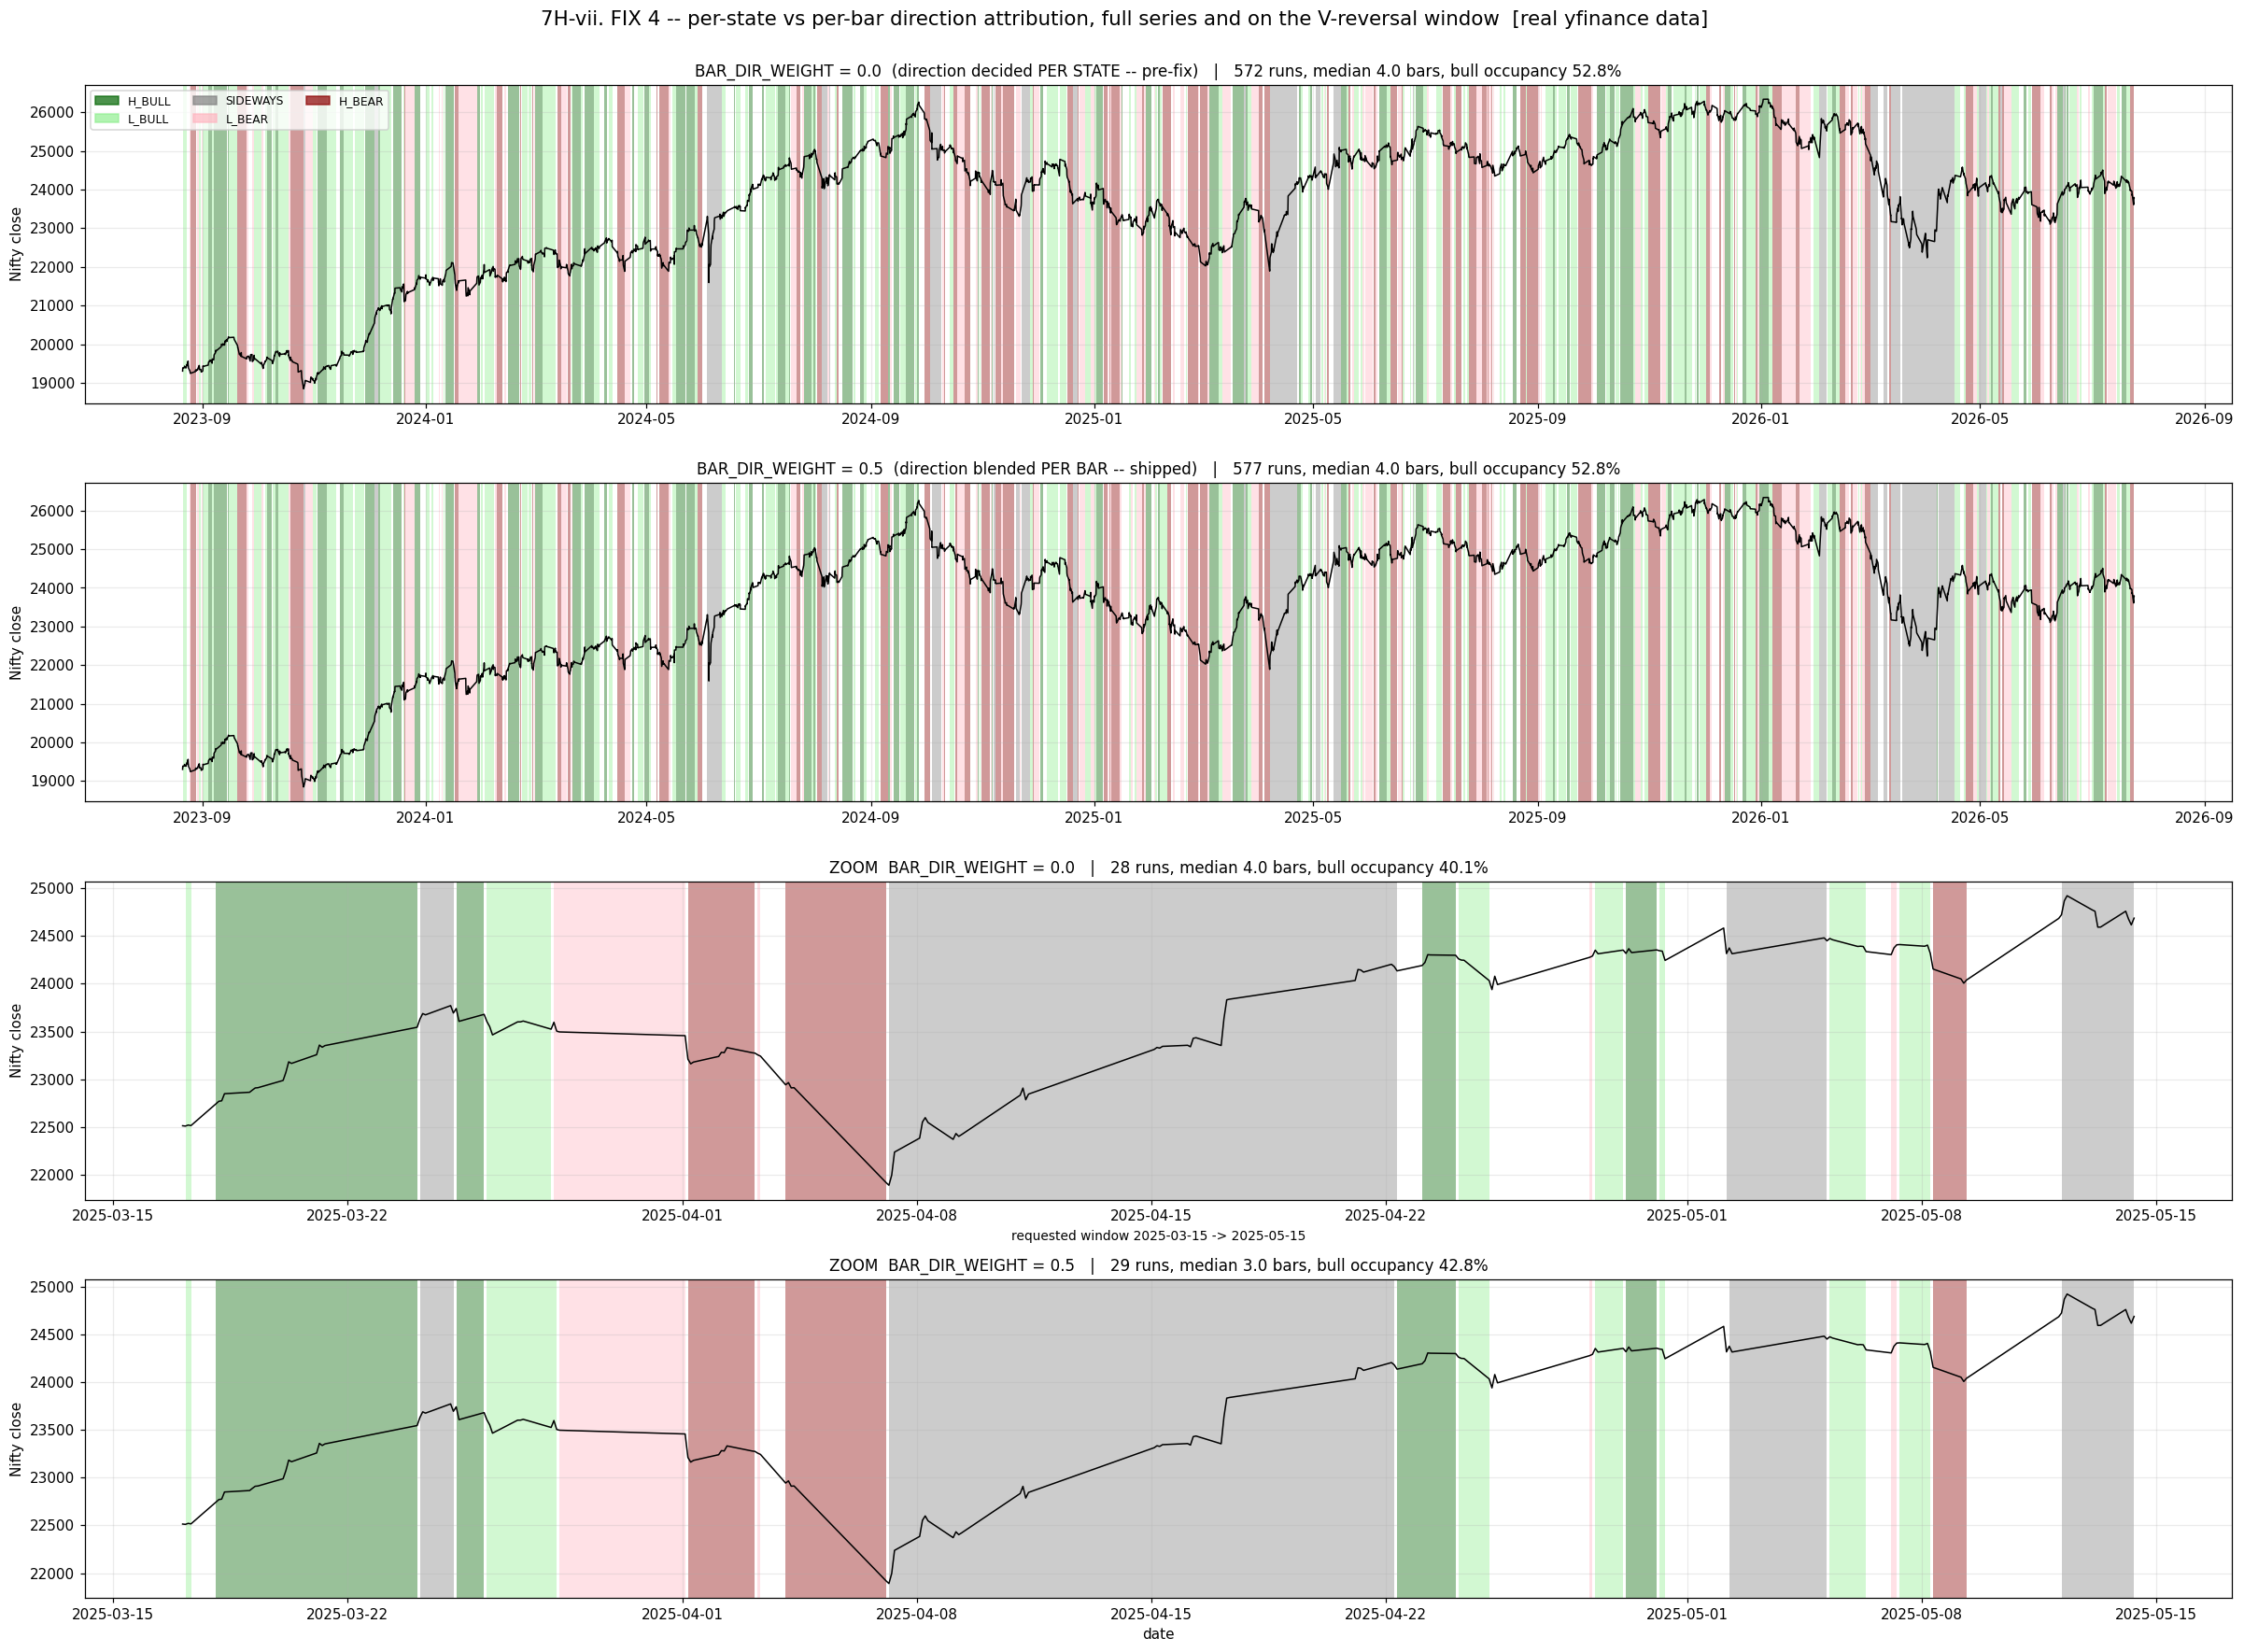

TAC_SYNTH = False


In [35]:
_w0 = BDW[0.0]
_w1 = BDW[_W]
_pxv = reg['nifty_close']

# --- locate the zoom window ------------------------------------------------
ZOOM_LO, ZOOM_HI = pd.Timestamp('2025-03-15'), pd.Timestamp('2025-05-15')
_in = (_pxv.index >= ZOOM_LO) & (_pxv.index <= ZOOM_HI)
if _in.sum() >= 20:
    _vsl = slice(int(np.flatnonzero(_in)[0]), int(np.flatnonzero(_in)[-1]) + 1)
    _vsrc = f'requested window {ZOOM_LO:%Y-%m-%d} -> {ZOOM_HI:%Y-%m-%d}'
else:
    # Programmatic fallback: the deepest V -- the bar minimising (trailing
    # drawdown) that is also followed by the strongest recovery, found over a
    # fixed half-width. This is a PLOTTING choice made with hindsight and feeds
    # nothing; the labels themselves are untouched by it.
    _HW = 30
    _v = _pxv.values
    _best, _bi = -np.inf, _HW
    for _i in range(_HW, len(_v) - _HW):
        _sc = (_v[_i - _HW:_i].max() - _v[_i]) + (_v[_i + 1:_i + _HW + 1].max() - _v[_i])
        if _sc > _best:
            _best, _bi = _sc, _i
    _vsl = slice(max(0, _bi - _HW), min(len(_v), _bi + _HW + 1))
    _vsrc = (f'requested window not in this series ({_in.sum()} bars) -> '
             f'programmatic deepest-V fallback')
print(f'7H-vii zoom: {_vsrc}   '
      f'{_pxv.index[_vsl.start]:%Y-%m-%d} -> {_pxv.index[_vsl.stop-1]:%Y-%m-%d}   '
      f'({_vsl.stop - _vsl.start} bars)')

fig, axes = plt.subplots(4, 1, figsize=(22, 16))
_panels = [
    (f'BAR_DIR_WEIGHT = 0.0  (direction decided PER STATE -- pre-fix)', _w0, slice(None)),
    (f'BAR_DIR_WEIGHT = {_W}  (direction blended PER BAR -- shipped)', _w1, slice(None)),
    (f'ZOOM  BAR_DIR_WEIGHT = 0.0', _w0, _vsl),
    (f'ZOOM  BAR_DIR_WEIGHT = {_W}', _w1, _vsl),
]
for ax, (_ttl, _lb, _sl) in zip(axes, _panels):
    _s = _lb.iloc[_sl]
    shade_regimes(ax, _s, alpha=0.40)
    ax.plot(_pxv.iloc[_sl].index, _pxv.iloc[_sl].values, color='black', linewidth=1.0)
    _rl = run_lengths(_s.values)
    _bull_occ = 100 * _s.isin(['H_BULL', 'L_BULL']).mean()
    ax.set_title(f'{_ttl}   |   {len(_rl)} runs, median {np.median([L for _, L in _rl]):.1f} '
                 f'bars, bull occupancy {_bull_occ:.1f}%', fontsize=11)
    ax.set_ylabel('Nifty close')
    if ax is axes[0]:
        regime_legend(ax)
axes[2].set_xlabel(_vsrc, fontsize=9)
axes[-1].set_xlabel('date')
fig.suptitle('7H-vii. FIX 4 -- per-state vs per-bar direction attribution, full series '
             'and on the V-reversal window' + synth_tag(), fontsize=14, y=1.002)
plt.tight_layout()
plt.show()
print(f"TAC_SYNTH = {TAC_SYNTH}" + ('  -> ILLUSTRATIVE ONLY' if TAC_SYNTH else ''))

# 8. The decision

## 8a. Automated evaluation summary

Machine-checked version of the pass conditions:

1. **Forward-return ordering (7C)**: the *direction-level* ordering must hold at
   all three horizons — the single most important test. Strict 5-label inversions
   confined to an H-vs-L pair inside one direction are a tuning signal
   (`Z_HI` / `EFF_HI`), not a failure of the detector.
2. **No regime is vanishingly rare** (<2% of bars) or totally dominant (>70%).
3. **Median run length** for directional regimes is at least ~3 bars (one day) —
   otherwise the detector flickers too much to trade.
4. **`H` regimes show higher `trend_efficiency` than their `L` counterparts** —
   the chop filter is discriminating, not just relabelling.
5. **Regime long/flat sidesteps drawdown** relative to buy-and-hold.

In [36]:
print('=' * 78)
print('RegDet V1.1 - evaluation summary')
print('=' * 78)
print(f'Data      : {"SYNTHETIC (illustrative only)" if TAC_SYNTH else "REAL yfinance 60m->2h"}'
      f'   TAC_SYNTH={TAC_SYNTH}')
print(f'Bars      : {len(reg)}   {reg.index[0]:%Y-%m-%d} -> {reg.index[-1]:%Y-%m-%d}')
print(f'Config    : winner={best_name}  N={EVAL_CFG["N"]} cov={EVAL_CFG["cov"]} '
      f'n_feat={len(eval_feat)}  CONF_L={CONF_L} Z_HI={Z_HI} EFF_HI={EFF_HI} EFF_WIN={EFF_WIN}')
print()
print('1. Forward-return monotonicity (H_BULL > L_BULL > SIDEWAYS > L_BEAR > H_BEAR):')
for h in FWD_HORIZONS:
    seq, viol, (bull, side, bear), coarse_ok = ordering_report(h)
    print(f'   fwd_{h:2d} bars: strict {"HOLDS " if not viol else "BROKEN"}   '
          f'direction-level {"HOLDS " if coarse_ok else "BROKEN"}   ' +
          '  '.join(f'{r}={v:+.3f}%' for r, v in zip(present, seq)))
    for a, va, b, vb in viol:
        print(f'                inversion: {a} ({va:+.3f}%) < {b} ({vb:+.3f}%)')
print()
print('2. Occupancy:')
for r in REGIME_LABELS:
    n = int((lab == r).sum())
    flag = '  <-- rare' if 0 < 100 * n / len(reg) < 2 else ('  <-- dominant' if 100 * n / len(reg) > 70 else '')
    print(f'   {r:9s} {n:5d} bars  {100*n/len(reg):5.1f}%{flag}')
print()
print('3. Median run length (bars, 3 = 1 day):')
for r in plot_labs:
    print(f'   {r:9s} {np.median(runs[r]):5.1f}')
print()
print('4. Mean trend_efficiency by regime (H should exceed its L counterpart):')
for r in present:
    print(f'   {r:9s} {reg.loc[lab == r, "trend_efficiency"].mean():.3f}')
print()
cagr_b, sh_b, mdd_b = _stats(bar_ret, bh_curve)
cagr_r, sh_r, mdd_r = _stats(strat_ret, rg_curve)
print(f'5. Drawdown: buy&hold {mdd_b:.2%}  vs  regime long/flat {mdd_r:.2%}   '
      f'(Sharpe {sh_b:.2f} vs {sh_r:.2f})')
print()
print('6. Labeling fixes (full A/B in 7H):')
print(f'   DIRECTION_EXCLUDE={DIRECTION_EXCLUDE}  CONFIRM_BARS={CONFIRM_BARS}  '
      f'Z_HI_EXIT={Z_HI_EXIT}  EFF_HI_EXIT={EFF_HI_EXIT}  BAR_DIR_WEIGHT={BAR_DIR_WEIGHT}')
for _nm, _ in AB_ARMS:
    _t = AB_TBL[_nm]
    print(f'   {_nm:22s} runs={int(_t.loc["ALL","runs"]):4d}  '
          f'median run={_t.loc["ALL","median_run"]:.1f}  mean run={_t.loc["ALL","mean_run"]:.2f} bars')
print()
print('7. FIX 4 -- per-bar direction sweep (7H-vi), pre-stated criterion:')
print(f'   [1] high-vol rally bull% at w={_W}: {BDW_RALLY.loc[_W, "bull_%"]:.1f}% vs '
      f'{BDW_RALLY.loc[0.0, "bull_%"]:.1f}% at w=0  '
      f'({BDW_RALLY.loc[_W, "bull_pp_vs_w0"]:+.1f} pp, need >= +15) -> '
      f'{"PASS" if C1 else "FAIL"}')
print(f'   [2] SIDEWAYS fwd_{_H} {BDW_FWD[_W].loc["SIDEWAYS", f"fwd_{_H}"]:+.3f}% < '
      f'H_BULL fwd_{_H} {BDW_FWD[_W].loc["H_BULL", f"fwd_{_H}"]:+.3f}% -> '
      f'{"PASS" if C2 else "FAIL"}')
print(f'   OVERALL FIX 4: {"PASS" if (C1 and C2) else "FAIL"}'
      + ('   (on SYNTHETIC data -- not the deciding run)' if TAC_SYNTH else ''))
print()
print(f'Capacity ranking (worst-fold Sharpe): {" > ".join(order)}')
print('=' * 78)
if TAC_SYNTH:
    print('TAC_SYNTH=True -> ILLUSTRATIVE ONLY. Re-run where yfinance works for a real verdict.')

RegDet V1.1 - evaluation summary
Data      : REAL yfinance 60m->2h   TAC_SYNTH=False
Bars      : 2874   2023-08-21 -> 2026-07-24
Config    : winner=A: lean-cov  N=5 cov=diag n_feat=9  CONF_L=0.5 Z_HI=0.5 EFF_HI=0.35 EFF_WIN=9

1. Forward-return monotonicity (H_BULL > L_BULL > SIDEWAYS > L_BEAR > H_BEAR):
   fwd_ 3 bars: strict BROKEN   direction-level BROKEN   H_BULL=+0.042%  L_BULL=-0.018%  SIDEWAYS=+0.192%  L_BEAR=+0.044%  H_BEAR=-0.039%
                inversion: L_BULL (-0.018%) < SIDEWAYS (+0.192%)
   fwd_ 9 bars: strict BROKEN   direction-level BROKEN   H_BULL=+0.089%  L_BULL=-0.009%  SIDEWAYS=+0.570%  L_BEAR=+0.031%  H_BEAR=-0.053%
                inversion: L_BULL (-0.009%) < SIDEWAYS (+0.570%)
   fwd_15 bars: strict BROKEN   direction-level BROKEN   H_BULL=+0.035%  L_BULL=+0.094%  SIDEWAYS=+0.731%  L_BEAR=+0.081%  H_BEAR=-0.034%
                inversion: H_BULL (+0.035%) < L_BULL (+0.094%)
                inversion: L_BULL (+0.094%) < SIDEWAYS (+0.731%)

2. Occupancy:
   H_BU

## 8b. Verdict — fill in after the real-data run

**Instructions:** run this notebook end-to-end on real `^NSEI`/`^INDIAVIX`
data (Colab/Kaggle/Antigravity), confirm the printed line reads
`TAC_SYNTH = False`, then fill in every `[ ... ]` placeholder below from the
Section 6a/6b tables and the Section 8a summary actually produced. Do not fill
this in from a synthetic run.

---

**TAC_SYNTH on this run:** `[ True / False ]`

**Which folds lost money (sharpe < 0 or cum_return < 0), and for how many of
the 3 configs?**

| fold | start | end | # configs that lost | all 3 lose the same folds? |
|------|-------|-----|----------------------|------------------------------|
| 0    | [ ]   | [ ] | [ ]                   | [ ]                          |
| 1    | [ ]   | [ ] | [ ]                   | [ ]                          |
| 2    | [ ]   | [ ] | [ ]                   | [ ]                          |
| 3    | [ ]   | [ ] | [ ]                   | [ ]                          |

**For each losing fold, market character (from Section 6b) and buy-and-hold
outcome (from Section 6a):**

| fold | efficiency (chop ratio) | ann_vol | max_drawdown | bh_sharpe | bh_cum_return | verdict |
|------|--------------------------|---------|---------------|-----------|-----------------|---------|
| [ ]  | [ ]                       | [ ]     | [ ]           | [ ]       | [ ]             | [ regime-inherent / detector flaw / mixed ] |
| [ ]  | [ ]                       | [ ]     | [ ]           | [ ]       | [ ]             | [ regime-inherent / detector flaw / mixed ] |

**Decision guidance (apply per losing fold):**

- If `efficiency` is low (choppy/no clear trend) **and** `bh_sharpe` /
  `bh_cum_return` were also poor/negative in that window -> the loss is
  **regime-inherent**: even a naive always-long benchmark struggled there, so
  a long-flat regime detector bleeding a bit is an expected property of the
  strategy family in chop, not a flaw. This is **acceptable** for a component
  that mainly exists to feed a downstream tactical filter/overlay, provided
  the bleed is a "steady small loss" shape (Section 6c) rather than a sharp
  single-shock loss.
- If `bh_sharpe` / `bh_cum_return` were **positive** (buy-and-hold did fine or
  well) in a fold where the detector still lost money -> that is a
  **detector flaw**: the detector was flat or wrong-sided through a rally it
  should have caught, or whipsawed through a trend it should have held. This
  should be investigated (look at the fold's regime-state sequence and
  `switches` count) before adopting any of the three configs for production
  V1.1, independent of which one wins the head-to-head's worst-fold-Sharpe
  ranking.
- If the **same** 2 folds lose for all 3 configs (same start/end dates in
  Section 6a across configs) -> the failure mode is **shared across
  configurations** and is a property of the detector *family*
  (HMM regime-gating a long-flat strategy) or of those specific market
  windows, not something the A vs B vs V1.0 choice can fix. In that case the
  head-to-head's worst-fold-Sharpe ranking still stands as the right way to
  pick among the three, but the positive-folds result should be recorded as a
  known, accepted property of V1.1 rather than a bug to chase.

**Labeling verdict (from Section 7 / 8a):**

| check | result |
|-------|--------|
| direction-level forward-return ordering holds at all 3 horizons | `[ yes / no ]` |
| strict 5-label ordering (and if broken, which pair) | `[ ]` |
| every regime between 2% and 70% occupancy | `[ ]` |
| median run length of directional regimes >= 3 bars | `[ ]` |
| **7H complaint 1** — high-vol rally bars (top `vol_2h` quartile, trailing `mom_3d > 0`) moved from bear to bull under fix 1 | `[ ]` |
| **7H-vi fix 4 criterion [1]** — high-vol rally `bull%` rose >= 15 pp at the default `BAR_DIR_WEIGHT` vs `0.0` | `[ PASS / FAIL ]` |
| **7H-vi fix 4 criterion [2]** — `SIDEWAYS` mean `fwd_15` fell below `H_BULL`'s | `[ PASS / FAIL ]` |
| **7H-vi** — persistence survived fix 4 (median run length did not collapse vs `w=0`) | `[ ]` |
| **7H-vi** — direction-level ordering `BULL > SIDEWAYS > BEAR` still holds at the default weight | `[ ]` |
| **7H-vii** — the April-2025 V-reversal recovery leg is green in the `w=default` panel and was not at `w=0` (visual) | `[ ]` |
| **7H complaint 2** — overall median run length rose >= 50% and reached >= 3 bars under all three fixes | `[ ]` |
| the barcode is gone in the 7H-iv before/after overlay (visual) | `[ ]` |
| `H` regimes show higher `trend_efficiency` than their `L` counterparts (chop filter discriminating) | `[ ]` |
| regime long/flat max drawdown vs buy-and-hold | `[ ]` |

**Final call:** `[ regime-inherent -- proceed with the winning config as V1.1 /
detector flaw -- investigate before adopting / labeling needs Z_HI/EFF_HI
tuning / mixed -- see per-fold notes above ]`

**Next step.** Copy this filled-in verdict, plus the Section 6a/6b tables and the
Section 8a summary, back to the supervisor.